# Awareness Factor Investigation 

These are experimental codes:      
- Briefing the data
- Tuning optimal hyperparameter
- Visualize the performance of Models
- Visualize the importance
- Visualize and summerize impacts

In [1]:
%pwd

'/Users/lichao/Library/CloudStorage/OneDrive-Personal/MLD01_Article/MLD01e_Code'

In [2]:
%cd ..

/Users/lichao/Library/CloudStorage/OneDrive-Personal/MLD01_Article


/Users/lichao/opt/anaconda3/envs/ML/lib/python3.9/site-packages/IPython/core/magics/osm.py:417: UserWarning: using dhist requires you to install the `pickleshare` library.
  self.shell.db['dhist'] = compress_dhist(dhist)[-100:]


## Import PAckage

In [3]:
import matplotlib.pyplot as plt
import numpy as np
import os
import pandas as pd

from sklearn.model_selection import train_test_split
from sklearn.model_selection import StratifiedKFold, RandomizedSearchCV
from sklearn.metrics import roc_auc_score, classification_report
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report

from xgboost import XGBClassifier 

## Append Data

In [4]:
df_2016 = pd.read_parquet('Data/01_Napel2016.parquet')
df_2016['Year'] = 2016
df_2022 = pd.read_parquet('Data/01_Napel2022.parquet')
df_2022['Year'] = 2022

In [5]:
df_all = pd.concat([df_2016, df_2022], axis = 0)

In [6]:
df_all.shape

(11568, 352)

In [7]:
df_all = df_all.dropna(axis=1, how="any")

In [8]:
df_all.shape

(11568, 277)

In [9]:
df_all = df_all.set_index(['PSU', 'HHLD'])

In [10]:
df_all.columns

Index(['EcoBelt', 'Prov', 'Rural_Dummy', 'Respon_Female', 'Respon_Age',
       'LivingYear', 'Edu_UnderSLC', 'Edu_Certificate', 'Edu_Bachelor',
       'Edu_Master',
       ...
       'SoilWaterConservationPast25', 'VisitClimateOfficePast25',
       'FoodConsumptionHabitPast25', 'OfffarmActiPast25',
       'NonFarmEmployPast25', 'FamilyMigrationPast25', 'RiskReductionPast25',
       'RoadImprovementPast25', 'CommunityPartipationPast25', 'Year'],
      dtype='object', length=275)

In [11]:
df_all["EcoBelt"] = df_all["EcoBelt"].str.replace('Tarai', 'Terai')

In [12]:
eco_dummies = pd.get_dummies(df_all["EcoBelt"], prefix="EcoBelt").astype(int)
df_all = pd.concat([df_all, eco_dummies], axis=1)

In [13]:
prov_dummies = pd.get_dummies(df_all["Prov"], prefix="Prov").astype(int)
df_all = pd.concat([df_all, prov_dummies], axis=1)

In [14]:
df_all

EcoBelt          Prov  Rural_Dummy  Respon_Female  Respon_Age  \
PSU   HHLD                                                                   
101.0 1.0   Mountain         Koshi            1            1.0        49.0   
      2.0   Mountain         Koshi            1            0.0        55.0   
      3.0   Mountain         Koshi            1            1.0        46.0   
      4.0   Mountain         Koshi            1            0.0        78.0   
      5.0   Mountain         Koshi            1            0.0        70.0   
...              ...           ...          ...            ...         ...   
826.0 16.0     Terai  Sudurpaschim            0            0.0        47.0   
      17.0     Terai  Sudurpaschim            0            0.0        60.0   
      18.0     Terai  Sudurpaschim            0            1.0        47.0   
      19.0     Terai  Sudurpaschim            0            0.0        55.0   
      20.0     Terai  Sudurpaschim            0            0.0        45.0   

            LivingYear  Edu_UnderSLC  Edu_Certificate  Edu_Bachelor  \
PSU   HHLD                                                            
101.0 1.0         49.0             0                0             0   
      2.0         55.0             1                0             0   
      3.0         25.0             0                0             0   
      4.0         78.0             0                0             0   
      5.0         70.0             1                0             0   
...                ...           ...              ...           ...   
826.0 16.0        40.0             1                0             0   
      17.0        35.0             0                0             0   
      18.0        32.0             1                0             0   
      19.0        55.0             0                0             0   
      20.0        25.0             1                0             0   

            Edu_Master  ...  EcoBelt_Hill  EcoBelt_Mountain  EcoBelt_Terai  \
PSU   HHLD              ...                                                  
101.0 1.0            0  ...             0                 1              0   
      2.0            0  ...             0                 1              0   
      3.0            0  ...             0                 1              0   
      4.0            0  ...             0                 1              0   
      5.0            0  ...             0                 1              0   
...                ...  ...           ...               ...            ...   
826.0 16.0           0  ...             0                 0              1   
      17.0           0  ...             0                 0              1   
      18.0           0  ...             0                 0              1   
      19.0           0  ...             0                 0              1   
      20.0           0  ...             0                 0              1   

            Prov_Bagmati  Prov_Gandaki  Prov_Karnali  Prov_Koshi  \
PSU   HHLD                                                         
101.0 1.0              0             0             0           1   
      2.0              0             0             0           1   
      3.0              0             0             0           1   
      4.0              0             0             0           1   
      5.0              0             0             0           1   
...                  ...           ...           ...         ...   
826.0 16.0             0             0             0           0   
      17.0             0             0             0           0   
      18.0             0             0             0           0   
      19.0             0             0             0           0   
      20.0             0             0             0           0   

            Prov_Lumbini  Prov_Madhesh  Prov_Sudurpaschim  
PSU   HHLD                                                 
101.0 1.0              0             0                

In [15]:
df_all['IncomeResAgri_dummy'] = (df_all[['IncomeS1', 'IncomeS2', 'IncomeS3']] == 1).any(axis=1).astype(int)
df_all['IncomeResWage_dummy'] = (df_all[['IncomeS1', 'IncomeS2', 'IncomeS3']] == 2).any(axis=1).astype(int)
df_all['IncomeResNonAgriBusi_dummy'] = (df_all[['IncomeS1', 'IncomeS2', 'IncomeS3']] == 3).any(axis=1).astype(int)
df_all['IncomeResRemit_dummy'] = (df_all[['IncomeS1', 'IncomeS2', 'IncomeS3']] == 4).any(axis=1).astype(int)
df_all['IncomeResOthers_dummy'] = (df_all[['IncomeS1', 'IncomeS2', 'IncomeS3']] == 5).any(axis=1).astype(int)

In [16]:
df_all['ResidenceOwn_dummy'] = (df_all['Own_Resid'] == 1).astype(int)
df_all['ResidenceRent_dummy'] = (df_all['Own_Resid'] == 2).astype(int)
df_all['ResidenceInstitu_dummy'] = (df_all['Own_Resid'] == 3).astype(int)
df_all['ResidenceOthers_dummy'] = (df_all['Own_Resid'] == 4).astype(int)

In [17]:
df_all['ResidInfraPerman_dummy'] = (df_all['Resid_Type'] == 1).astype(int)
df_all['ResidInfraSemi_dummy'] = (df_all['Resid_Type'] == 2).astype(int)
df_all['ResidInfraKachchi_dummy'] = (df_all['Resid_Type'] == 3).astype(int)
df_all['ResidInfraOthers_dummy'] = (df_all['Resid_Type'] == 4).astype(int)

## Checking "HeardClimate_Dummy"

### Data

In [18]:
df_inuse = df_all[[ 'HeardClimate_Dummy', 
                   'Respon_Female', 'Respon_Age', 'LivingYear', 'Edu_Literal', 'Edu_Illiterate', 'Edu_year', # S01
                   'Female_Ratio', 'U18_Ratio', 'A65_Ratio', 'Edu12_Ratio', 'Literal_Ratio', # S02-1
                   'EcoBelt_Hill', 'EcoBelt_Mountain', 'EcoBelt_Terai', 
                   'Prov_Bagmati', 'Prov_Koshi', 'Prov_Lumbini', 'Prov_Madhesh', 'Prov_Sudurpaschim',
                   'Prov_Gandaki', 'Prov_Karnali', # location     
                   'ResidenceOwn_dummy', 'ResidenceRent_dummy', 'ResidenceInstitu_dummy', 'ResidenceOthers_dummy',
                   'ResidInfraPerman_dummy', 'ResidInfraSemi_dummy', 'ResidInfraKachchi_dummy', 'ResidInfraOthers_dummy', # house
                    'Remittance_dummy', 
                   'Have_AgriLand', 'HouseHead_AgriExpYear',
                   'Radio_dummy', 'TV_dummy', 'PC_dummy', 'Net_dummy', 'Phone_dummy',
                   'Mobile_dummy', 'Motorbike_dummy', 'Car_dummy', 'Bike_dummy', 'OtherVehi_dummy', 'Refrige_dummy',
                   'SavingMembership', 'RegularSaving', 'OrgMembership', 'AgriSupport', 
                   'Dist_Road', 'Dist_HealthCenter', 'Dist_SecondarySchool', 'Dist_Market', 'Dist_AgriSupport', 
                   'FramMechan',
                    'IncomeResAgri_dummy', 'IncomeResWage_dummy', 'IncomeResNonAgriBusi_dummy', 'IncomeResRemit_dummy',
                   'IncomeResOthers_dummy', 
                   'CropIncome', 'LivestockIncome', 'NonAgriIncome', 'BusiIncome', 'TotalIncome',
                   'Year'
                   
                  ]]

In [19]:
variname_readable = {'HeardClimate_Dummy':'Heard about Climate Change Dummy', 'Respon_Female':'Female Dummy', 
                     'Respon_Age':'Age', 'LivingYear':'Years Living in Community', 'Edu_UnderSLC':'Education under Secondary Certificate Dummy', 
                     'Edu_Certificate':'Education with Secondary Certificate Dummy', 'Edu_Bachelor':'Education with Bachelor Dummy', 
                     'Edu_Master':'Education with Master Dummy',  'Edu_PhD':'Education with PhD Dummy', 
                     'Edu_Literal':'Literate Education Dummy',  'Edu_Illiterate':'Illiterate Dummy', 'Edu_year':'Education Year',
                     'Female_Ratio':'Female Ratio in Household', 'U18_Ratio':'Member Under 18 Ratio', 'A65_Ratio':'Seniors Ratio',
                     'Edu12_Ratio':"Member with 12-Year Education or above Ratio", "Literal_Ratio": "Literate Member Ratio",
                     'EcoBelt_Hill': "EcoBelt Hill Dummy", 'EcoBelt_Mountain': "EcoBelt Mountain Dummy", 'EcoBelt_Terai': "EcoBelt Terai Dummy",
                     'Prov_Bagmati': "Province Bagmati Dummy", 'Prov_Koshi': "Province Koshi Dummy", 'Prov_Lumbini': "Province Lumbibi Dummy",
                     'Prov_Madhesh': "Province Madhesh Dummy", 'Prov_Sudurpaschim': "Province Sudurpaschim Dummy", 'Prov_Gandaki': "Province Gandaki Dummy",
                     'Prov_Karnali': "Province Karnali Dummy",
                     'ResidenceOwn_dummy': "Owned Residence Ownership Dummy", 'ResidenceRent_dummy': 'Rented Residence Ownership Dummy', 
                     'ResidenceInstitu_dummy': 'Institutional Residence Ownership Dummy', 'ResidenceOthers_dummy': 'Other-type Residence Ownership Dummy',
                     'ResidInfraPerman_dummy': 'Permanent Residence Dummy', 'ResidInfraSemi_dummy': 'Semi-Permanent Residence Dummy', 
                     'ResidInfraKachchi_dummy': "Kachchi Residence Dummy", 'ResidInfraOthers_dummy': 'Other Residence Infrastructure Dummy', # house
                     'Remittance_dummy' : "Have Remittance",
                     'Have_AgriLand': "Having Agricultural Land Dummy", 'HouseHead_AgriExpYear': "Household Head Agricultural Experience",
                     'Radio_dummy': "Having Radio Dummy", 'TV_dummy': "Having TV Dummy", 'PC_dummy': "Having Computer Dummy", 'Net_dummy': "Having Internet Dummy",
                     'Phone_dummy': "Having Telephone Dummy", 'Mobile_dummy': "Having Mobile Dummy", 'Motorbike_dummy': "Having Motorbike Dummy", 
                     'Car_dummy': "Having Car Dummy", 'Bike_dummy': "Having Bike Dummy", 'OtherVehi_dummy': "Having Other Vehicle Dummy", 
                     'Refrige_dummy':"Having Refrigator Dummy",
                     'SavingMembership': "Saving Membership Dummy", 'RegularSaving': 'Having Regular Saving Dummy', 
                     'OrgMembership': 'Having Organization Membership Dummy', 'AgriSupport':'Agricultural Supporting Dummy', 
                     'Dist_Road': 'Distance to Motorable Road', 'Dist_HealthCenter': "Distance to Health Center", 
                     'Dist_SecondarySchool': "Distance to Secondary School", 'Dist_Market':"Distance to Market", 'Dist_AgriSupport': 'Distance to Agricultural Center', 
                     'FramMechan':'Farm Mechanization Dummy',
                     'IncomeResAgri_dummy': "Agricultural Income Source Dummy", 'IncomeResWage_dummy': "Wage Income Source Dummy",
                     'IncomeResNonAgriBusi_dummy': "Non-Agricultural Business Income Source Dummy", 'IncomeResRemit_dummy': "Remittance Income Dummy",
                     'IncomeResOthers_dummy': "Others Income Source Dummy", 
                     'CropIncome': "Crop Income", 'LivestockIncome': "Livestock Income", 'NonAgriIncome': "Non-agricultural Income", 
                     'BusiIncome': "Business Income", 'TotalIncome': "Total Income",
                     'Year': "Survey Year"                    
                    }

In [20]:
df_inuse.columns = df_inuse.columns.map(variname_readable)

### Hyper Tunining

In [21]:
cvres = pd.read_parquet('MLD01e_Results/MLD01e_C01_KnowledgeFactorInvestigation.parquet')

In [22]:
params = cvres.sort_values('rank_test_score').iloc[0,10]

In [23]:
params

{'colsample_bytree': 0.7,
 'learning_rate': 0.01,
 'max_depth': 8,
 'min_child_weight': 5,
 'n_estimators': 500,
 'subsample': 0.7}

### Value prediction

In [24]:
y = df_inuse['Heard about Climate Change Dummy'].astype(int)
X = df_inuse.drop(columns=['Heard about Climate Change Dummy'])

pos = y.sum()
neg = len(y) - pos
scale_pos_weight = (neg / pos) if pos > 0 else 1.0

In [25]:
cv = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)

In [26]:
def Metrics(y_test, y_pred):
    print("Accuracy:", accuracy_score(y_test, y_pred))
    print("Precision:", precision_score(y_test, y_pred, zero_division=0))
    print("Recall   :", recall_score(y_test, y_pred, zero_division=0))
    print("F1-score :", f1_score(y_test, y_pred, zero_division=0))

    return [accuracy_score(y_test, y_pred), precision_score(y_test, y_pred, zero_division=0),
    recall_score(y_test, y_pred, zero_division=0), f1_score(y_test, y_pred, zero_division=0)]

In [27]:
prob_matrix = pd.DataFrame(np.zeros([X.shape[0], 10]))
prob_matrix_tide = pd.DataFrame(np.zeros([X.shape[0], 10]))

for epoch, random_seed in enumerate(range(42, 42*11, 42)):
    cv = StratifiedKFold(n_splits=10, shuffle=True, random_state=random_seed)
    for fold, (train_idx, test_idx) in enumerate(cv.split(X, y), 1):
        X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
        y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]
    
        X_test = X_test.reindex(columns=X_train.columns, fill_value=0)
        pos = y_train.sum()
        neg = len(y_train) - pos
        scale_pos_weight = (neg / pos) if pos > 0 else 1.0
    
        print(f'fold: {fold}, random_seed:{random_seed}')
        clf = XGBClassifier(objective="binary:logistic",
                            eval_metric="logloss", tree_method="hist", 
                            random_state=random_seed, 
                            scale_pos_weight=scale_pos_weight, device = 'cuda',
                            **params
        )
    
        clf.fit(X_train, y_train)
        prob_matrix.iloc[test_idx, epoch] = clf.predict_proba(X_test)[:, 1]

        X_tide = X_test.copy()
        X_tide['Education Year'] = X_tide['Education Year'] + 1
        X_tide['Literate Education Dummy'] = 0
        X_tide['Illiterate Dummy'] = 0
        prob_matrix_tide.iloc[test_idx, epoch] = clf.predict_proba(X_tide)[:, 1]

fold: 1, random_seed:42
fold: 2, random_seed:42
fold: 3, random_seed:42
fold: 4, random_seed:42
fold: 5, random_seed:42
fold: 6, random_seed:42
fold: 7, random_seed:42
fold: 8, random_seed:42
fold: 9, random_seed:42
fold: 10, random_seed:42
fold: 1, random_seed:84
fold: 2, random_seed:84
fold: 3, random_seed:84
fold: 4, random_seed:84
fold: 5, random_seed:84
fold: 6, random_seed:84
fold: 7, random_seed:84
fold: 8, random_seed:84
fold: 9, random_seed:84
fold: 10, random_seed:84
fold: 1, random_seed:126
fold: 2, random_seed:126
fold: 3, random_seed:126
fold: 4, random_seed:126
fold: 5, random_seed:126
fold: 6, random_seed:126
fold: 7, random_seed:126
fold: 8, random_seed:126
fold: 9, random_seed:126
fold: 10, random_seed:126
fold: 1, random_seed:168
fold: 2, random_seed:168
fold: 3, random_seed:168
fold: 4, random_seed:168
fold: 5, random_seed:168
fold: 6, random_seed:168
fold: 7, random_seed:168
fold: 8, random_seed:168
fold: 9, random_seed:168
fold: 10, random_seed:168
fold: 1, random_

In [28]:
prob_matrix_mean = prob_matrix.mean(axis=1)
prob_matrix_tide_mean = prob_matrix_tide.mean(axis=1)

In [29]:
prob_matrix_mean

0        0.206559
1        0.909197
2        0.459451
3        0.447029
4        0.733517
           ...   
11563    0.318589
11564    0.574720
11565    0.617962
11566    0.191737
11567    0.565973
Length: 11568, dtype: float64

In [30]:
prob_matrix_tide_mean

0        0.294388
1        0.915692
2        0.539462
3        0.470897
4        0.792156
           ...   
11563    0.338742
11564    0.606324
11565    0.648793
11566    0.203249
11567    0.695620
Length: 11568, dtype: float64

In [31]:
knowledge = prob_matrix_tide_mean - prob_matrix_mean

In [32]:
knowledge.mean()

0.04720115316321657

In [33]:
knowledge_prob_matrix_tide_mean = prob_matrix_tide_mean.copy()
knowledge_prob_matrix_mean = prob_matrix_mean.copy()

In [34]:
knowledge_prob_matrix_mean

0        0.206559
1        0.909197
2        0.459451
3        0.447029
4        0.733517
           ...   
11563    0.318589
11564    0.574720
11565    0.617962
11566    0.191737
11567    0.565973
Length: 11568, dtype: float64

## Checking "Awarenesss"

### Data

In [35]:
df_all['Heard about Climate Change Probability'] = knowledge_prob_matrix_mean.to_list()

In [36]:
df_inuse = df_all[['ClimateChanged_Dummy', 'Heard about Climate Change Probability', 
                   'Respon_Female', 'Respon_Age', 'LivingYear', 'Edu_Literal', 'Edu_Illiterate', 'Edu_year', # S01
                   'Female_Ratio', 'U18_Ratio', 'A65_Ratio', 'Edu12_Ratio', 'Literal_Ratio', # S02-1
                   'EcoBelt_Hill', 'EcoBelt_Mountain', 'EcoBelt_Terai', 
                   'Prov_Bagmati', 'Prov_Koshi', 'Prov_Lumbini', 'Prov_Madhesh', 'Prov_Sudurpaschim',
                   'Prov_Gandaki', 'Prov_Karnali', # location     
                   'ResidenceOwn_dummy', 'ResidenceRent_dummy', 'ResidenceInstitu_dummy', 'ResidenceOthers_dummy',
                   'ResidInfraPerman_dummy', 'ResidInfraSemi_dummy', 'ResidInfraKachchi_dummy', 'ResidInfraOthers_dummy', # house
                    'Remittance_dummy', 
                   'Have_AgriLand', 'HouseHead_AgriExpYear',
                   'Radio_dummy', 'TV_dummy', 'PC_dummy', 'Net_dummy', 'Phone_dummy',
                   'Mobile_dummy', 'Motorbike_dummy', 'Car_dummy', 'Bike_dummy', 'OtherVehi_dummy', 'Refrige_dummy',
                   'SavingMembership', 'RegularSaving', 'OrgMembership', 'AgriSupport', 
                   'Dist_Road', 'Dist_HealthCenter', 'Dist_SecondarySchool', 'Dist_Market', 'Dist_AgriSupport', 
                   'FramMechan',
                    'IncomeResAgri_dummy', 'IncomeResWage_dummy', 'IncomeResNonAgriBusi_dummy', 'IncomeResRemit_dummy',
                   'IncomeResOthers_dummy', 
                   'CropIncome', 'LivestockIncome', 'NonAgriIncome', 'BusiIncome', 'TotalIncome',
                   'Year',
                   
                   # Disaster experiences
                   'ExpDummyDR', 'ExpDummyFF', 'ExpDummyFS', 'ExpDummyFL', 'ExpDummyIN', 'ExpDummyWS', 
                   'ExpDummyTS', 'ExpDummyHS', 'ExpDummyHR', 'ExpDummySR', 'ExpDummySE', 'ExpDummyLS', 
                   'ExpDummySS', 'ExpDummyAV', 'ExpDummyGLOF', 'ExpDummyHW', 'ExpDummyCW', 'ExpDummyDI', 
                   'ExpDummyOT',
                   
                   # DisasterFoodShortage
                   'DisasterFoodShortage_DummyDR', 'DisasterFoodShortage_DummyFF', 'DisasterFoodShortage_DummyFS', 
                   'DisasterFoodShortage_DummyFL', 'DisasterFoodShortage_DummyIN', 'DisasterFoodShortage_DummyWS', 
                   'DisasterFoodShortage_DummyTS', 'DisasterFoodShortage_DummyHS', 'DisasterFoodShortage_DummyHR', 
                   'DisasterFoodShortage_DummySR', 'DisasterFoodShortage_DummySE', 'DisasterFoodShortage_DummyLS', 
                   'DisasterFoodShortage_DummySS', 'DisasterFoodShortage_DummyAV', 'DisasterFoodShortage_DummyGLOF', 
                   'DisasterFoodShortage_DummyHW', 'DisasterFoodShortage_DummyCW', 'DisasterFoodShortage_DummyDI', 
                   'DisasterFoodShortage_DummyOT', 'DisasterDie_DummyDR', 
                   
                   # DisasterDie
                   'DisasterDie_DummyFF', 'DisasterDie_DummyFS', 'DisasterDie_DummyFL', 'DisasterDie_DummyIN', 
                   'DisasterDie_DummyWS', 'DisasterDie_DummyTS', 'DisasterDie_DummyHS', 'DisasterDie_DummyHR', 
                   'DisasterDie_DummySR', 'DisasterDie_DummySE', 'DisasterDie_DummyLS', 'DisasterDie_DummySS', 
                   'DisasterDie_DummyAV', 'DisasterDie_DummyGLOF', 'DisasterDie_DummyHW', 'DisasterDie_DummyCW', 
                   'DisasterDie_DummyDI', 'DisasterDie_DummyOT', 
                   
                   # DisasterMoneyLoss
                   'DisasterMoneyLoss_DummyDR', 'DisasterMoneyLoss_DummyFF', 'DisasterMoneyLoss_DummyFS', 
                   'DisasterMoneyLoss_DummyFL', 'DisasterMoneyLoss_DummyIN', 'DisasterMoneyLoss_DummyWS', 
                   'DisasterMoneyLoss_DummyTS', 'DisasterMoneyLoss_DummyHS', 'DisasterMoneyLoss_DummyHR', 
                   'DisasterMoneyLoss_DummySR', 'DisasterMoneyLoss_DummySE', 'DisasterMoneyLoss_DummyLS', 
                   'DisasterMoneyLoss_DummySS', 'DisasterMoneyLoss_DummyAV', 'DisasterMoneyLoss_DummyGLOF',
                   'DisasterMoneyLoss_DummyHW', 'DisasterMoneyLoss_DummyCW', 'DisasterMoneyLoss_DummyDI', 
                   'DisasterMoneyLoss_DummyOT', 
                   
]]

In [37]:
variname_readable = {'ClimateChanged_Dummy':'Climate Change Awareness Dummy',
                     'Heard about Climate Change Probability':'Heard about Climate Change Probability', 'Respon_Female':'Female Dummy', 
                     'Respon_Age':'Age', 'LivingYear':'Years Living in Community', 'Edu_UnderSLC':'Education under Secondary Certificate Dummy', 
                     'Edu_Certificate':'Education with Secondary Certificate Dummy', 'Edu_Bachelor':'Education with Bachelor Dummy', 
                     'Edu_Master':'Education with Master Dummy',  'Edu_PhD':'Education with PhD Dummy', 
                     'Edu_Literal':'Literate Education Dummy',  'Edu_Illiterate':'Illiterate Dummy', 'Edu_year':'Education Year',
                     'Female_Ratio':'Female Ratio in Household', 'U18_Ratio':'Member Under 18 Ratio', 'A65_Ratio':'Seniors Ratio',
                     'Edu12_Ratio':"Member with 12-Year Education or above Ratio", "Literal_Ratio": "Literate Member Ratio",
                     'EcoBelt_Hill': "EcoBelt Hill Dummy", 'EcoBelt_Mountain': "EcoBelt Mountain Dummy", 'EcoBelt_Terai': "EcoBelt Terai Dummy",
                     'Prov_Bagmati': "Province Bagmati Dummy", 'Prov_Koshi': "Province Koshi Dummy", 'Prov_Lumbini': "Province Lumbibi Dummy",
                     'Prov_Madhesh': "Province Madhesh Dummy", 'Prov_Sudurpaschim': "Province Sudurpaschim Dummy", 'Prov_Gandaki': "Province Gandaki Dummy",
                     'Prov_Karnali': "Province Karnali Dummy",
                     'ResidenceOwn_dummy': "Owned Residence Ownership Dummy", 'ResidenceRent_dummy': 'Rented Residence Ownership Dummy', 
                     'ResidenceInstitu_dummy': 'Institutional Residence Ownership Dummy', 'ResidenceOthers_dummy': 'Other-type Residence Ownership Dummy',
                     'ResidInfraPerman_dummy': 'Permanent Residence Dummy', 'ResidInfraSemi_dummy': 'Semi-Permanent Residence Dummy', 
                     'ResidInfraKachchi_dummy': "Kachchi Residence Dummy", 'ResidInfraOthers_dummy': 'Other Residence Infrastructure Dummy', # house
                     'Remittance_dummy' : "Have Remittance",
                     'Have_AgriLand': "Having Agricultural Land Dummy", 'HouseHead_AgriExpYear': "Household Head Agricultural Experience",
                     'Radio_dummy': "Having Radio Dummy", 'TV_dummy': "Having TV Dummy", 'PC_dummy': "Having Computer Dummy", 'Net_dummy': "Having Internet Dummy",
                     'Phone_dummy': "Having Telephone Dummy", 'Mobile_dummy': "Having Mobile Dummy", 'Motorbike_dummy': "Having Motorbike Dummy", 
                     'Car_dummy': "Having Car Dummy", 'Bike_dummy': "Having Bike Dummy", 'OtherVehi_dummy': "Having Other Vehicle Dummy", 
                     'Refrige_dummy':"Having Refrigator Dummy",
                     'SavingMembership': "Saving Membership Dummy", 'RegularSaving': 'Having Regular Saving Dummy', 
                     'OrgMembership': 'Having Organization Membership Dummy', 'AgriSupport':'Agricultural Supporting Dummy', 
                     'Dist_Road': 'Distance to Motorable Road', 'Dist_HealthCenter': "Distance to Health Center", 
                     'Dist_SecondarySchool': "Distance to Secondary School", 'Dist_Market':"Distance to Market", 'Dist_AgriSupport': 'Distance to Agricultural Center', 
                     'FramMechan':'Farm Mechanization Dummy',
                     'IncomeResAgri_dummy': "Agricultural Income Source Dummy", 'IncomeResWage_dummy': "Wage Income Source Dummy",
                     'IncomeResNonAgriBusi_dummy': "Non-Agricultural Business Income Source Dummy", 'IncomeResRemit_dummy': "Remittance Income Dummy",
                     'IncomeResOthers_dummy': "Others Income Source Dummy", 
                     'CropIncome': "Crop Income", 'LivestockIncome': "Livestock Income", 'NonAgriIncome': "Non-agricultural Income", 
                     'BusiIncome': "Business Income", 'TotalIncome': "Total Income",
                     'Year': "Survey Year"                    
                    }

In [38]:
# ...existing code...
variname_readable.update({
    # Awareness sources
    'ClimateInfo_Radio': "Heard Climate Info from Radio",
    'ClimateInfo_Telev': "Heard Climate Info from Television",
    'ClimateInfo_News ': "Heard Climate Info from Newspaper",
    'ClimateInfo_Aware': "Heard Climate Info from Awareness Program",
    'ClimateInfo_Local': "Heard Climate Info from Local Government",
    'ClimateInfo_Neigh': "Heard Climate Info from Neighbors",
    'ClimateInfo_Famil': "Heard Climate Info from Family",
    'ClimateInfo_Other': "Heard Climate Info from Other Sources",

    # Disaster experiences
    'ExpDummyDR': "Experienced Drought",
    'ExpDummyFF': "Experienced Flash Flood",
    'ExpDummyFS': "Experienced Forest Fire",
    'ExpDummyFL': "Experienced Flood",
    'ExpDummyIN': "Experienced Insect Infestation",
    'ExpDummyWS': "Experienced Windstorm",
    'ExpDummyTS': "Experienced Thunderstorm",
    'ExpDummyHS': "Experienced Hailstorm",
    'ExpDummyHR': "Experienced Heavy Rain",
    'ExpDummySR': "Experienced Snowfall/Rain",
    'ExpDummySE': "Experienced Earthquake",
    'ExpDummyLS': "Experienced Landslide",
    'ExpDummySS': "Experienced Snowstorm",
    'ExpDummyAV': "Experienced Avalanche",
    'ExpDummyGLOF': "Experienced Glacial Lake Outburst Flood",
    'ExpDummyHW': "Experienced Heat Wave",
    'ExpDummyCW': "Experienced Cold Wave",
    'ExpDummyDI': "Experienced Disease Outbreak",
    'ExpDummyOT': "Experienced Other Disaster",

    # Disaster Food Shortage
    'DisasterFoodShortage_DummyDR': "Food Shortage due to Drought",
    'DisasterFoodShortage_DummyFF': "Food Shortage due to Flash Flood",
    'DisasterFoodShortage_DummyFS': "Food Shortage due to Forest Fire",
    'DisasterFoodShortage_DummyFL': "Food Shortage due to Flood",
    'DisasterFoodShortage_DummyIN': "Food Shortage due to Insect Infestation",
    'DisasterFoodShortage_DummyWS': "Food Shortage due to Windstorm",
    'DisasterFoodShortage_DummyTS': "Food Shortage due to Thunderstorm",
    'DisasterFoodShortage_DummyHS': "Food Shortage due to Hailstorm",
    'DisasterFoodShortage_DummyHR': "Food Shortage due to Heavy Rain",
    'DisasterFoodShortage_DummySR': "Food Shortage due to Snowfall/Rain",
    'DisasterFoodShortage_DummySE': "Food Shortage due to Earthquake",
    'DisasterFoodShortage_DummyLS': "Food Shortage due to Landslide",
    'DisasterFoodShortage_DummySS': "Food Shortage due to Snowstorm",
    'DisasterFoodShortage_DummyAV': "Food Shortage due to Avalanche",
    'DisasterFoodShortage_DummyGLOF': "Food Shortage due to GLOF",
    'DisasterFoodShortage_DummyHW': "Food Shortage due to Heat Wave",
    'DisasterFoodShortage_DummyCW': "Food Shortage due to Cold Wave",
    'DisasterFoodShortage_DummyDI': "Food Shortage due to Disease Outbreak",
    'DisasterFoodShortage_DummyOT': "Food Shortage due to Other Disaster",
    'DisasterDie_DummyDR': "Death due to Drought",

    # Disaster Die
    'DisasterDie_DummyFF': "Death due to Flash Flood",
    'DisasterDie_DummyFS': "Death due to Forest Fire",
    'DisasterDie_DummyFL': "Death due to Flood",
    'DisasterDie_DummyIN': "Death due to Insect Infestation",
    'DisasterDie_DummyWS': "Death due to Windstorm",
    'DisasterDie_DummyTS': "Death due to Thunderstorm",
    'DisasterDie_DummyHS': "Death due to Hailstorm",
    'DisasterDie_DummyHR': "Death due to Heavy Rain",
    'DisasterDie_DummySR': "Death due to Snowfall/Rain",
    'DisasterDie_DummySE': "Death due to Earthquake",
    'DisasterDie_DummyLS': "Death due to Landslide",
    'DisasterDie_DummySS': "Death due to Snowstorm",
    'DisasterDie_DummyAV': "Death due to Avalanche",
    'DisasterDie_DummyGLOF': "Death due to GLOF",
    'DisasterDie_DummyHW': "Death due to Heat Wave",
    'DisasterDie_DummyCW': "Death due to Cold Wave",
    'DisasterDie_DummyDI': "Death due to Disease Outbreak",
    'DisasterDie_DummyOT': "Death due to Other Disaster",

    # Disaster Money Loss
    'DisasterMoneyLoss_DummyDR': "Money Loss due to Drought",
    'DisasterMoneyLoss_DummyFF': "Money Loss due to Flash Flood",
    'DisasterMoneyLoss_DummyFS': "Money Loss due to Forest Fire",
    'DisasterMoneyLoss_DummyFL': "Money Loss due to Flood",
    'DisasterMoneyLoss_DummyIN': "Money Loss due to Insect Infestation",
    'DisasterMoneyLoss_DummyWS': "Money Loss due to Windstorm",
    'DisasterMoneyLoss_DummyTS': "Money Loss due to Thunderstorm",
    'DisasterMoneyLoss_DummyHS': "Money Loss due to Hailstorm",
    'DisasterMoneyLoss_DummyHR': "Money Loss due to Heavy Rain",
    'DisasterMoneyLoss_DummySR': "Money Loss due to Snowfall/Rain",
    'DisasterMoneyLoss_DummySE': "Money Loss due to Earthquake",
    'DisasterMoneyLoss_DummyLS': "Money Loss due to Landslide",
    'DisasterMoneyLoss_DummySS': "Money Loss due to Snowstorm",
    'DisasterMoneyLoss_DummyAV': "Money Loss due to Avalanche",
    'DisasterMoneyLoss_DummyGLOF': "Money Loss due to GLOF",
    'DisasterMoneyLoss_DummyHW': "Money Loss due to Heat Wave",
    'DisasterMoneyLoss_DummyCW': "Money Loss due to Cold Wave",
    'DisasterMoneyLoss_DummyDI': "Money Loss due to Disease Outbreak",
    'DisasterMoneyLoss_DummyOT': "Money Loss due to Other Disaster",
})
# ...existing code...

In [39]:
df_inuse.columns = df_inuse.columns.map(variname_readable)

### Hyper Tunining

In [40]:
cvres.to_parquet('MLD01e_Results/MLD01e_C11_AwarenessFactorInvestigation_v1.parquet')

In [41]:
params = cvres.sort_values('rank_test_score').iloc[0,10]

In [42]:
params

{'colsample_bytree': 0.7,
 'learning_rate': 0.01,
 'max_depth': 8,
 'min_child_weight': 5,
 'n_estimators': 500,
 'subsample': 0.7}

### Value prediction

In [43]:
y = df_inuse['Climate Change Awareness Dummy'].astype(int)
X = df_inuse.drop(columns=['Climate Change Awareness Dummy'])

pos = y.sum()
neg = len(y) - pos
scale_pos_weight = (neg / pos) if pos > 0 else 1.0

In [44]:
cv = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)

In [45]:
def Metrics(y_test, y_pred):
    print("Accuracy:", accuracy_score(y_test, y_pred))
    print("Precision:", precision_score(y_test, y_pred, zero_division=0))
    print("Recall   :", recall_score(y_test, y_pred, zero_division=0))
    print("F1-score :", f1_score(y_test, y_pred, zero_division=0))

    return [accuracy_score(y_test, y_pred), precision_score(y_test, y_pred, zero_division=0),
    recall_score(y_test, y_pred, zero_division=0), f1_score(y_test, y_pred, zero_division=0)]

In [46]:
X.columns

Index(['Heard about Climate Change Probability', 'Female Dummy', 'Age',
       'Years Living in Community', 'Literate Education Dummy',
       'Illiterate Dummy', 'Education Year', 'Female Ratio in Household',
       'Member Under 18 Ratio', 'Seniors Ratio',
       ...
       'Money Loss due to Snowfall/Rain', 'Money Loss due to Earthquake',
       'Money Loss due to Landslide', 'Money Loss due to Snowstorm',
       'Money Loss due to Avalanche', 'Money Loss due to GLOF',
       'Money Loss due to Heat Wave', 'Money Loss due to Cold Wave',
       'Money Loss due to Disease Outbreak',
       'Money Loss due to Other Disaster'],
      dtype='object', length=141)

In [47]:
prob_matrix = pd.DataFrame(np.zeros([X.shape[0], 10]))
prob_matrix_tide = pd.DataFrame(np.zeros([X.shape[0], 10]))

for epoch, random_seed in enumerate(range(42, 42*11, 42)):
    cv = StratifiedKFold(n_splits=10, shuffle=True, random_state=random_seed)
    for fold, (train_idx, test_idx) in enumerate(cv.split(X, y), 1):
        X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
        y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]
    
        X_test = X_test.reindex(columns=X_train.columns, fill_value=0)
        pos = y_train.sum()
        neg = len(y_train) - pos
        scale_pos_weight = (neg / pos) if pos > 0 else 1.0
    
        print(f'fold: {fold}, random_seed:{random_seed}')
        clf = XGBClassifier(objective="binary:logistic",
                            eval_metric="logloss", tree_method="hist", 
                            random_state=random_seed, 
                            scale_pos_weight=scale_pos_weight, device = 'cuda',
                            **params
        )
    
        clf.fit(X_train, y_train)
        prob_matrix.iloc[test_idx, epoch] = clf.predict_proba(X_test)[:, 1]

        X_tide = X_test.copy()
        X_tide['Education Year'] = X_tide['Education Year'] + 1
        X_tide['Literate Education Dummy'] = 0
        X_tide['Illiterate Dummy'] = 0
        X_tide['Heard about Climate Change Probability'] = knowledge_prob_matrix_tide_mean.iloc[test_idx].to_list()
        prob_matrix_tide.iloc[test_idx, epoch] = clf.predict_proba(X_tide)[:, 1]

fold: 1, random_seed:42
fold: 2, random_seed:42
fold: 3, random_seed:42
fold: 4, random_seed:42
fold: 5, random_seed:42
fold: 6, random_seed:42
fold: 7, random_seed:42
fold: 8, random_seed:42
fold: 9, random_seed:42
fold: 10, random_seed:42
fold: 1, random_seed:84
fold: 2, random_seed:84
fold: 3, random_seed:84
fold: 4, random_seed:84
fold: 5, random_seed:84
fold: 6, random_seed:84
fold: 7, random_seed:84
fold: 8, random_seed:84
fold: 9, random_seed:84
fold: 10, random_seed:84
fold: 1, random_seed:126
fold: 2, random_seed:126
fold: 3, random_seed:126
fold: 4, random_seed:126
fold: 5, random_seed:126
fold: 6, random_seed:126
fold: 7, random_seed:126
fold: 8, random_seed:126
fold: 9, random_seed:126
fold: 10, random_seed:126
fold: 1, random_seed:168
fold: 2, random_seed:168
fold: 3, random_seed:168
fold: 4, random_seed:168
fold: 5, random_seed:168
fold: 6, random_seed:168
fold: 7, random_seed:168
fold: 8, random_seed:168
fold: 9, random_seed:168
fold: 10, random_seed:168
fold: 1, random_

In [48]:
prob_matrix_mean = prob_matrix.mean(axis=1)
prob_matrix_tide_mean = prob_matrix_tide.mean(axis=1)

In [49]:
prob_matrix_mean

0        0.452219
1        0.897796
2        0.265406
3        0.603141
4        0.667727
           ...   
11563    0.381039
11564    0.347188
11565    0.557817
11566    0.443116
11567    0.154669
Length: 11568, dtype: float64

In [50]:
prob_matrix_tide_mean

0        0.519784
1        0.915395
2        0.263561
3        0.617010
4        0.668365
           ...   
11563    0.376217
11564    0.346878
11565    0.587973
11566    0.440832
11567    0.269688
Length: 11568, dtype: float64

In [51]:
awareness = prob_matrix_tide_mean - prob_matrix_mean

In [52]:
awareness.mean()

0.01715246049737504

In [53]:
awareness_prob_matrix_tide_mean = prob_matrix_tide_mean.copy()
awareness_prob_matrix_mean = prob_matrix_mean.copy()

## Checking "SoilWaterConservationPast25"

### Data

In [54]:
df_all['Heard about Climate Change Probability'] = knowledge_prob_matrix_mean.to_list()

In [55]:
df_all['Climate Change Awareness Probability'] = awareness_prob_matrix_mean.to_list()

In [56]:
df_inuse = df_all[['SoilWaterConservationPast25',
                   'Climate Change Awareness Probability', 'Heard about Climate Change Probability', 
                   'Respon_Female', 'Respon_Age', 'LivingYear', 'Edu_Literal', 'Edu_Illiterate', 'Edu_year', # S01
                   'Female_Ratio', 'U18_Ratio', 'A65_Ratio', 'Edu12_Ratio', 'Literal_Ratio', # S02-1
                   'EcoBelt_Hill', 'EcoBelt_Mountain', 'EcoBelt_Terai', 
                   'Prov_Bagmati', 'Prov_Koshi', 'Prov_Lumbini', 'Prov_Madhesh', 'Prov_Sudurpaschim',
                   'Prov_Gandaki', 'Prov_Karnali', # location     
                   'ResidenceOwn_dummy', 'ResidenceRent_dummy', 'ResidenceInstitu_dummy', 'ResidenceOthers_dummy',
                   'ResidInfraPerman_dummy', 'ResidInfraSemi_dummy', 'ResidInfraKachchi_dummy', 'ResidInfraOthers_dummy', # house
                    'Remittance_dummy', 
                   'Have_AgriLand', 'HouseHead_AgriExpYear',
                   'Radio_dummy', 'TV_dummy', 'PC_dummy', 'Net_dummy', 'Phone_dummy',
                   'Mobile_dummy', 'Motorbike_dummy', 'Car_dummy', 'Bike_dummy', 'OtherVehi_dummy', 'Refrige_dummy',
                   'SavingMembership', 'RegularSaving', 'OrgMembership', 'AgriSupport', 
                   'Dist_Road', 'Dist_HealthCenter', 'Dist_SecondarySchool', 'Dist_Market', 'Dist_AgriSupport', 
                   'FramMechan',
                    'IncomeResAgri_dummy', 'IncomeResWage_dummy', 'IncomeResNonAgriBusi_dummy', 'IncomeResRemit_dummy',
                   'IncomeResOthers_dummy', 
                   'CropIncome', 'LivestockIncome', 'NonAgriIncome', 'BusiIncome', 'TotalIncome',
                   'Year',

                    # Disaster experiences
                   'ExpDummyDR', 'ExpDummyFF', 'ExpDummyFS', 'ExpDummyFL', 'ExpDummyIN', 'ExpDummyWS', 
                   'ExpDummyTS', 'ExpDummyHS', 'ExpDummyHR', 'ExpDummySR', 'ExpDummySE', 'ExpDummyLS', 
                   'ExpDummySS', 'ExpDummyAV', 'ExpDummyGLOF', 'ExpDummyHW', 'ExpDummyCW', 'ExpDummyDI', 
                   'ExpDummyOT',
                   
                   # DisasterFoodShortage
                   'DisasterFoodShortage_DummyDR', 'DisasterFoodShortage_DummyFF', 'DisasterFoodShortage_DummyFS', 
                   'DisasterFoodShortage_DummyFL', 'DisasterFoodShortage_DummyIN', 'DisasterFoodShortage_DummyWS', 
                   'DisasterFoodShortage_DummyTS', 'DisasterFoodShortage_DummyHS', 'DisasterFoodShortage_DummyHR', 
                   'DisasterFoodShortage_DummySR', 'DisasterFoodShortage_DummySE', 'DisasterFoodShortage_DummyLS', 
                   'DisasterFoodShortage_DummySS', 'DisasterFoodShortage_DummyAV', 'DisasterFoodShortage_DummyGLOF', 
                   'DisasterFoodShortage_DummyHW', 'DisasterFoodShortage_DummyCW', 'DisasterFoodShortage_DummyDI', 
                   'DisasterFoodShortage_DummyOT', 'DisasterDie_DummyDR', 
                   
                   # DisasterDie
                   'DisasterDie_DummyFF', 'DisasterDie_DummyFS', 'DisasterDie_DummyFL', 'DisasterDie_DummyIN', 
                   'DisasterDie_DummyWS', 'DisasterDie_DummyTS', 'DisasterDie_DummyHS', 'DisasterDie_DummyHR', 
                   'DisasterDie_DummySR', 'DisasterDie_DummySE', 'DisasterDie_DummyLS', 'DisasterDie_DummySS', 
                   'DisasterDie_DummyAV', 'DisasterDie_DummyGLOF', 'DisasterDie_DummyHW', 'DisasterDie_DummyCW', 
                   'DisasterDie_DummyDI', 'DisasterDie_DummyOT', 
                   
                   # DisasterMoneyLoss
                   'DisasterMoneyLoss_DummyDR', 'DisasterMoneyLoss_DummyFF', 'DisasterMoneyLoss_DummyFS', 
                   'DisasterMoneyLoss_DummyFL', 'DisasterMoneyLoss_DummyIN', 'DisasterMoneyLoss_DummyWS', 
                   'DisasterMoneyLoss_DummyTS', 'DisasterMoneyLoss_DummyHS', 'DisasterMoneyLoss_DummyHR', 
                   'DisasterMoneyLoss_DummySR', 'DisasterMoneyLoss_DummySE', 'DisasterMoneyLoss_DummyLS', 
                   'DisasterMoneyLoss_DummySS', 'DisasterMoneyLoss_DummyAV', 'DisasterMoneyLoss_DummyGLOF',
                   'DisasterMoneyLoss_DummyHW', 'DisasterMoneyLoss_DummyCW', 'DisasterMoneyLoss_DummyDI', 
                   'DisasterMoneyLoss_DummyOT', 
                   
]]

In [57]:
variname_readable = {'Climate Change Awareness Probability':'Climate Change Awareness Probability',
                     'Heard about Climate Change Probability':'Heard about Climate Change Probability', 'Respon_Female':'Female Dummy', 
                     'Respon_Age':'Age', 'LivingYear':'Years Living in Community', 'Edu_UnderSLC':'Education under Secondary Certificate Dummy', 
                     'Edu_Certificate':'Education with Secondary Certificate Dummy', 'Edu_Bachelor':'Education with Bachelor Dummy', 
                     'Edu_Master':'Education with Master Dummy',  'Edu_PhD':'Education with PhD Dummy', 
                     'Edu_Literal':'Literate Education Dummy',  'Edu_Illiterate':'Illiterate Dummy', 'Edu_year':'Education Year',
                     'Female_Ratio':'Female Ratio in Household', 'U18_Ratio':'Member Under 18 Ratio', 'A65_Ratio':'Seniors Ratio',
                     'Edu12_Ratio':"Member with 12-Year Education or above Ratio", "Literal_Ratio": "Literate Member Ratio",
                     'EcoBelt_Hill': "EcoBelt Hill Dummy", 'EcoBelt_Mountain': "EcoBelt Mountain Dummy", 'EcoBelt_Terai': "EcoBelt Terai Dummy",
                     'Prov_Bagmati': "Province Bagmati Dummy", 'Prov_Koshi': "Province Koshi Dummy", 'Prov_Lumbini': "Province Lumbibi Dummy",
                     'Prov_Madhesh': "Province Madhesh Dummy", 'Prov_Sudurpaschim': "Province Sudurpaschim Dummy", 'Prov_Gandaki': "Province Gandaki Dummy",
                     'Prov_Karnali': "Province Karnali Dummy",
                     'ResidenceOwn_dummy': "Owned Residence Ownership Dummy", 'ResidenceRent_dummy': 'Rented Residence Ownership Dummy', 
                     'ResidenceInstitu_dummy': 'Institutional Residence Ownership Dummy', 'ResidenceOthers_dummy': 'Other-type Residence Ownership Dummy',
                     'ResidInfraPerman_dummy': 'Permanent Residence Dummy', 'ResidInfraSemi_dummy': 'Semi-Permanent Residence Dummy', 
                     'ResidInfraKachchi_dummy': "Kachchi Residence Dummy", 'ResidInfraOthers_dummy': 'Other Residence Infrastructure Dummy', # house
                     'Remittance_dummy' : "Have Remittance",
                     'Have_AgriLand': "Having Agricultural Land Dummy", 'HouseHead_AgriExpYear': "Household Head Agricultural Experience",
                     'Radio_dummy': "Having Radio Dummy", 'TV_dummy': "Having TV Dummy", 'PC_dummy': "Having Computer Dummy", 'Net_dummy': "Having Internet Dummy",
                     'Phone_dummy': "Having Telephone Dummy", 'Mobile_dummy': "Having Mobile Dummy", 'Motorbike_dummy': "Having Motorbike Dummy", 
                     'Car_dummy': "Having Car Dummy", 'Bike_dummy': "Having Bike Dummy", 'OtherVehi_dummy': "Having Other Vehicle Dummy", 
                     'Refrige_dummy':"Having Refrigator Dummy",
                     'SavingMembership': "Saving Membership Dummy", 'RegularSaving': 'Having Regular Saving Dummy', 
                     'OrgMembership': 'Having Organization Membership Dummy', 'AgriSupport':'Agricultural Supporting Dummy', 
                     'Dist_Road': 'Distance to Motorable Road', 'Dist_HealthCenter': "Distance to Health Center", 
                     'Dist_SecondarySchool': "Distance to Secondary School", 'Dist_Market':"Distance to Market", 'Dist_AgriSupport': 'Distance to Agricultural Center', 
                     'FramMechan':'Farm Mechanization Dummy',
                     'IncomeResAgri_dummy': "Agricultural Income Source Dummy", 'IncomeResWage_dummy': "Wage Income Source Dummy",
                     'IncomeResNonAgriBusi_dummy': "Non-Agricultural Business Income Source Dummy", 'IncomeResRemit_dummy': "Remittance Income Dummy",
                     'IncomeResOthers_dummy': "Others Income Source Dummy", 
                     'CropIncome': "Crop Income", 'LivestockIncome': "Livestock Income", 'NonAgriIncome': "Non-agricultural Income", 
                     'BusiIncome': "Business Income", 'TotalIncome': "Total Income",
                     'Year': "Survey Year"                    
                    }

In [58]:
# ...existing code...
variname_readable.update({
    # Awareness sources
    'ClimateInfo_Radio': "Heard Climate Info from Radio",
    'ClimateInfo_Telev': "Heard Climate Info from Television",
    'ClimateInfo_News ': "Heard Climate Info from Newspaper",
    'ClimateInfo_Aware': "Heard Climate Info from Awareness Program",
    'ClimateInfo_Local': "Heard Climate Info from Local Government",
    'ClimateInfo_Neigh': "Heard Climate Info from Neighbors",
    'ClimateInfo_Famil': "Heard Climate Info from Family",
    'ClimateInfo_Other': "Heard Climate Info from Other Sources",

    # Disaster experiences
    'ExpDummyDR': "Experienced Drought",
    'ExpDummyFF': "Experienced Flash Flood",
    'ExpDummyFS': "Experienced Forest Fire",
    'ExpDummyFL': "Experienced Flood",
    'ExpDummyIN': "Experienced Insect Infestation",
    'ExpDummyWS': "Experienced Windstorm",
    'ExpDummyTS': "Experienced Thunderstorm",
    'ExpDummyHS': "Experienced Hailstorm",
    'ExpDummyHR': "Experienced Heavy Rain",
    'ExpDummySR': "Experienced Snowfall/Rain",
    'ExpDummySE': "Experienced Earthquake",
    'ExpDummyLS': "Experienced Landslide",
    'ExpDummySS': "Experienced Snowstorm",
    'ExpDummyAV': "Experienced Avalanche",
    'ExpDummyGLOF': "Experienced Glacial Lake Outburst Flood",
    'ExpDummyHW': "Experienced Heat Wave",
    'ExpDummyCW': "Experienced Cold Wave",
    'ExpDummyDI': "Experienced Disease Outbreak",
    'ExpDummyOT': "Experienced Other Disaster",

    # Disaster Food Shortage
    'DisasterFoodShortage_DummyDR': "Food Shortage due to Drought",
    'DisasterFoodShortage_DummyFF': "Food Shortage due to Flash Flood",
    'DisasterFoodShortage_DummyFS': "Food Shortage due to Forest Fire",
    'DisasterFoodShortage_DummyFL': "Food Shortage due to Flood",
    'DisasterFoodShortage_DummyIN': "Food Shortage due to Insect Infestation",
    'DisasterFoodShortage_DummyWS': "Food Shortage due to Windstorm",
    'DisasterFoodShortage_DummyTS': "Food Shortage due to Thunderstorm",
    'DisasterFoodShortage_DummyHS': "Food Shortage due to Hailstorm",
    'DisasterFoodShortage_DummyHR': "Food Shortage due to Heavy Rain",
    'DisasterFoodShortage_DummySR': "Food Shortage due to Snowfall/Rain",
    'DisasterFoodShortage_DummySE': "Food Shortage due to Earthquake",
    'DisasterFoodShortage_DummyLS': "Food Shortage due to Landslide",
    'DisasterFoodShortage_DummySS': "Food Shortage due to Snowstorm",
    'DisasterFoodShortage_DummyAV': "Food Shortage due to Avalanche",
    'DisasterFoodShortage_DummyGLOF': "Food Shortage due to GLOF",
    'DisasterFoodShortage_DummyHW': "Food Shortage due to Heat Wave",
    'DisasterFoodShortage_DummyCW': "Food Shortage due to Cold Wave",
    'DisasterFoodShortage_DummyDI': "Food Shortage due to Disease Outbreak",
    'DisasterFoodShortage_DummyOT': "Food Shortage due to Other Disaster",
    'DisasterDie_DummyDR': "Death due to Drought",

    # Disaster Die
    'DisasterDie_DummyFF': "Death due to Flash Flood",
    'DisasterDie_DummyFS': "Death due to Forest Fire",
    'DisasterDie_DummyFL': "Death due to Flood",
    'DisasterDie_DummyIN': "Death due to Insect Infestation",
    'DisasterDie_DummyWS': "Death due to Windstorm",
    'DisasterDie_DummyTS': "Death due to Thunderstorm",
    'DisasterDie_DummyHS': "Death due to Hailstorm",
    'DisasterDie_DummyHR': "Death due to Heavy Rain",
    'DisasterDie_DummySR': "Death due to Snowfall/Rain",
    'DisasterDie_DummySE': "Death due to Earthquake",
    'DisasterDie_DummyLS': "Death due to Landslide",
    'DisasterDie_DummySS': "Death due to Snowstorm",
    'DisasterDie_DummyAV': "Death due to Avalanche",
    'DisasterDie_DummyGLOF': "Death due to GLOF",
    'DisasterDie_DummyHW': "Death due to Heat Wave",
    'DisasterDie_DummyCW': "Death due to Cold Wave",
    'DisasterDie_DummyDI': "Death due to Disease Outbreak",
    'DisasterDie_DummyOT': "Death due to Other Disaster",

    # Disaster Money Loss
    'DisasterMoneyLoss_DummyDR': "Money Loss due to Drought",
    'DisasterMoneyLoss_DummyFF': "Money Loss due to Flash Flood",
    'DisasterMoneyLoss_DummyFS': "Money Loss due to Forest Fire",
    'DisasterMoneyLoss_DummyFL': "Money Loss due to Flood",
    'DisasterMoneyLoss_DummyIN': "Money Loss due to Insect Infestation",
    'DisasterMoneyLoss_DummyWS': "Money Loss due to Windstorm",
    'DisasterMoneyLoss_DummyTS': "Money Loss due to Thunderstorm",
    'DisasterMoneyLoss_DummyHS': "Money Loss due to Hailstorm",
    'DisasterMoneyLoss_DummyHR': "Money Loss due to Heavy Rain",
    'DisasterMoneyLoss_DummySR': "Money Loss due to Snowfall/Rain",
    'DisasterMoneyLoss_DummySE': "Money Loss due to Earthquake",
    'DisasterMoneyLoss_DummyLS': "Money Loss due to Landslide",
    'DisasterMoneyLoss_DummySS': "Money Loss due to Snowstorm",
    'DisasterMoneyLoss_DummyAV': "Money Loss due to Avalanche",
    'DisasterMoneyLoss_DummyGLOF': "Money Loss due to GLOF",
    'DisasterMoneyLoss_DummyHW': "Money Loss due to Heat Wave",
    'DisasterMoneyLoss_DummyCW': "Money Loss due to Cold Wave",
    'DisasterMoneyLoss_DummyDI': "Money Loss due to Disease Outbreak",
    'DisasterMoneyLoss_DummyOT': "Money Loss due to Other Disaster",
})
# ...existing code...

In [59]:
variname_readable.update({'SoilWaterConservationPast25': 'Soil and Water Conservation Measures in Past Dummy'})

In [60]:
df_inuse.columns = df_inuse.columns.map(variname_readable)

### Hyper Tunining

In [61]:
!ls MLD01e_Results

MLD01e_C01_KnowledgeFactorInvestigation.parquet
MLD01e_C11_AwarenessFactorInvestigation_v1.parquet
MLD01e_C21_ActionFactorInvestigation_SoilWaterConservationPast25_v1.parquet
MLD01e_C31_ActionFactorInvestigation_RiskReductionPast25_v1.parquet
MLD01e_C41_ActionFactorInvestigation_RoadImprovementPast25_v1.parquet
MLD01e_C51_ActionFactorInvestigation_CommunityPartipationPast25_v1.parquet
SummaryTable_ModelPerformance.xlsx
Table01_AllData_DataSummary.xlsx
Table01_DataSummaryForKnowledge_v1.xlsx
Table02_AccuracyTable_Knowledge_v1.xlsx
Table03_Importance_Knowledge_v1.xlsx
Table05_AccuracyTable_Logistic_Knowledge_v1.xlsx
Table11_DataSummaryAwareness_v1.xlsx
Table12_AccuracyTable_Awareness_v1.xlsx
Table12_Importance_Awareness_v1.xlsx
Table21_DataSummary_Action_SoilWaterConservationPast25_v1.xlsx
Table22_AccuracyTable_Action_SoilWaterConservationPast25_v1.xlsx
Table22_Importance_Action_SoilWaterConservationPast25_v1.xlsx
Table31_DataSummary_Action_RiskReductionPast25_v1.xlsx
Table31_DataSummary

In [62]:
cvres.to_parquet('MLD01e_Results/MLD01e_C21_ActionFactorInvestigation_SoilWaterConservationPast25_v1.parquet')

In [63]:
params = cvres.sort_values('rank_test_score').iloc[0,10]

In [64]:
params

{'colsample_bytree': 0.7,
 'learning_rate': 0.01,
 'max_depth': 8,
 'min_child_weight': 5,
 'n_estimators': 500,
 'subsample': 0.7}

### Value prediction

In [65]:
y = df_inuse['Soil and Water Conservation Measures in Past Dummy'].astype(int)
X = df_inuse.drop(columns=['Soil and Water Conservation Measures in Past Dummy'])

pos = y.sum()
neg = len(y) - pos
scale_pos_weight = (neg / pos) if pos > 0 else 1.0

In [66]:
cv = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)

In [67]:
def Metrics(y_test, y_pred):
    print("Accuracy:", accuracy_score(y_test, y_pred))
    print("Precision:", precision_score(y_test, y_pred, zero_division=0))
    print("Recall   :", recall_score(y_test, y_pred, zero_division=0))
    print("F1-score :", f1_score(y_test, y_pred, zero_division=0))

    return [accuracy_score(y_test, y_pred), precision_score(y_test, y_pred, zero_division=0),
    recall_score(y_test, y_pred, zero_division=0), f1_score(y_test, y_pred, zero_division=0)]

In [68]:
X.columns

Index(['Climate Change Awareness Probability',
       'Heard about Climate Change Probability', 'Female Dummy', 'Age',
       'Years Living in Community', 'Literate Education Dummy',
       'Illiterate Dummy', 'Education Year', 'Female Ratio in Household',
       'Member Under 18 Ratio',
       ...
       'Money Loss due to Snowfall/Rain', 'Money Loss due to Earthquake',
       'Money Loss due to Landslide', 'Money Loss due to Snowstorm',
       'Money Loss due to Avalanche', 'Money Loss due to GLOF',
       'Money Loss due to Heat Wave', 'Money Loss due to Cold Wave',
       'Money Loss due to Disease Outbreak',
       'Money Loss due to Other Disaster'],
      dtype='object', length=142)

#### Direct

In [69]:
prob_matrix = pd.DataFrame(np.zeros([X.shape[0], 10]))
prob_matrix_tide = pd.DataFrame(np.zeros([X.shape[0], 10]))

for epoch, random_seed in enumerate(range(42, 42*11, 42)):
    cv = StratifiedKFold(n_splits=10, shuffle=True, random_state=random_seed)
    for fold, (train_idx, test_idx) in enumerate(cv.split(X, y), 1):
        X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
        y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]
    
        X_test = X_test.reindex(columns=X_train.columns, fill_value=0)
        pos = y_train.sum()
        neg = len(y_train) - pos
        scale_pos_weight = (neg / pos) if pos > 0 else 1.0
    
        print(f'fold: {fold}, random_seed:{random_seed}')
        clf = XGBClassifier(objective="binary:logistic",
                            eval_metric="logloss", tree_method="hist", 
                            random_state=random_seed, 
                            scale_pos_weight=scale_pos_weight, device = 'cuda',
                            **params
        )
    
        clf.fit(X_train, y_train)
        prob_matrix.iloc[test_idx, epoch] = clf.predict_proba(X_test)[:, 1]

        X_tide = X_test.copy()
        X_tide['Education Year'] = X_tide['Education Year'] + 1
        X_tide['Literate Education Dummy'] = 0
        X_tide['Illiterate Dummy'] = 0
        X_tide['Heard about Climate Change Probability'] = knowledge_prob_matrix_tide_mean.iloc[test_idx].to_list()
        X_tide['Climate Change Awareness Probability'] = awareness_prob_matrix_tide_mean.iloc[test_idx].to_list()
        prob_matrix_tide.iloc[test_idx, epoch] = clf.predict_proba(X_tide)[:, 1]

fold: 1, random_seed:42
fold: 2, random_seed:42
fold: 3, random_seed:42
fold: 4, random_seed:42
fold: 5, random_seed:42
fold: 6, random_seed:42
fold: 7, random_seed:42
fold: 8, random_seed:42
fold: 9, random_seed:42
fold: 10, random_seed:42
fold: 1, random_seed:84
fold: 2, random_seed:84
fold: 3, random_seed:84
fold: 4, random_seed:84
fold: 5, random_seed:84
fold: 6, random_seed:84
fold: 7, random_seed:84
fold: 8, random_seed:84
fold: 9, random_seed:84
fold: 10, random_seed:84
fold: 1, random_seed:126
fold: 2, random_seed:126
fold: 3, random_seed:126
fold: 4, random_seed:126
fold: 5, random_seed:126
fold: 6, random_seed:126
fold: 7, random_seed:126
fold: 8, random_seed:126
fold: 9, random_seed:126
fold: 10, random_seed:126
fold: 1, random_seed:168
fold: 2, random_seed:168
fold: 3, random_seed:168
fold: 4, random_seed:168
fold: 5, random_seed:168
fold: 6, random_seed:168
fold: 7, random_seed:168
fold: 8, random_seed:168
fold: 9, random_seed:168
fold: 10, random_seed:168
fold: 1, random_

In [70]:
prob_matrix_mean = prob_matrix.mean(axis=1)
prob_matrix_tide_mean = prob_matrix_tide.mean(axis=1)

In [71]:
prob_matrix_mean

0        0.278745
1        0.665611
2        0.277815
3        0.464217
4        0.360628
           ...   
11563    0.286098
11564    0.014107
11565    0.205051
11566    0.610142
11567    0.104684
Length: 11568, dtype: float64

In [72]:
prob_matrix_tide_mean

0        0.344481
1        0.676868
2        0.280601
3        0.468716
4        0.372223
           ...   
11563    0.286532
11564    0.014101
11565    0.199240
11566    0.594620
11567    0.138663
Length: 11568, dtype: float64

In [73]:
SoilWaterConservation = prob_matrix_tide_mean - prob_matrix_mean

In [74]:
SoilWaterConservation.mean()

0.011304589352816991

In [75]:
SoilWaterConservation_prob_matrix_tide_mean = prob_matrix_tide_mean.copy()
SoilWaterConservation_prob_matrix_mean = prob_matrix_mean.copy()

In [76]:
SoilWaterConservation.mean() / prob_matrix_mean.mean()

0.034640313078984394

#### Indirect

In [77]:
prob_matrix = pd.DataFrame(np.zeros([X.shape[0], 10]))
prob_matrix_tide = pd.DataFrame(np.zeros([X.shape[0], 10]))

for epoch, random_seed in enumerate(range(42, 42*11, 42)):
    cv = StratifiedKFold(n_splits=10, shuffle=True, random_state=random_seed)
    for fold, (train_idx, test_idx) in enumerate(cv.split(X, y), 1):
        X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
        y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]
    
        X_test = X_test.reindex(columns=X_train.columns, fill_value=0)
        pos = y_train.sum()
        neg = len(y_train) - pos
        scale_pos_weight = (neg / pos) if pos > 0 else 1.0
    
        print(f'fold: {fold}, random_seed:{random_seed}')
        clf = XGBClassifier(objective="binary:logistic",
                            eval_metric="logloss", tree_method="hist", 
                            random_state=random_seed, 
                            scale_pos_weight=scale_pos_weight, device = 'cuda',
                            **params
        )
    
        clf.fit(X_train, y_train)
        prob_matrix.iloc[test_idx, epoch] = clf.predict_proba(X_test)[:, 1]

        X_tide = X_test.copy()
        X_tide['Education Year'] = X_tide['Education Year'] + 1
        X_tide['Literate Education Dummy'] = 0
        X_tide['Illiterate Dummy'] = 0
        prob_matrix_tide.iloc[test_idx, epoch] = clf.predict_proba(X_tide)[:, 1]

fold: 1, random_seed:42
fold: 2, random_seed:42
fold: 3, random_seed:42
fold: 4, random_seed:42
fold: 5, random_seed:42
fold: 6, random_seed:42
fold: 7, random_seed:42
fold: 8, random_seed:42
fold: 9, random_seed:42
fold: 10, random_seed:42
fold: 1, random_seed:84
fold: 2, random_seed:84
fold: 3, random_seed:84
fold: 4, random_seed:84
fold: 5, random_seed:84
fold: 6, random_seed:84
fold: 7, random_seed:84
fold: 8, random_seed:84
fold: 9, random_seed:84
fold: 10, random_seed:84
fold: 1, random_seed:126
fold: 2, random_seed:126
fold: 3, random_seed:126
fold: 4, random_seed:126
fold: 5, random_seed:126
fold: 6, random_seed:126
fold: 7, random_seed:126
fold: 8, random_seed:126
fold: 9, random_seed:126
fold: 10, random_seed:126
fold: 1, random_seed:168
fold: 2, random_seed:168
fold: 3, random_seed:168
fold: 4, random_seed:168
fold: 5, random_seed:168
fold: 6, random_seed:168
fold: 7, random_seed:168
fold: 8, random_seed:168
fold: 9, random_seed:168
fold: 10, random_seed:168
fold: 1, random_

In [78]:
prob_matrix_mean = prob_matrix.mean(axis=1)
prob_matrix_tide_mean = prob_matrix_tide.mean(axis=1)

In [79]:
prob_matrix_mean

0        0.278745
1        0.665611
2        0.277815
3        0.464217
4        0.360628
           ...   
11563    0.286098
11564    0.014107
11565    0.205051
11566    0.610142
11567    0.104684
Length: 11568, dtype: float64

In [80]:
prob_matrix_tide_mean

0        0.283465
1        0.669273
2        0.279299
3        0.462291
4        0.366184
           ...   
11563    0.286255
11564    0.013768
11565    0.197907
11566    0.596436
11567    0.104962
Length: 11568, dtype: float64

In [81]:
(prob_matrix_tide_mean - prob_matrix_mean).mean()

0.002855918700364805

In [82]:
prob_matrix = pd.DataFrame(np.zeros([X.shape[0], 10]))
prob_matrix_tide = pd.DataFrame(np.zeros([X.shape[0], 10]))

for epoch, random_seed in enumerate(range(42, 42*11, 42)):
    cv = StratifiedKFold(n_splits=10, shuffle=True, random_state=random_seed)
    for fold, (train_idx, test_idx) in enumerate(cv.split(X, y), 1):
        X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
        y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]
    
        X_test = X_test.reindex(columns=X_train.columns, fill_value=0)
        pos = y_train.sum()
        neg = len(y_train) - pos
        scale_pos_weight = (neg / pos) if pos > 0 else 1.0
    
        print(f'fold: {fold}, random_seed:{random_seed}')
        clf = XGBClassifier(objective="binary:logistic",
                            eval_metric="logloss", tree_method="hist", 
                            random_state=random_seed, 
                            scale_pos_weight=scale_pos_weight, device = 'cuda',
                            **params
        )
    
        clf.fit(X_train, y_train)
        prob_matrix.iloc[test_idx, epoch] = clf.predict_proba(X_test)[:, 1]

        X_tide = X_test.copy()
        X_tide['Heard about Climate Change Probability'] = (
            X_tide['Heard about Climate Change Probability'].add(0.04720115316321657).clip(upper=1)
        )
        prob_matrix_tide.iloc[test_idx, epoch] = clf.predict_proba(X_tide)[:, 1]

fold: 1, random_seed:42
fold: 2, random_seed:42
fold: 3, random_seed:42
fold: 4, random_seed:42
fold: 5, random_seed:42
fold: 6, random_seed:42
fold: 7, random_seed:42
fold: 8, random_seed:42
fold: 9, random_seed:42
fold: 10, random_seed:42
fold: 1, random_seed:84
fold: 2, random_seed:84
fold: 3, random_seed:84
fold: 4, random_seed:84
fold: 5, random_seed:84
fold: 6, random_seed:84
fold: 7, random_seed:84
fold: 8, random_seed:84
fold: 9, random_seed:84
fold: 10, random_seed:84
fold: 1, random_seed:126
fold: 2, random_seed:126
fold: 3, random_seed:126
fold: 4, random_seed:126
fold: 5, random_seed:126
fold: 6, random_seed:126
fold: 7, random_seed:126
fold: 8, random_seed:126
fold: 9, random_seed:126
fold: 10, random_seed:126
fold: 1, random_seed:168
fold: 2, random_seed:168
fold: 3, random_seed:168
fold: 4, random_seed:168
fold: 5, random_seed:168
fold: 6, random_seed:168
fold: 7, random_seed:168
fold: 8, random_seed:168
fold: 9, random_seed:168
fold: 10, random_seed:168
fold: 1, random_

In [83]:
prob_matrix_mean = prob_matrix.mean(axis=1)
prob_matrix_tide_mean = prob_matrix_tide.mean(axis=1)

In [84]:
prob_matrix_mean

0        0.278745
1        0.665611
2        0.277815
3        0.464217
4        0.360628
           ...   
11563    0.286098
11564    0.014107
11565    0.205051
11566    0.610142
11567    0.104684
Length: 11568, dtype: float64

In [85]:
prob_matrix_tide_mean

0        0.284090
1        0.652663
2        0.277849
3        0.479655
4        0.367903
           ...   
11563    0.287441
11564    0.014515
11565    0.206213
11566    0.606974
11567    0.117947
Length: 11568, dtype: float64

In [86]:
(prob_matrix_tide_mean - prob_matrix_mean).mean()

0.006931917086917647

In [87]:
prob_matrix = pd.DataFrame(np.zeros([X.shape[0], 10]))
prob_matrix_tide = pd.DataFrame(np.zeros([X.shape[0], 10]))

for epoch, random_seed in enumerate(range(42, 42*11, 42)):
    cv = StratifiedKFold(n_splits=10, shuffle=True, random_state=random_seed)
    for fold, (train_idx, test_idx) in enumerate(cv.split(X, y), 1):
        X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
        y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]
    
        X_test = X_test.reindex(columns=X_train.columns, fill_value=0)
        pos = y_train.sum()
        neg = len(y_train) - pos
        scale_pos_weight = (neg / pos) if pos > 0 else 1.0
    
        print(f'fold: {fold}, random_seed:{random_seed}')
        clf = XGBClassifier(objective="binary:logistic",
                            eval_metric="logloss", tree_method="hist", 
                            random_state=random_seed, 
                            scale_pos_weight=scale_pos_weight, device = 'cuda',
                            **params
        )
    
        clf.fit(X_train, y_train)
        prob_matrix.iloc[test_idx, epoch] = clf.predict_proba(X_test)[:, 1]

        X_tide = X_test.copy()
        X_tide['Climate Change Awareness Probability'] = (
            X_tide['Climate Change Awareness Probability'].add(0.01715246049737504).clip(upper=1)
        )
        prob_matrix_tide.iloc[test_idx, epoch] = clf.predict_proba(X_tide)[:, 1]

fold: 1, random_seed:42
fold: 2, random_seed:42
fold: 3, random_seed:42
fold: 4, random_seed:42
fold: 5, random_seed:42
fold: 6, random_seed:42
fold: 7, random_seed:42
fold: 8, random_seed:42
fold: 9, random_seed:42
fold: 10, random_seed:42
fold: 1, random_seed:84
fold: 2, random_seed:84
fold: 3, random_seed:84
fold: 4, random_seed:84
fold: 5, random_seed:84
fold: 6, random_seed:84
fold: 7, random_seed:84
fold: 8, random_seed:84
fold: 9, random_seed:84
fold: 10, random_seed:84
fold: 1, random_seed:126
fold: 2, random_seed:126
fold: 3, random_seed:126
fold: 4, random_seed:126
fold: 5, random_seed:126
fold: 6, random_seed:126
fold: 7, random_seed:126
fold: 8, random_seed:126
fold: 9, random_seed:126
fold: 10, random_seed:126
fold: 1, random_seed:168
fold: 2, random_seed:168
fold: 3, random_seed:168
fold: 4, random_seed:168
fold: 5, random_seed:168
fold: 6, random_seed:168
fold: 7, random_seed:168
fold: 8, random_seed:168
fold: 9, random_seed:168
fold: 10, random_seed:168
fold: 1, random_

In [88]:
prob_matrix_mean = prob_matrix.mean(axis=1)
prob_matrix_tide_mean = prob_matrix_tide.mean(axis=1)

In [89]:
prob_matrix_mean

0        0.278745
1        0.665611
2        0.277815
3        0.464217
4        0.360628
           ...   
11563    0.286098
11564    0.014107
11565    0.205051
11566    0.610142
11567    0.104684
Length: 11568, dtype: float64

In [90]:
prob_matrix_tide_mean

0        0.284379
1        0.673662
2        0.274139
3        0.463620
4        0.363205
           ...   
11563    0.274223
11564    0.013998
11565    0.206178
11566    0.614029
11567    0.115218
Length: 11568, dtype: float64

In [91]:
(prob_matrix_tide_mean - prob_matrix_mean).mean()

0.002511413793422844

In [92]:
(prob_matrix_tide_mean - prob_matrix_mean)

0        0.005633
1        0.008051
2       -0.003676
3       -0.000597
4        0.002577
           ...   
11563   -0.011874
11564   -0.000109
11565    0.001126
11566    0.003887
11567    0.010534
Length: 11568, dtype: float64

## Checking "RiskReductionPast25"

### Data

In [93]:
df_all['Heard about Climate Change Probability'] = knowledge_prob_matrix_mean.to_list()

In [94]:
df_all['Climate Change Awareness Probability'] = awareness_prob_matrix_mean.to_list()

In [95]:
df_inuse = df_all[['RiskReductionPast25',
                   'Climate Change Awareness Probability', 'Heard about Climate Change Probability', 
                   'Respon_Female', 'Respon_Age', 'LivingYear', 'Edu_Literal', 'Edu_Illiterate', 'Edu_year', # S01
                   'Female_Ratio', 'U18_Ratio', 'A65_Ratio', 'Edu12_Ratio', 'Literal_Ratio', # S02-1
                   'EcoBelt_Hill', 'EcoBelt_Mountain', 'EcoBelt_Terai', 
                   'Prov_Bagmati', 'Prov_Koshi', 'Prov_Lumbini', 'Prov_Madhesh', 'Prov_Sudurpaschim',
                   'Prov_Gandaki', 'Prov_Karnali', # location     
                   'ResidenceOwn_dummy', 'ResidenceRent_dummy', 'ResidenceInstitu_dummy', 'ResidenceOthers_dummy',
                   'ResidInfraPerman_dummy', 'ResidInfraSemi_dummy', 'ResidInfraKachchi_dummy', 'ResidInfraOthers_dummy', # house
                    'Remittance_dummy', 
                   'Have_AgriLand', 'HouseHead_AgriExpYear',
                   'Radio_dummy', 'TV_dummy', 'PC_dummy', 'Net_dummy', 'Phone_dummy',
                   'Mobile_dummy', 'Motorbike_dummy', 'Car_dummy', 'Bike_dummy', 'OtherVehi_dummy', 'Refrige_dummy',
                   'SavingMembership', 'RegularSaving', 'OrgMembership', 'AgriSupport', 
                   'Dist_Road', 'Dist_HealthCenter', 'Dist_SecondarySchool', 'Dist_Market', 'Dist_AgriSupport', 
                   'FramMechan',
                    'IncomeResAgri_dummy', 'IncomeResWage_dummy', 'IncomeResNonAgriBusi_dummy', 'IncomeResRemit_dummy',
                   'IncomeResOthers_dummy', 
                   'CropIncome', 'LivestockIncome', 'NonAgriIncome', 'BusiIncome', 'TotalIncome',
                   'Year',

                    # Disaster experiences
                   'ExpDummyDR', 'ExpDummyFF', 'ExpDummyFS', 'ExpDummyFL', 'ExpDummyIN', 'ExpDummyWS', 
                   'ExpDummyTS', 'ExpDummyHS', 'ExpDummyHR', 'ExpDummySR', 'ExpDummySE', 'ExpDummyLS', 
                   'ExpDummySS', 'ExpDummyAV', 'ExpDummyGLOF', 'ExpDummyHW', 'ExpDummyCW', 'ExpDummyDI', 
                   'ExpDummyOT',
                   
                   # DisasterFoodShortage
                   'DisasterFoodShortage_DummyDR', 'DisasterFoodShortage_DummyFF', 'DisasterFoodShortage_DummyFS', 
                   'DisasterFoodShortage_DummyFL', 'DisasterFoodShortage_DummyIN', 'DisasterFoodShortage_DummyWS', 
                   'DisasterFoodShortage_DummyTS', 'DisasterFoodShortage_DummyHS', 'DisasterFoodShortage_DummyHR', 
                   'DisasterFoodShortage_DummySR', 'DisasterFoodShortage_DummySE', 'DisasterFoodShortage_DummyLS', 
                   'DisasterFoodShortage_DummySS', 'DisasterFoodShortage_DummyAV', 'DisasterFoodShortage_DummyGLOF', 
                   'DisasterFoodShortage_DummyHW', 'DisasterFoodShortage_DummyCW', 'DisasterFoodShortage_DummyDI', 
                   'DisasterFoodShortage_DummyOT', 'DisasterDie_DummyDR', 
                   
                   # DisasterDie
                   'DisasterDie_DummyFF', 'DisasterDie_DummyFS', 'DisasterDie_DummyFL', 'DisasterDie_DummyIN', 
                   'DisasterDie_DummyWS', 'DisasterDie_DummyTS', 'DisasterDie_DummyHS', 'DisasterDie_DummyHR', 
                   'DisasterDie_DummySR', 'DisasterDie_DummySE', 'DisasterDie_DummyLS', 'DisasterDie_DummySS', 
                   'DisasterDie_DummyAV', 'DisasterDie_DummyGLOF', 'DisasterDie_DummyHW', 'DisasterDie_DummyCW', 
                   'DisasterDie_DummyDI', 'DisasterDie_DummyOT', 
                   
                   # DisasterMoneyLoss
                   'DisasterMoneyLoss_DummyDR', 'DisasterMoneyLoss_DummyFF', 'DisasterMoneyLoss_DummyFS', 
                   'DisasterMoneyLoss_DummyFL', 'DisasterMoneyLoss_DummyIN', 'DisasterMoneyLoss_DummyWS', 
                   'DisasterMoneyLoss_DummyTS', 'DisasterMoneyLoss_DummyHS', 'DisasterMoneyLoss_DummyHR', 
                   'DisasterMoneyLoss_DummySR', 'DisasterMoneyLoss_DummySE', 'DisasterMoneyLoss_DummyLS', 
                   'DisasterMoneyLoss_DummySS', 'DisasterMoneyLoss_DummyAV', 'DisasterMoneyLoss_DummyGLOF',
                   'DisasterMoneyLoss_DummyHW', 'DisasterMoneyLoss_DummyCW', 'DisasterMoneyLoss_DummyDI', 
                   'DisasterMoneyLoss_DummyOT', 
                   
]]

In [96]:
variname_readable = {'Climate Change Awareness Probability':'Climate Change Awareness Probability',
                     'Heard about Climate Change Probability':'Heard about Climate Change Probability', 'Respon_Female':'Female Dummy', 
                     'Respon_Age':'Age', 'LivingYear':'Years Living in Community', 'Edu_UnderSLC':'Education under Secondary Certificate Dummy', 
                     'Edu_Certificate':'Education with Secondary Certificate Dummy', 'Edu_Bachelor':'Education with Bachelor Dummy', 
                     'Edu_Master':'Education with Master Dummy',  'Edu_PhD':'Education with PhD Dummy', 
                     'Edu_Literal':'Literate Education Dummy',  'Edu_Illiterate':'Illiterate Dummy', 'Edu_year':'Education Year',
                     'Female_Ratio':'Female Ratio in Household', 'U18_Ratio':'Member Under 18 Ratio', 'A65_Ratio':'Seniors Ratio',
                     'Edu12_Ratio':"Member with 12-Year Education or above Ratio", "Literal_Ratio": "Literate Member Ratio",
                     'EcoBelt_Hill': "EcoBelt Hill Dummy", 'EcoBelt_Mountain': "EcoBelt Mountain Dummy", 'EcoBelt_Terai': "EcoBelt Terai Dummy",
                     'Prov_Bagmati': "Province Bagmati Dummy", 'Prov_Koshi': "Province Koshi Dummy", 'Prov_Lumbini': "Province Lumbibi Dummy",
                     'Prov_Madhesh': "Province Madhesh Dummy", 'Prov_Sudurpaschim': "Province Sudurpaschim Dummy", 'Prov_Gandaki': "Province Gandaki Dummy",
                     'Prov_Karnali': "Province Karnali Dummy",
                     'ResidenceOwn_dummy': "Owned Residence Ownership Dummy", 'ResidenceRent_dummy': 'Rented Residence Ownership Dummy', 
                     'ResidenceInstitu_dummy': 'Institutional Residence Ownership Dummy', 'ResidenceOthers_dummy': 'Other-type Residence Ownership Dummy',
                     'ResidInfraPerman_dummy': 'Permanent Residence Dummy', 'ResidInfraSemi_dummy': 'Semi-Permanent Residence Dummy', 
                     'ResidInfraKachchi_dummy': "Kachchi Residence Dummy", 'ResidInfraOthers_dummy': 'Other Residence Infrastructure Dummy', # house
                     'Remittance_dummy' : "Have Remittance",
                     'Have_AgriLand': "Having Agricultural Land Dummy", 'HouseHead_AgriExpYear': "Household Head Agricultural Experience",
                     'Radio_dummy': "Having Radio Dummy", 'TV_dummy': "Having TV Dummy", 'PC_dummy': "Having Computer Dummy", 'Net_dummy': "Having Internet Dummy",
                     'Phone_dummy': "Having Telephone Dummy", 'Mobile_dummy': "Having Mobile Dummy", 'Motorbike_dummy': "Having Motorbike Dummy", 
                     'Car_dummy': "Having Car Dummy", 'Bike_dummy': "Having Bike Dummy", 'OtherVehi_dummy': "Having Other Vehicle Dummy", 
                     'Refrige_dummy':"Having Refrigator Dummy",
                     'SavingMembership': "Saving Membership Dummy", 'RegularSaving': 'Having Regular Saving Dummy', 
                     'OrgMembership': 'Having Organization Membership Dummy', 'AgriSupport':'Agricultural Supporting Dummy', 
                     'Dist_Road': 'Distance to Motorable Road', 'Dist_HealthCenter': "Distance to Health Center", 
                     'Dist_SecondarySchool': "Distance to Secondary School", 'Dist_Market':"Distance to Market", 'Dist_AgriSupport': 'Distance to Agricultural Center', 
                     'FramMechan':'Farm Mechanization Dummy',
                     'IncomeResAgri_dummy': "Agricultural Income Source Dummy", 'IncomeResWage_dummy': "Wage Income Source Dummy",
                     'IncomeResNonAgriBusi_dummy': "Non-Agricultural Business Income Source Dummy", 'IncomeResRemit_dummy': "Remittance Income Dummy",
                     'IncomeResOthers_dummy': "Others Income Source Dummy", 
                     'CropIncome': "Crop Income", 'LivestockIncome': "Livestock Income", 'NonAgriIncome': "Non-agricultural Income", 
                     'BusiIncome': "Business Income", 'TotalIncome': "Total Income",
                     'Year': "Survey Year"                    
                    }

In [97]:
# ...existing code...
variname_readable.update({
    # Awareness sources
    'ClimateInfo_Radio': "Heard Climate Info from Radio",
    'ClimateInfo_Telev': "Heard Climate Info from Television",
    'ClimateInfo_News ': "Heard Climate Info from Newspaper",
    'ClimateInfo_Aware': "Heard Climate Info from Awareness Program",
    'ClimateInfo_Local': "Heard Climate Info from Local Government",
    'ClimateInfo_Neigh': "Heard Climate Info from Neighbors",
    'ClimateInfo_Famil': "Heard Climate Info from Family",
    'ClimateInfo_Other': "Heard Climate Info from Other Sources",

    # Disaster experiences
    'ExpDummyDR': "Experienced Drought",
    'ExpDummyFF': "Experienced Flash Flood",
    'ExpDummyFS': "Experienced Forest Fire",
    'ExpDummyFL': "Experienced Flood",
    'ExpDummyIN': "Experienced Insect Infestation",
    'ExpDummyWS': "Experienced Windstorm",
    'ExpDummyTS': "Experienced Thunderstorm",
    'ExpDummyHS': "Experienced Hailstorm",
    'ExpDummyHR': "Experienced Heavy Rain",
    'ExpDummySR': "Experienced Snowfall/Rain",
    'ExpDummySE': "Experienced Earthquake",
    'ExpDummyLS': "Experienced Landslide",
    'ExpDummySS': "Experienced Snowstorm",
    'ExpDummyAV': "Experienced Avalanche",
    'ExpDummyGLOF': "Experienced Glacial Lake Outburst Flood",
    'ExpDummyHW': "Experienced Heat Wave",
    'ExpDummyCW': "Experienced Cold Wave",
    'ExpDummyDI': "Experienced Disease Outbreak",
    'ExpDummyOT': "Experienced Other Disaster",

    # Disaster Food Shortage
    'DisasterFoodShortage_DummyDR': "Food Shortage due to Drought",
    'DisasterFoodShortage_DummyFF': "Food Shortage due to Flash Flood",
    'DisasterFoodShortage_DummyFS': "Food Shortage due to Forest Fire",
    'DisasterFoodShortage_DummyFL': "Food Shortage due to Flood",
    'DisasterFoodShortage_DummyIN': "Food Shortage due to Insect Infestation",
    'DisasterFoodShortage_DummyWS': "Food Shortage due to Windstorm",
    'DisasterFoodShortage_DummyTS': "Food Shortage due to Thunderstorm",
    'DisasterFoodShortage_DummyHS': "Food Shortage due to Hailstorm",
    'DisasterFoodShortage_DummyHR': "Food Shortage due to Heavy Rain",
    'DisasterFoodShortage_DummySR': "Food Shortage due to Snowfall/Rain",
    'DisasterFoodShortage_DummySE': "Food Shortage due to Earthquake",
    'DisasterFoodShortage_DummyLS': "Food Shortage due to Landslide",
    'DisasterFoodShortage_DummySS': "Food Shortage due to Snowstorm",
    'DisasterFoodShortage_DummyAV': "Food Shortage due to Avalanche",
    'DisasterFoodShortage_DummyGLOF': "Food Shortage due to GLOF",
    'DisasterFoodShortage_DummyHW': "Food Shortage due to Heat Wave",
    'DisasterFoodShortage_DummyCW': "Food Shortage due to Cold Wave",
    'DisasterFoodShortage_DummyDI': "Food Shortage due to Disease Outbreak",
    'DisasterFoodShortage_DummyOT': "Food Shortage due to Other Disaster",
    'DisasterDie_DummyDR': "Death due to Drought",

    # Disaster Die
    'DisasterDie_DummyFF': "Death due to Flash Flood",
    'DisasterDie_DummyFS': "Death due to Forest Fire",
    'DisasterDie_DummyFL': "Death due to Flood",
    'DisasterDie_DummyIN': "Death due to Insect Infestation",
    'DisasterDie_DummyWS': "Death due to Windstorm",
    'DisasterDie_DummyTS': "Death due to Thunderstorm",
    'DisasterDie_DummyHS': "Death due to Hailstorm",
    'DisasterDie_DummyHR': "Death due to Heavy Rain",
    'DisasterDie_DummySR': "Death due to Snowfall/Rain",
    'DisasterDie_DummySE': "Death due to Earthquake",
    'DisasterDie_DummyLS': "Death due to Landslide",
    'DisasterDie_DummySS': "Death due to Snowstorm",
    'DisasterDie_DummyAV': "Death due to Avalanche",
    'DisasterDie_DummyGLOF': "Death due to GLOF",
    'DisasterDie_DummyHW': "Death due to Heat Wave",
    'DisasterDie_DummyCW': "Death due to Cold Wave",
    'DisasterDie_DummyDI': "Death due to Disease Outbreak",
    'DisasterDie_DummyOT': "Death due to Other Disaster",

    # Disaster Money Loss
    'DisasterMoneyLoss_DummyDR': "Money Loss due to Drought",
    'DisasterMoneyLoss_DummyFF': "Money Loss due to Flash Flood",
    'DisasterMoneyLoss_DummyFS': "Money Loss due to Forest Fire",
    'DisasterMoneyLoss_DummyFL': "Money Loss due to Flood",
    'DisasterMoneyLoss_DummyIN': "Money Loss due to Insect Infestation",
    'DisasterMoneyLoss_DummyWS': "Money Loss due to Windstorm",
    'DisasterMoneyLoss_DummyTS': "Money Loss due to Thunderstorm",
    'DisasterMoneyLoss_DummyHS': "Money Loss due to Hailstorm",
    'DisasterMoneyLoss_DummyHR': "Money Loss due to Heavy Rain",
    'DisasterMoneyLoss_DummySR': "Money Loss due to Snowfall/Rain",
    'DisasterMoneyLoss_DummySE': "Money Loss due to Earthquake",
    'DisasterMoneyLoss_DummyLS': "Money Loss due to Landslide",
    'DisasterMoneyLoss_DummySS': "Money Loss due to Snowstorm",
    'DisasterMoneyLoss_DummyAV': "Money Loss due to Avalanche",
    'DisasterMoneyLoss_DummyGLOF': "Money Loss due to GLOF",
    'DisasterMoneyLoss_DummyHW': "Money Loss due to Heat Wave",
    'DisasterMoneyLoss_DummyCW': "Money Loss due to Cold Wave",
    'DisasterMoneyLoss_DummyDI': "Money Loss due to Disease Outbreak",
    'DisasterMoneyLoss_DummyOT': "Money Loss due to Other Disaster",
})
# ...existing code...

In [98]:
variname_readable.update({'RiskReductionPast25': 'Risk Reduction Measurement in Past Dummy'})

In [99]:
df_inuse.columns = df_inuse.columns.map(variname_readable)

### Hyper Tunining

In [100]:
!ls MLD01e_Results

MLD01e_C01_KnowledgeFactorInvestigation.parquet
MLD01e_C11_AwarenessFactorInvestigation_v1.parquet
MLD01e_C21_ActionFactorInvestigation_SoilWaterConservationPast25_v1.parquet
MLD01e_C31_ActionFactorInvestigation_RiskReductionPast25_v1.parquet
MLD01e_C41_ActionFactorInvestigation_RoadImprovementPast25_v1.parquet
MLD01e_C51_ActionFactorInvestigation_CommunityPartipationPast25_v1.parquet
SummaryTable_ModelPerformance.xlsx
Table01_AllData_DataSummary.xlsx
Table01_DataSummaryForKnowledge_v1.xlsx
Table02_AccuracyTable_Knowledge_v1.xlsx
Table03_Importance_Knowledge_v1.xlsx
Table05_AccuracyTable_Logistic_Knowledge_v1.xlsx
Table11_DataSummaryAwareness_v1.xlsx
Table12_AccuracyTable_Awareness_v1.xlsx
Table12_Importance_Awareness_v1.xlsx
Table21_DataSummary_Action_SoilWaterConservationPast25_v1.xlsx
Table22_AccuracyTable_Action_SoilWaterConservationPast25_v1.xlsx
Table22_Importance_Action_SoilWaterConservationPast25_v1.xlsx
Table31_DataSummary_Action_RiskReductionPast25_v1.xlsx
Table31_DataSummary

In [101]:
cvres.to_parquet('MLD01e_Results/MLD01e_C31_ActionFactorInvestigation_RiskReductionPast25_v1.parquet')

In [102]:
params = cvres.sort_values('rank_test_score').iloc[0,10]

In [103]:
params

{'colsample_bytree': 0.7,
 'learning_rate': 0.01,
 'max_depth': 8,
 'min_child_weight': 5,
 'n_estimators': 500,
 'subsample': 0.7}

### Value prediction

In [104]:
y = df_inuse['Risk Reduction Measurement in Past Dummy'].astype(int)
X = df_inuse.drop(columns=['Risk Reduction Measurement in Past Dummy'])

pos = y.sum()
neg = len(y) - pos
scale_pos_weight = (neg / pos) if pos > 0 else 1.0

In [105]:
cv = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)

In [106]:
def Metrics(y_test, y_pred):
    print("Accuracy:", accuracy_score(y_test, y_pred))
    print("Precision:", precision_score(y_test, y_pred, zero_division=0))
    print("Recall   :", recall_score(y_test, y_pred, zero_division=0))
    print("F1-score :", f1_score(y_test, y_pred, zero_division=0))

    return [accuracy_score(y_test, y_pred), precision_score(y_test, y_pred, zero_division=0),
    recall_score(y_test, y_pred, zero_division=0), f1_score(y_test, y_pred, zero_division=0)]

In [107]:
X.columns

Index(['Climate Change Awareness Probability',
       'Heard about Climate Change Probability', 'Female Dummy', 'Age',
       'Years Living in Community', 'Literate Education Dummy',
       'Illiterate Dummy', 'Education Year', 'Female Ratio in Household',
       'Member Under 18 Ratio',
       ...
       'Money Loss due to Snowfall/Rain', 'Money Loss due to Earthquake',
       'Money Loss due to Landslide', 'Money Loss due to Snowstorm',
       'Money Loss due to Avalanche', 'Money Loss due to GLOF',
       'Money Loss due to Heat Wave', 'Money Loss due to Cold Wave',
       'Money Loss due to Disease Outbreak',
       'Money Loss due to Other Disaster'],
      dtype='object', length=142)

#### Direct

In [108]:
prob_matrix = pd.DataFrame(np.zeros([X.shape[0], 10]))
prob_matrix_tide = pd.DataFrame(np.zeros([X.shape[0], 10]))

for epoch, random_seed in enumerate(range(42, 42*11, 42)):
    cv = StratifiedKFold(n_splits=10, shuffle=True, random_state=random_seed)
    for fold, (train_idx, test_idx) in enumerate(cv.split(X, y), 1):
        X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
        y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]
    
        X_test = X_test.reindex(columns=X_train.columns, fill_value=0)
        pos = y_train.sum()
        neg = len(y_train) - pos
        scale_pos_weight = (neg / pos) if pos > 0 else 1.0
    
        print(f'fold: {fold}, random_seed:{random_seed}')
        clf = XGBClassifier(objective="binary:logistic",
                            eval_metric="logloss", tree_method="hist", 
                            random_state=random_seed, 
                            scale_pos_weight=scale_pos_weight, device = 'cuda',
                            **params
        )
    
        clf.fit(X_train, y_train)
        prob_matrix.iloc[test_idx, epoch] = clf.predict_proba(X_test)[:, 1]

        X_tide = X_test.copy()
        X_tide['Education Year'] = X_tide['Education Year'] + 1
        X_tide['Literate Education Dummy'] = 0
        X_tide['Illiterate Dummy'] = 0
        X_tide['Heard about Climate Change Probability'] = knowledge_prob_matrix_tide_mean.iloc[test_idx].to_list()
        X_tide['Climate Change Awareness Probability'] = awareness_prob_matrix_tide_mean.iloc[test_idx].to_list()
        prob_matrix_tide.iloc[test_idx, epoch] = clf.predict_proba(X_tide)[:, 1]

fold: 1, random_seed:42
fold: 2, random_seed:42
fold: 3, random_seed:42
fold: 4, random_seed:42
fold: 5, random_seed:42
fold: 6, random_seed:42
fold: 7, random_seed:42
fold: 8, random_seed:42
fold: 9, random_seed:42
fold: 10, random_seed:42
fold: 1, random_seed:84
fold: 2, random_seed:84
fold: 3, random_seed:84
fold: 4, random_seed:84
fold: 5, random_seed:84
fold: 6, random_seed:84
fold: 7, random_seed:84
fold: 8, random_seed:84
fold: 9, random_seed:84
fold: 10, random_seed:84
fold: 1, random_seed:126
fold: 2, random_seed:126
fold: 3, random_seed:126
fold: 4, random_seed:126
fold: 5, random_seed:126
fold: 6, random_seed:126
fold: 7, random_seed:126
fold: 8, random_seed:126
fold: 9, random_seed:126
fold: 10, random_seed:126
fold: 1, random_seed:168
fold: 2, random_seed:168
fold: 3, random_seed:168
fold: 4, random_seed:168
fold: 5, random_seed:168
fold: 6, random_seed:168
fold: 7, random_seed:168
fold: 8, random_seed:168
fold: 9, random_seed:168
fold: 10, random_seed:168
fold: 1, random_

In [109]:
prob_matrix_mean = prob_matrix.mean(axis=1)
prob_matrix_tide_mean = prob_matrix_tide.mean(axis=1)

In [110]:
prob_matrix_mean

0        0.591292
1        0.874631
2        0.668445
3        0.592013
4        0.719907
           ...   
11563    0.040751
11564    0.078806
11565    0.050631
11566    0.055861
11567    0.098000
Length: 11568, dtype: float64

In [111]:
prob_matrix_tide_mean

0        0.604507
1        0.875938
2        0.678913
3        0.606219
4        0.724602
           ...   
11563    0.041864
11564    0.075945
11565    0.050689
11566    0.055199
11567    0.104177
Length: 11568, dtype: float64

In [112]:
RiskReduction = prob_matrix_tide_mean - prob_matrix_mean

In [113]:
RiskReduction.mean()

0.006103632547348393

In [114]:
RiskReduction_prob_matrix_tide_mean = prob_matrix_tide_mean.copy()
RiskReduction_prob_matrix_mean = prob_matrix_mean.copy()

In [115]:
RiskReduction.mean() / prob_matrix_mean.mean()

0.017407138115224253

#### Indirect

In [116]:
prob_matrix = pd.DataFrame(np.zeros([X.shape[0], 10]))
prob_matrix_tide = pd.DataFrame(np.zeros([X.shape[0], 10]))

for epoch, random_seed in enumerate(range(42, 42*11, 42)):
    cv = StratifiedKFold(n_splits=10, shuffle=True, random_state=random_seed)
    for fold, (train_idx, test_idx) in enumerate(cv.split(X, y), 1):
        X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
        y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]
    
        X_test = X_test.reindex(columns=X_train.columns, fill_value=0)
        pos = y_train.sum()
        neg = len(y_train) - pos
        scale_pos_weight = (neg / pos) if pos > 0 else 1.0
    
        print(f'fold: {fold}, random_seed:{random_seed}')
        clf = XGBClassifier(objective="binary:logistic",
                            eval_metric="logloss", tree_method="hist", 
                            random_state=random_seed, 
                            scale_pos_weight=scale_pos_weight, device = 'cuda',
                            **params
        )
    
        clf.fit(X_train, y_train)
        prob_matrix.iloc[test_idx, epoch] = clf.predict_proba(X_test)[:, 1]

        X_tide = X_test.copy()
        X_tide['Education Year'] = X_tide['Education Year'] + 1
        X_tide['Literate Education Dummy'] = 0
        X_tide['Illiterate Dummy'] = 0
        prob_matrix_tide.iloc[test_idx, epoch] = clf.predict_proba(X_tide)[:, 1]

fold: 1, random_seed:42
fold: 2, random_seed:42
fold: 3, random_seed:42
fold: 4, random_seed:42
fold: 5, random_seed:42
fold: 6, random_seed:42
fold: 7, random_seed:42
fold: 8, random_seed:42
fold: 9, random_seed:42
fold: 10, random_seed:42
fold: 1, random_seed:84
fold: 2, random_seed:84
fold: 3, random_seed:84
fold: 4, random_seed:84
fold: 5, random_seed:84
fold: 6, random_seed:84
fold: 7, random_seed:84
fold: 8, random_seed:84
fold: 9, random_seed:84
fold: 10, random_seed:84
fold: 1, random_seed:126
fold: 2, random_seed:126
fold: 3, random_seed:126
fold: 4, random_seed:126
fold: 5, random_seed:126
fold: 6, random_seed:126
fold: 7, random_seed:126
fold: 8, random_seed:126
fold: 9, random_seed:126
fold: 10, random_seed:126
fold: 1, random_seed:168
fold: 2, random_seed:168
fold: 3, random_seed:168
fold: 4, random_seed:168
fold: 5, random_seed:168
fold: 6, random_seed:168
fold: 7, random_seed:168
fold: 8, random_seed:168
fold: 9, random_seed:168
fold: 10, random_seed:168
fold: 1, random_

In [117]:
prob_matrix_mean = prob_matrix.mean(axis=1)
prob_matrix_tide_mean = prob_matrix_tide.mean(axis=1)

In [118]:
prob_matrix_mean

0        0.591292
1        0.874631
2        0.668445
3        0.592013
4        0.719907
           ...   
11563    0.040751
11564    0.078806
11565    0.050631
11566    0.055861
11567    0.098000
Length: 11568, dtype: float64

In [119]:
prob_matrix_tide_mean

0        0.598918
1        0.874559
2        0.666466
3        0.598544
4        0.720560
           ...   
11563    0.041362
11564    0.076293
11565    0.050568
11566    0.055425
11567    0.097981
Length: 11568, dtype: float64

In [120]:
(prob_matrix_tide_mean - prob_matrix_mean).mean()

-0.0003208490537014502

In [121]:
prob_matrix = pd.DataFrame(np.zeros([X.shape[0], 10]))
prob_matrix_tide = pd.DataFrame(np.zeros([X.shape[0], 10]))

for epoch, random_seed in enumerate(range(42, 42*11, 42)):
    cv = StratifiedKFold(n_splits=10, shuffle=True, random_state=random_seed)
    for fold, (train_idx, test_idx) in enumerate(cv.split(X, y), 1):
        X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
        y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]
    
        X_test = X_test.reindex(columns=X_train.columns, fill_value=0)
        pos = y_train.sum()
        neg = len(y_train) - pos
        scale_pos_weight = (neg / pos) if pos > 0 else 1.0
    
        print(f'fold: {fold}, random_seed:{random_seed}')
        clf = XGBClassifier(objective="binary:logistic",
                            eval_metric="logloss", tree_method="hist", 
                            random_state=random_seed, 
                            scale_pos_weight=scale_pos_weight, device = 'cuda',
                            **params
        )
    
        clf.fit(X_train, y_train)
        prob_matrix.iloc[test_idx, epoch] = clf.predict_proba(X_test)[:, 1]

        X_tide = X_test.copy()
        X_tide['Heard about Climate Change Probability'] = (
            X_tide['Heard about Climate Change Probability'].add(0.04720115316321657).clip(upper=1)
        )
        prob_matrix_tide.iloc[test_idx, epoch] = clf.predict_proba(X_tide)[:, 1]

fold: 1, random_seed:42
fold: 2, random_seed:42
fold: 3, random_seed:42
fold: 4, random_seed:42
fold: 5, random_seed:42
fold: 6, random_seed:42
fold: 7, random_seed:42
fold: 8, random_seed:42
fold: 9, random_seed:42
fold: 10, random_seed:42
fold: 1, random_seed:84
fold: 2, random_seed:84
fold: 3, random_seed:84
fold: 4, random_seed:84
fold: 5, random_seed:84
fold: 6, random_seed:84
fold: 7, random_seed:84
fold: 8, random_seed:84
fold: 9, random_seed:84
fold: 10, random_seed:84
fold: 1, random_seed:126
fold: 2, random_seed:126
fold: 3, random_seed:126
fold: 4, random_seed:126
fold: 5, random_seed:126
fold: 6, random_seed:126
fold: 7, random_seed:126
fold: 8, random_seed:126
fold: 9, random_seed:126
fold: 10, random_seed:126
fold: 1, random_seed:168
fold: 2, random_seed:168
fold: 3, random_seed:168
fold: 4, random_seed:168
fold: 5, random_seed:168
fold: 6, random_seed:168
fold: 7, random_seed:168
fold: 8, random_seed:168
fold: 9, random_seed:168
fold: 10, random_seed:168
fold: 1, random_

In [122]:
prob_matrix_mean = prob_matrix.mean(axis=1)
prob_matrix_tide_mean = prob_matrix_tide.mean(axis=1)

In [123]:
prob_matrix_mean

0        0.591292
1        0.874631
2        0.668445
3        0.592013
4        0.719907
           ...   
11563    0.040751
11564    0.078806
11565    0.050631
11566    0.055861
11567    0.098000
Length: 11568, dtype: float64

In [124]:
prob_matrix_tide_mean

0        0.584566
1        0.871684
2        0.679060
3        0.603284
4        0.722948
           ...   
11563    0.042740
11564    0.077104
11565    0.049948
11566    0.055039
11567    0.095919
Length: 11568, dtype: float64

In [125]:
(prob_matrix_tide_mean - prob_matrix_mean).mean()

0.00492531588730334

In [126]:
prob_matrix = pd.DataFrame(np.zeros([X.shape[0], 10]))
prob_matrix_tide = pd.DataFrame(np.zeros([X.shape[0], 10]))

for epoch, random_seed in enumerate(range(42, 42*11, 42)):
    cv = StratifiedKFold(n_splits=10, shuffle=True, random_state=random_seed)
    for fold, (train_idx, test_idx) in enumerate(cv.split(X, y), 1):
        X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
        y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]
    
        X_test = X_test.reindex(columns=X_train.columns, fill_value=0)
        pos = y_train.sum()
        neg = len(y_train) - pos
        scale_pos_weight = (neg / pos) if pos > 0 else 1.0
    
        print(f'fold: {fold}, random_seed:{random_seed}')
        clf = XGBClassifier(objective="binary:logistic",
                            eval_metric="logloss", tree_method="hist", 
                            random_state=random_seed, 
                            scale_pos_weight=scale_pos_weight, device = 'cuda',
                            **params
        )
    
        clf.fit(X_train, y_train)
        prob_matrix.iloc[test_idx, epoch] = clf.predict_proba(X_test)[:, 1]

        X_tide = X_test.copy()
        X_tide['Climate Change Awareness Probability'] = (
            X_tide['Climate Change Awareness Probability'].add(0.01715246049737504).clip(upper=1)
        )
        prob_matrix_tide.iloc[test_idx, epoch] = clf.predict_proba(X_tide)[:, 1]

fold: 1, random_seed:42
fold: 2, random_seed:42
fold: 3, random_seed:42
fold: 4, random_seed:42
fold: 5, random_seed:42
fold: 6, random_seed:42
fold: 7, random_seed:42
fold: 8, random_seed:42
fold: 9, random_seed:42
fold: 10, random_seed:42
fold: 1, random_seed:84
fold: 2, random_seed:84
fold: 3, random_seed:84
fold: 4, random_seed:84
fold: 5, random_seed:84
fold: 6, random_seed:84
fold: 7, random_seed:84
fold: 8, random_seed:84
fold: 9, random_seed:84
fold: 10, random_seed:84
fold: 1, random_seed:126
fold: 2, random_seed:126
fold: 3, random_seed:126
fold: 4, random_seed:126
fold: 5, random_seed:126
fold: 6, random_seed:126
fold: 7, random_seed:126
fold: 8, random_seed:126
fold: 9, random_seed:126
fold: 10, random_seed:126
fold: 1, random_seed:168
fold: 2, random_seed:168
fold: 3, random_seed:168
fold: 4, random_seed:168
fold: 5, random_seed:168
fold: 6, random_seed:168
fold: 7, random_seed:168
fold: 8, random_seed:168
fold: 9, random_seed:168
fold: 10, random_seed:168
fold: 1, random_

In [127]:
prob_matrix_mean = prob_matrix.mean(axis=1)
prob_matrix_tide_mean = prob_matrix_tide.mean(axis=1)

In [128]:
prob_matrix_mean

0        0.591292
1        0.874631
2        0.668445
3        0.592013
4        0.719907
           ...   
11563    0.040751
11564    0.078806
11565    0.050631
11566    0.055861
11567    0.098000
Length: 11568, dtype: float64

In [129]:
prob_matrix_tide_mean

0        0.594074
1        0.876184
2        0.673641
3        0.592603
4        0.720045
           ...   
11563    0.040571
11564    0.078722
11565    0.050459
11566    0.056062
11567    0.098348
Length: 11568, dtype: float64

In [130]:
(prob_matrix_tide_mean - prob_matrix_mean).mean()

0.0006776216839869113

In [131]:
(prob_matrix_tide_mean - prob_matrix_mean)

0        0.002782
1        0.001553
2        0.005196
3        0.000590
4        0.000138
           ...   
11563   -0.000181
11564   -0.000084
11565   -0.000172
11566    0.000201
11567    0.000348
Length: 11568, dtype: float64

## Checking "RoadImprovementPast25"

### Data

In [132]:
df_all['Heard about Climate Change Probability'] = knowledge_prob_matrix_mean.to_list()

In [133]:
df_all['Climate Change Awareness Probability'] = awareness_prob_matrix_mean.to_list()

In [134]:
df_inuse = df_all[['RoadImprovementPast25',
                   'Climate Change Awareness Probability', 'Heard about Climate Change Probability', 
                   'Respon_Female', 'Respon_Age', 'LivingYear', 'Edu_Literal', 'Edu_Illiterate', 'Edu_year', # S01
                   'Female_Ratio', 'U18_Ratio', 'A65_Ratio', 'Edu12_Ratio', 'Literal_Ratio', # S02-1
                   'EcoBelt_Hill', 'EcoBelt_Mountain', 'EcoBelt_Terai', 
                   'Prov_Bagmati', 'Prov_Koshi', 'Prov_Lumbini', 'Prov_Madhesh', 'Prov_Sudurpaschim',
                   'Prov_Gandaki', 'Prov_Karnali', # location     
                   'ResidenceOwn_dummy', 'ResidenceRent_dummy', 'ResidenceInstitu_dummy', 'ResidenceOthers_dummy',
                   'ResidInfraPerman_dummy', 'ResidInfraSemi_dummy', 'ResidInfraKachchi_dummy', 'ResidInfraOthers_dummy', # house
                    'Remittance_dummy', 
                   'Have_AgriLand', 'HouseHead_AgriExpYear',
                   'Radio_dummy', 'TV_dummy', 'PC_dummy', 'Net_dummy', 'Phone_dummy',
                   'Mobile_dummy', 'Motorbike_dummy', 'Car_dummy', 'Bike_dummy', 'OtherVehi_dummy', 'Refrige_dummy',
                   'SavingMembership', 'RegularSaving', 'OrgMembership', 'AgriSupport', 
                   'Dist_Road', 'Dist_HealthCenter', 'Dist_SecondarySchool', 'Dist_Market', 'Dist_AgriSupport', 
                   'FramMechan',
                    'IncomeResAgri_dummy', 'IncomeResWage_dummy', 'IncomeResNonAgriBusi_dummy', 'IncomeResRemit_dummy',
                   'IncomeResOthers_dummy', 
                   'CropIncome', 'LivestockIncome', 'NonAgriIncome', 'BusiIncome', 'TotalIncome',
                   'Year',

                    # Disaster experiences
                   'ExpDummyDR', 'ExpDummyFF', 'ExpDummyFS', 'ExpDummyFL', 'ExpDummyIN', 'ExpDummyWS', 
                   'ExpDummyTS', 'ExpDummyHS', 'ExpDummyHR', 'ExpDummySR', 'ExpDummySE', 'ExpDummyLS', 
                   'ExpDummySS', 'ExpDummyAV', 'ExpDummyGLOF', 'ExpDummyHW', 'ExpDummyCW', 'ExpDummyDI', 
                   'ExpDummyOT',
                   
                   # DisasterFoodShortage
                   'DisasterFoodShortage_DummyDR', 'DisasterFoodShortage_DummyFF', 'DisasterFoodShortage_DummyFS', 
                   'DisasterFoodShortage_DummyFL', 'DisasterFoodShortage_DummyIN', 'DisasterFoodShortage_DummyWS', 
                   'DisasterFoodShortage_DummyTS', 'DisasterFoodShortage_DummyHS', 'DisasterFoodShortage_DummyHR', 
                   'DisasterFoodShortage_DummySR', 'DisasterFoodShortage_DummySE', 'DisasterFoodShortage_DummyLS', 
                   'DisasterFoodShortage_DummySS', 'DisasterFoodShortage_DummyAV', 'DisasterFoodShortage_DummyGLOF', 
                   'DisasterFoodShortage_DummyHW', 'DisasterFoodShortage_DummyCW', 'DisasterFoodShortage_DummyDI', 
                   'DisasterFoodShortage_DummyOT', 'DisasterDie_DummyDR', 
                   
                   # DisasterDie
                   'DisasterDie_DummyFF', 'DisasterDie_DummyFS', 'DisasterDie_DummyFL', 'DisasterDie_DummyIN', 
                   'DisasterDie_DummyWS', 'DisasterDie_DummyTS', 'DisasterDie_DummyHS', 'DisasterDie_DummyHR', 
                   'DisasterDie_DummySR', 'DisasterDie_DummySE', 'DisasterDie_DummyLS', 'DisasterDie_DummySS', 
                   'DisasterDie_DummyAV', 'DisasterDie_DummyGLOF', 'DisasterDie_DummyHW', 'DisasterDie_DummyCW', 
                   'DisasterDie_DummyDI', 'DisasterDie_DummyOT', 
                   
                   # DisasterMoneyLoss
                   'DisasterMoneyLoss_DummyDR', 'DisasterMoneyLoss_DummyFF', 'DisasterMoneyLoss_DummyFS', 
                   'DisasterMoneyLoss_DummyFL', 'DisasterMoneyLoss_DummyIN', 'DisasterMoneyLoss_DummyWS', 
                   'DisasterMoneyLoss_DummyTS', 'DisasterMoneyLoss_DummyHS', 'DisasterMoneyLoss_DummyHR', 
                   'DisasterMoneyLoss_DummySR', 'DisasterMoneyLoss_DummySE', 'DisasterMoneyLoss_DummyLS', 
                   'DisasterMoneyLoss_DummySS', 'DisasterMoneyLoss_DummyAV', 'DisasterMoneyLoss_DummyGLOF',
                   'DisasterMoneyLoss_DummyHW', 'DisasterMoneyLoss_DummyCW', 'DisasterMoneyLoss_DummyDI', 
                   'DisasterMoneyLoss_DummyOT', 
                   
]]

In [135]:
variname_readable = {'Climate Change Awareness Probability':'Climate Change Awareness Probability',
                     'Heard about Climate Change Probability':'Heard about Climate Change Probability', 'Respon_Female':'Female Dummy', 
                     'Respon_Age':'Age', 'LivingYear':'Years Living in Community', 'Edu_UnderSLC':'Education under Secondary Certificate Dummy', 
                     'Edu_Certificate':'Education with Secondary Certificate Dummy', 'Edu_Bachelor':'Education with Bachelor Dummy', 
                     'Edu_Master':'Education with Master Dummy',  'Edu_PhD':'Education with PhD Dummy', 
                     'Edu_Literal':'Literate Education Dummy',  'Edu_Illiterate':'Illiterate Dummy', 'Edu_year':'Education Year',
                     'Female_Ratio':'Female Ratio in Household', 'U18_Ratio':'Member Under 18 Ratio', 'A65_Ratio':'Seniors Ratio',
                     'Edu12_Ratio':"Member with 12-Year Education or above Ratio", "Literal_Ratio": "Literate Member Ratio",
                     'EcoBelt_Hill': "EcoBelt Hill Dummy", 'EcoBelt_Mountain': "EcoBelt Mountain Dummy", 'EcoBelt_Terai': "EcoBelt Terai Dummy",
                     'Prov_Bagmati': "Province Bagmati Dummy", 'Prov_Koshi': "Province Koshi Dummy", 'Prov_Lumbini': "Province Lumbibi Dummy",
                     'Prov_Madhesh': "Province Madhesh Dummy", 'Prov_Sudurpaschim': "Province Sudurpaschim Dummy", 'Prov_Gandaki': "Province Gandaki Dummy",
                     'Prov_Karnali': "Province Karnali Dummy",
                     'ResidenceOwn_dummy': "Owned Residence Ownership Dummy", 'ResidenceRent_dummy': 'Rented Residence Ownership Dummy', 
                     'ResidenceInstitu_dummy': 'Institutional Residence Ownership Dummy', 'ResidenceOthers_dummy': 'Other-type Residence Ownership Dummy',
                     'ResidInfraPerman_dummy': 'Permanent Residence Dummy', 'ResidInfraSemi_dummy': 'Semi-Permanent Residence Dummy', 
                     'ResidInfraKachchi_dummy': "Kachchi Residence Dummy", 'ResidInfraOthers_dummy': 'Other Residence Infrastructure Dummy', # house
                     'Remittance_dummy' : "Have Remittance",
                     'Have_AgriLand': "Having Agricultural Land Dummy", 'HouseHead_AgriExpYear': "Household Head Agricultural Experience",
                     'Radio_dummy': "Having Radio Dummy", 'TV_dummy': "Having TV Dummy", 'PC_dummy': "Having Computer Dummy", 'Net_dummy': "Having Internet Dummy",
                     'Phone_dummy': "Having Telephone Dummy", 'Mobile_dummy': "Having Mobile Dummy", 'Motorbike_dummy': "Having Motorbike Dummy", 
                     'Car_dummy': "Having Car Dummy", 'Bike_dummy': "Having Bike Dummy", 'OtherVehi_dummy': "Having Other Vehicle Dummy", 
                     'Refrige_dummy':"Having Refrigator Dummy",
                     'SavingMembership': "Saving Membership Dummy", 'RegularSaving': 'Having Regular Saving Dummy', 
                     'OrgMembership': 'Having Organization Membership Dummy', 'AgriSupport':'Agricultural Supporting Dummy', 
                     'Dist_Road': 'Distance to Motorable Road', 'Dist_HealthCenter': "Distance to Health Center", 
                     'Dist_SecondarySchool': "Distance to Secondary School", 'Dist_Market':"Distance to Market", 'Dist_AgriSupport': 'Distance to Agricultural Center', 
                     'FramMechan':'Farm Mechanization Dummy',
                     'IncomeResAgri_dummy': "Agricultural Income Source Dummy", 'IncomeResWage_dummy': "Wage Income Source Dummy",
                     'IncomeResNonAgriBusi_dummy': "Non-Agricultural Business Income Source Dummy", 'IncomeResRemit_dummy': "Remittance Income Dummy",
                     'IncomeResOthers_dummy': "Others Income Source Dummy", 
                     'CropIncome': "Crop Income", 'LivestockIncome': "Livestock Income", 'NonAgriIncome': "Non-agricultural Income", 
                     'BusiIncome': "Business Income", 'TotalIncome': "Total Income",
                     'Year': "Survey Year"                    
                    }

In [136]:
# ...existing code...
variname_readable.update({
    # Awareness sources
    'ClimateInfo_Radio': "Heard Climate Info from Radio",
    'ClimateInfo_Telev': "Heard Climate Info from Television",
    'ClimateInfo_News ': "Heard Climate Info from Newspaper",
    'ClimateInfo_Aware': "Heard Climate Info from Awareness Program",
    'ClimateInfo_Local': "Heard Climate Info from Local Government",
    'ClimateInfo_Neigh': "Heard Climate Info from Neighbors",
    'ClimateInfo_Famil': "Heard Climate Info from Family",
    'ClimateInfo_Other': "Heard Climate Info from Other Sources",

    # Disaster experiences
    'ExpDummyDR': "Experienced Drought",
    'ExpDummyFF': "Experienced Flash Flood",
    'ExpDummyFS': "Experienced Forest Fire",
    'ExpDummyFL': "Experienced Flood",
    'ExpDummyIN': "Experienced Insect Infestation",
    'ExpDummyWS': "Experienced Windstorm",
    'ExpDummyTS': "Experienced Thunderstorm",
    'ExpDummyHS': "Experienced Hailstorm",
    'ExpDummyHR': "Experienced Heavy Rain",
    'ExpDummySR': "Experienced Snowfall/Rain",
    'ExpDummySE': "Experienced Earthquake",
    'ExpDummyLS': "Experienced Landslide",
    'ExpDummySS': "Experienced Snowstorm",
    'ExpDummyAV': "Experienced Avalanche",
    'ExpDummyGLOF': "Experienced Glacial Lake Outburst Flood",
    'ExpDummyHW': "Experienced Heat Wave",
    'ExpDummyCW': "Experienced Cold Wave",
    'ExpDummyDI': "Experienced Disease Outbreak",
    'ExpDummyOT': "Experienced Other Disaster",

    # Disaster Food Shortage
    'DisasterFoodShortage_DummyDR': "Food Shortage due to Drought",
    'DisasterFoodShortage_DummyFF': "Food Shortage due to Flash Flood",
    'DisasterFoodShortage_DummyFS': "Food Shortage due to Forest Fire",
    'DisasterFoodShortage_DummyFL': "Food Shortage due to Flood",
    'DisasterFoodShortage_DummyIN': "Food Shortage due to Insect Infestation",
    'DisasterFoodShortage_DummyWS': "Food Shortage due to Windstorm",
    'DisasterFoodShortage_DummyTS': "Food Shortage due to Thunderstorm",
    'DisasterFoodShortage_DummyHS': "Food Shortage due to Hailstorm",
    'DisasterFoodShortage_DummyHR': "Food Shortage due to Heavy Rain",
    'DisasterFoodShortage_DummySR': "Food Shortage due to Snowfall/Rain",
    'DisasterFoodShortage_DummySE': "Food Shortage due to Earthquake",
    'DisasterFoodShortage_DummyLS': "Food Shortage due to Landslide",
    'DisasterFoodShortage_DummySS': "Food Shortage due to Snowstorm",
    'DisasterFoodShortage_DummyAV': "Food Shortage due to Avalanche",
    'DisasterFoodShortage_DummyGLOF': "Food Shortage due to GLOF",
    'DisasterFoodShortage_DummyHW': "Food Shortage due to Heat Wave",
    'DisasterFoodShortage_DummyCW': "Food Shortage due to Cold Wave",
    'DisasterFoodShortage_DummyDI': "Food Shortage due to Disease Outbreak",
    'DisasterFoodShortage_DummyOT': "Food Shortage due to Other Disaster",
    'DisasterDie_DummyDR': "Death due to Drought",

    # Disaster Die
    'DisasterDie_DummyFF': "Death due to Flash Flood",
    'DisasterDie_DummyFS': "Death due to Forest Fire",
    'DisasterDie_DummyFL': "Death due to Flood",
    'DisasterDie_DummyIN': "Death due to Insect Infestation",
    'DisasterDie_DummyWS': "Death due to Windstorm",
    'DisasterDie_DummyTS': "Death due to Thunderstorm",
    'DisasterDie_DummyHS': "Death due to Hailstorm",
    'DisasterDie_DummyHR': "Death due to Heavy Rain",
    'DisasterDie_DummySR': "Death due to Snowfall/Rain",
    'DisasterDie_DummySE': "Death due to Earthquake",
    'DisasterDie_DummyLS': "Death due to Landslide",
    'DisasterDie_DummySS': "Death due to Snowstorm",
    'DisasterDie_DummyAV': "Death due to Avalanche",
    'DisasterDie_DummyGLOF': "Death due to GLOF",
    'DisasterDie_DummyHW': "Death due to Heat Wave",
    'DisasterDie_DummyCW': "Death due to Cold Wave",
    'DisasterDie_DummyDI': "Death due to Disease Outbreak",
    'DisasterDie_DummyOT': "Death due to Other Disaster",

    # Disaster Money Loss
    'DisasterMoneyLoss_DummyDR': "Money Loss due to Drought",
    'DisasterMoneyLoss_DummyFF': "Money Loss due to Flash Flood",
    'DisasterMoneyLoss_DummyFS': "Money Loss due to Forest Fire",
    'DisasterMoneyLoss_DummyFL': "Money Loss due to Flood",
    'DisasterMoneyLoss_DummyIN': "Money Loss due to Insect Infestation",
    'DisasterMoneyLoss_DummyWS': "Money Loss due to Windstorm",
    'DisasterMoneyLoss_DummyTS': "Money Loss due to Thunderstorm",
    'DisasterMoneyLoss_DummyHS': "Money Loss due to Hailstorm",
    'DisasterMoneyLoss_DummyHR': "Money Loss due to Heavy Rain",
    'DisasterMoneyLoss_DummySR': "Money Loss due to Snowfall/Rain",
    'DisasterMoneyLoss_DummySE': "Money Loss due to Earthquake",
    'DisasterMoneyLoss_DummyLS': "Money Loss due to Landslide",
    'DisasterMoneyLoss_DummySS': "Money Loss due to Snowstorm",
    'DisasterMoneyLoss_DummyAV': "Money Loss due to Avalanche",
    'DisasterMoneyLoss_DummyGLOF': "Money Loss due to GLOF",
    'DisasterMoneyLoss_DummyHW': "Money Loss due to Heat Wave",
    'DisasterMoneyLoss_DummyCW': "Money Loss due to Cold Wave",
    'DisasterMoneyLoss_DummyDI': "Money Loss due to Disease Outbreak",
    'DisasterMoneyLoss_DummyOT': "Money Loss due to Other Disaster",
})
# ...existing code...

In [137]:
variname_readable.update({'RoadImprovementPast25': 'Road Improvement in Past Dummy'})

In [138]:
df_inuse.columns = df_inuse.columns.map(variname_readable)

### Hyper Tunining

In [139]:
!ls MLD01e_Results

MLD01e_C01_KnowledgeFactorInvestigation.parquet
MLD01e_C11_AwarenessFactorInvestigation_v1.parquet
MLD01e_C21_ActionFactorInvestigation_SoilWaterConservationPast25_v1.parquet
MLD01e_C31_ActionFactorInvestigation_RiskReductionPast25_v1.parquet
MLD01e_C41_ActionFactorInvestigation_RoadImprovementPast25_v1.parquet
MLD01e_C51_ActionFactorInvestigation_CommunityPartipationPast25_v1.parquet
SummaryTable_ModelPerformance.xlsx
Table01_AllData_DataSummary.xlsx
Table01_DataSummaryForKnowledge_v1.xlsx
Table02_AccuracyTable_Knowledge_v1.xlsx
Table03_Importance_Knowledge_v1.xlsx
Table05_AccuracyTable_Logistic_Knowledge_v1.xlsx
Table11_DataSummaryAwareness_v1.xlsx
Table12_AccuracyTable_Awareness_v1.xlsx
Table12_Importance_Awareness_v1.xlsx
Table21_DataSummary_Action_SoilWaterConservationPast25_v1.xlsx
Table22_AccuracyTable_Action_SoilWaterConservationPast25_v1.xlsx
Table22_Importance_Action_SoilWaterConservationPast25_v1.xlsx
Table31_DataSummary_Action_RiskReductionPast25_v1.xlsx
Table31_DataSummary

In [140]:
cvres.to_parquet('MLD01e_Results/MLD01e_C41_ActionFactorInvestigation_RoadImprovementPast25_v1.parquet')

In [141]:
params = cvres.sort_values('rank_test_score').iloc[0,10]

In [142]:
params

{'colsample_bytree': 0.7,
 'learning_rate': 0.01,
 'max_depth': 8,
 'min_child_weight': 5,
 'n_estimators': 500,
 'subsample': 0.7}

### Value prediction

In [143]:
y = df_inuse['Road Improvement in Past Dummy'].astype(int)
X = df_inuse.drop(columns=['Road Improvement in Past Dummy'])

pos = y.sum()
neg = len(y) - pos
scale_pos_weight = (neg / pos) if pos > 0 else 1.0

In [144]:
cv = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)

In [145]:
def Metrics(y_test, y_pred):
    print("Accuracy:", accuracy_score(y_test, y_pred))
    print("Precision:", precision_score(y_test, y_pred, zero_division=0))
    print("Recall   :", recall_score(y_test, y_pred, zero_division=0))
    print("F1-score :", f1_score(y_test, y_pred, zero_division=0))

    return [accuracy_score(y_test, y_pred), precision_score(y_test, y_pred, zero_division=0),
    recall_score(y_test, y_pred, zero_division=0), f1_score(y_test, y_pred, zero_division=0)]

In [146]:
X.columns

Index(['Climate Change Awareness Probability',
       'Heard about Climate Change Probability', 'Female Dummy', 'Age',
       'Years Living in Community', 'Literate Education Dummy',
       'Illiterate Dummy', 'Education Year', 'Female Ratio in Household',
       'Member Under 18 Ratio',
       ...
       'Money Loss due to Snowfall/Rain', 'Money Loss due to Earthquake',
       'Money Loss due to Landslide', 'Money Loss due to Snowstorm',
       'Money Loss due to Avalanche', 'Money Loss due to GLOF',
       'Money Loss due to Heat Wave', 'Money Loss due to Cold Wave',
       'Money Loss due to Disease Outbreak',
       'Money Loss due to Other Disaster'],
      dtype='object', length=142)

#### Direct

In [147]:
prob_matrix = pd.DataFrame(np.zeros([X.shape[0], 10]))
prob_matrix_tide = pd.DataFrame(np.zeros([X.shape[0], 10]))

for epoch, random_seed in enumerate(range(42, 42*11, 42)):
    cv = StratifiedKFold(n_splits=10, shuffle=True, random_state=random_seed)
    for fold, (train_idx, test_idx) in enumerate(cv.split(X, y), 1):
        X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
        y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]
    
        X_test = X_test.reindex(columns=X_train.columns, fill_value=0)
        pos = y_train.sum()
        neg = len(y_train) - pos
        scale_pos_weight = (neg / pos) if pos > 0 else 1.0
    
        print(f'fold: {fold}, random_seed:{random_seed}')
        clf = XGBClassifier(objective="binary:logistic",
                            eval_metric="logloss", tree_method="hist", 
                            random_state=random_seed, 
                            scale_pos_weight=scale_pos_weight, device = 'cuda',
                            **params
        )
    
        clf.fit(X_train, y_train)
        prob_matrix.iloc[test_idx, epoch] = clf.predict_proba(X_test)[:, 1]

        X_tide = X_test.copy()
        X_tide['Education Year'] = X_tide['Education Year'] + 1
        X_tide['Literate Education Dummy'] = 0
        X_tide['Illiterate Dummy'] = 0
        X_tide['Heard about Climate Change Probability'] = knowledge_prob_matrix_tide_mean.iloc[test_idx].to_list()
        X_tide['Climate Change Awareness Probability'] = awareness_prob_matrix_tide_mean.iloc[test_idx].to_list()
        prob_matrix_tide.iloc[test_idx, epoch] = clf.predict_proba(X_tide)[:, 1]

fold: 1, random_seed:42
fold: 2, random_seed:42
fold: 3, random_seed:42
fold: 4, random_seed:42
fold: 5, random_seed:42
fold: 6, random_seed:42
fold: 7, random_seed:42
fold: 8, random_seed:42
fold: 9, random_seed:42
fold: 10, random_seed:42
fold: 1, random_seed:84
fold: 2, random_seed:84
fold: 3, random_seed:84
fold: 4, random_seed:84
fold: 5, random_seed:84
fold: 6, random_seed:84
fold: 7, random_seed:84
fold: 8, random_seed:84
fold: 9, random_seed:84
fold: 10, random_seed:84
fold: 1, random_seed:126
fold: 2, random_seed:126
fold: 3, random_seed:126
fold: 4, random_seed:126
fold: 5, random_seed:126
fold: 6, random_seed:126
fold: 7, random_seed:126
fold: 8, random_seed:126
fold: 9, random_seed:126
fold: 10, random_seed:126
fold: 1, random_seed:168
fold: 2, random_seed:168
fold: 3, random_seed:168
fold: 4, random_seed:168
fold: 5, random_seed:168
fold: 6, random_seed:168
fold: 7, random_seed:168
fold: 8, random_seed:168
fold: 9, random_seed:168
fold: 10, random_seed:168
fold: 1, random_

In [148]:
prob_matrix_mean = prob_matrix.mean(axis=1)
prob_matrix_tide_mean = prob_matrix_tide.mean(axis=1)

In [149]:
prob_matrix_mean

0        0.478680
1        0.855205
2        0.650953
3        0.632159
4        0.698744
           ...   
11563    0.048717
11564    0.079701
11565    0.076907
11566    0.063419
11567    0.097431
Length: 11568, dtype: float64

In [150]:
prob_matrix_tide_mean

0        0.503227
1        0.858746
2        0.663555
3        0.636807
4        0.703916
           ...   
11563    0.051129
11564    0.071570
11565    0.083612
11566    0.062559
11567    0.109213
Length: 11568, dtype: float64

In [151]:
RoadImprovement = prob_matrix_tide_mean - prob_matrix_mean

In [152]:
RoadImprovement.mean()

0.006374916173698044

In [153]:
RoadImprovement_prob_matrix_tide_mean = prob_matrix_tide_mean.copy()
RoadImprovement_prob_matrix_mean = prob_matrix_mean.copy()

In [154]:
RoadImprovement.mean() / prob_matrix_mean.mean()

0.01602847402312191

#### Indirect

In [155]:
prob_matrix = pd.DataFrame(np.zeros([X.shape[0], 10]))
prob_matrix_tide = pd.DataFrame(np.zeros([X.shape[0], 10]))

for epoch, random_seed in enumerate(range(42, 42*11, 42)):
    cv = StratifiedKFold(n_splits=10, shuffle=True, random_state=random_seed)
    for fold, (train_idx, test_idx) in enumerate(cv.split(X, y), 1):
        X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
        y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]
    
        X_test = X_test.reindex(columns=X_train.columns, fill_value=0)
        pos = y_train.sum()
        neg = len(y_train) - pos
        scale_pos_weight = (neg / pos) if pos > 0 else 1.0
    
        print(f'fold: {fold}, random_seed:{random_seed}')
        clf = XGBClassifier(objective="binary:logistic",
                            eval_metric="logloss", tree_method="hist", 
                            random_state=random_seed, 
                            scale_pos_weight=scale_pos_weight, device = 'cuda',
                            **params
        )
    
        clf.fit(X_train, y_train)
        prob_matrix.iloc[test_idx, epoch] = clf.predict_proba(X_test)[:, 1]

        X_tide = X_test.copy()
        X_tide['Education Year'] = X_tide['Education Year'] + 1
        X_tide['Literate Education Dummy'] = 0
        X_tide['Illiterate Dummy'] = 0
        prob_matrix_tide.iloc[test_idx, epoch] = clf.predict_proba(X_tide)[:, 1]

fold: 1, random_seed:42
fold: 2, random_seed:42
fold: 3, random_seed:42
fold: 4, random_seed:42
fold: 5, random_seed:42
fold: 6, random_seed:42
fold: 7, random_seed:42
fold: 8, random_seed:42
fold: 9, random_seed:42
fold: 10, random_seed:42
fold: 1, random_seed:84
fold: 2, random_seed:84
fold: 3, random_seed:84
fold: 4, random_seed:84
fold: 5, random_seed:84
fold: 6, random_seed:84
fold: 7, random_seed:84
fold: 8, random_seed:84
fold: 9, random_seed:84
fold: 10, random_seed:84
fold: 1, random_seed:126
fold: 2, random_seed:126
fold: 3, random_seed:126
fold: 4, random_seed:126
fold: 5, random_seed:126
fold: 6, random_seed:126
fold: 7, random_seed:126
fold: 8, random_seed:126
fold: 9, random_seed:126
fold: 10, random_seed:126
fold: 1, random_seed:168
fold: 2, random_seed:168
fold: 3, random_seed:168
fold: 4, random_seed:168
fold: 5, random_seed:168
fold: 6, random_seed:168
fold: 7, random_seed:168
fold: 8, random_seed:168
fold: 9, random_seed:168
fold: 10, random_seed:168
fold: 1, random_

In [156]:
prob_matrix_mean = prob_matrix.mean(axis=1)
prob_matrix_tide_mean = prob_matrix_tide.mean(axis=1)

In [157]:
prob_matrix_mean

0        0.478680
1        0.855205
2        0.650953
3        0.632159
4        0.698744
           ...   
11563    0.048717
11564    0.079701
11565    0.076907
11566    0.063419
11567    0.097431
Length: 11568, dtype: float64

In [158]:
prob_matrix_tide_mean

0        0.464494
1        0.856543
2        0.644713
3        0.630078
4        0.698895
           ...   
11563    0.048710
11564    0.071361
11565    0.076859
11566    0.061923
11567    0.097883
Length: 11568, dtype: float64

In [159]:
(prob_matrix_tide_mean - prob_matrix_mean).mean()

-0.002185763058495446

In [160]:
prob_matrix = pd.DataFrame(np.zeros([X.shape[0], 10]))
prob_matrix_tide = pd.DataFrame(np.zeros([X.shape[0], 10]))

for epoch, random_seed in enumerate(range(42, 42*11, 42)):
    cv = StratifiedKFold(n_splits=10, shuffle=True, random_state=random_seed)
    for fold, (train_idx, test_idx) in enumerate(cv.split(X, y), 1):
        X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
        y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]
    
        X_test = X_test.reindex(columns=X_train.columns, fill_value=0)
        pos = y_train.sum()
        neg = len(y_train) - pos
        scale_pos_weight = (neg / pos) if pos > 0 else 1.0
    
        print(f'fold: {fold}, random_seed:{random_seed}')
        clf = XGBClassifier(objective="binary:logistic",
                            eval_metric="logloss", tree_method="hist", 
                            random_state=random_seed, 
                            scale_pos_weight=scale_pos_weight, device = 'cuda',
                            **params
        )
    
        clf.fit(X_train, y_train)
        prob_matrix.iloc[test_idx, epoch] = clf.predict_proba(X_test)[:, 1]

        X_tide = X_test.copy()
        X_tide['Heard about Climate Change Probability'] = (
            X_tide['Heard about Climate Change Probability'].add(0.04720115316321657).clip(upper=1)
        )
        prob_matrix_tide.iloc[test_idx, epoch] = clf.predict_proba(X_tide)[:, 1]

fold: 1, random_seed:42
fold: 2, random_seed:42
fold: 3, random_seed:42
fold: 4, random_seed:42
fold: 5, random_seed:42
fold: 6, random_seed:42
fold: 7, random_seed:42
fold: 8, random_seed:42
fold: 9, random_seed:42
fold: 10, random_seed:42
fold: 1, random_seed:84
fold: 2, random_seed:84
fold: 3, random_seed:84
fold: 4, random_seed:84
fold: 5, random_seed:84
fold: 6, random_seed:84
fold: 7, random_seed:84
fold: 8, random_seed:84
fold: 9, random_seed:84
fold: 10, random_seed:84
fold: 1, random_seed:126
fold: 2, random_seed:126
fold: 3, random_seed:126
fold: 4, random_seed:126
fold: 5, random_seed:126
fold: 6, random_seed:126
fold: 7, random_seed:126
fold: 8, random_seed:126
fold: 9, random_seed:126
fold: 10, random_seed:126
fold: 1, random_seed:168
fold: 2, random_seed:168
fold: 3, random_seed:168
fold: 4, random_seed:168
fold: 5, random_seed:168
fold: 6, random_seed:168
fold: 7, random_seed:168
fold: 8, random_seed:168
fold: 9, random_seed:168
fold: 10, random_seed:168
fold: 1, random_

In [161]:
prob_matrix_mean = prob_matrix.mean(axis=1)
prob_matrix_tide_mean = prob_matrix_tide.mean(axis=1)

In [162]:
prob_matrix_mean

0        0.478680
1        0.855205
2        0.650953
3        0.632159
4        0.698744
           ...   
11563    0.048717
11564    0.079701
11565    0.076907
11566    0.063419
11567    0.097431
Length: 11568, dtype: float64

In [163]:
prob_matrix_tide_mean

0        0.475363
1        0.854968
2        0.656064
3        0.635066
4        0.700921
           ...   
11563    0.051372
11564    0.081256
11565    0.085349
11566    0.064936
11567    0.099219
Length: 11568, dtype: float64

In [164]:
(prob_matrix_tide_mean - prob_matrix_mean).mean()

0.00737445179788772

In [165]:
prob_matrix = pd.DataFrame(np.zeros([X.shape[0], 10]))
prob_matrix_tide = pd.DataFrame(np.zeros([X.shape[0], 10]))

for epoch, random_seed in enumerate(range(42, 42*11, 42)):
    cv = StratifiedKFold(n_splits=10, shuffle=True, random_state=random_seed)
    for fold, (train_idx, test_idx) in enumerate(cv.split(X, y), 1):
        X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
        y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]
    
        X_test = X_test.reindex(columns=X_train.columns, fill_value=0)
        pos = y_train.sum()
        neg = len(y_train) - pos
        scale_pos_weight = (neg / pos) if pos > 0 else 1.0
    
        print(f'fold: {fold}, random_seed:{random_seed}')
        clf = XGBClassifier(objective="binary:logistic",
                            eval_metric="logloss", tree_method="hist", 
                            random_state=random_seed, 
                            scale_pos_weight=scale_pos_weight, device = 'cuda',
                            **params
        )
    
        clf.fit(X_train, y_train)
        prob_matrix.iloc[test_idx, epoch] = clf.predict_proba(X_test)[:, 1]

        X_tide = X_test.copy()
        X_tide['Climate Change Awareness Probability'] = (
            X_tide['Climate Change Awareness Probability'].add(0.01715246049737504).clip(upper=1)
        )
        prob_matrix_tide.iloc[test_idx, epoch] = clf.predict_proba(X_tide)[:, 1]

fold: 1, random_seed:42
fold: 2, random_seed:42
fold: 3, random_seed:42
fold: 4, random_seed:42
fold: 5, random_seed:42
fold: 6, random_seed:42
fold: 7, random_seed:42
fold: 8, random_seed:42
fold: 9, random_seed:42
fold: 10, random_seed:42
fold: 1, random_seed:84
fold: 2, random_seed:84
fold: 3, random_seed:84
fold: 4, random_seed:84
fold: 5, random_seed:84
fold: 6, random_seed:84
fold: 7, random_seed:84
fold: 8, random_seed:84
fold: 9, random_seed:84
fold: 10, random_seed:84
fold: 1, random_seed:126
fold: 2, random_seed:126
fold: 3, random_seed:126
fold: 4, random_seed:126
fold: 5, random_seed:126
fold: 6, random_seed:126
fold: 7, random_seed:126
fold: 8, random_seed:126
fold: 9, random_seed:126
fold: 10, random_seed:126
fold: 1, random_seed:168
fold: 2, random_seed:168
fold: 3, random_seed:168
fold: 4, random_seed:168
fold: 5, random_seed:168
fold: 6, random_seed:168
fold: 7, random_seed:168
fold: 8, random_seed:168
fold: 9, random_seed:168
fold: 10, random_seed:168
fold: 1, random_

In [166]:
prob_matrix_mean = prob_matrix.mean(axis=1)
prob_matrix_tide_mean = prob_matrix_tide.mean(axis=1)

In [167]:
prob_matrix_mean

0        0.478680
1        0.855205
2        0.650953
3        0.632159
4        0.698744
           ...   
11563    0.048717
11564    0.079701
11565    0.076907
11566    0.063419
11567    0.097431
Length: 11568, dtype: float64

In [168]:
prob_matrix_tide_mean

0        0.491823
1        0.856920
2        0.652222
3        0.636298
4        0.701743
           ...   
11563    0.048632
11564    0.079293
11565    0.077948
11566    0.063550
11567    0.097398
Length: 11568, dtype: float64

In [169]:
(prob_matrix_tide_mean - prob_matrix_mean).mean()

0.0014969280418549588

In [170]:
(prob_matrix_tide_mean - prob_matrix_mean)

0        0.013143
1        0.001715
2        0.001269
3        0.004138
4        0.002999
           ...   
11563   -0.000085
11564   -0.000408
11565    0.001041
11566    0.000131
11567   -0.000033
Length: 11568, dtype: float64

## Checking "CommunityPartipationPast25"

### Data

In [171]:
df_all['Heard about Climate Change Probability'] = knowledge_prob_matrix_mean.to_list()

In [172]:
df_all['Climate Change Awareness Probability'] = awareness_prob_matrix_mean.to_list()

In [173]:
df_inuse = df_all[['CommunityPartipationPast25',
                   'Climate Change Awareness Probability', 'Heard about Climate Change Probability', 
                   'Respon_Female', 'Respon_Age', 'LivingYear', 'Edu_Literal', 'Edu_Illiterate', 'Edu_year', # S01
                   'Female_Ratio', 'U18_Ratio', 'A65_Ratio', 'Edu12_Ratio', 'Literal_Ratio', # S02-1
                   'EcoBelt_Hill', 'EcoBelt_Mountain', 'EcoBelt_Terai', 
                   'Prov_Bagmati', 'Prov_Koshi', 'Prov_Lumbini', 'Prov_Madhesh', 'Prov_Sudurpaschim',
                   'Prov_Gandaki', 'Prov_Karnali', # location     
                   'ResidenceOwn_dummy', 'ResidenceRent_dummy', 'ResidenceInstitu_dummy', 'ResidenceOthers_dummy',
                   'ResidInfraPerman_dummy', 'ResidInfraSemi_dummy', 'ResidInfraKachchi_dummy', 'ResidInfraOthers_dummy', # house
                    'Remittance_dummy', 
                   'Have_AgriLand', 'HouseHead_AgriExpYear',
                   'Radio_dummy', 'TV_dummy', 'PC_dummy', 'Net_dummy', 'Phone_dummy',
                   'Mobile_dummy', 'Motorbike_dummy', 'Car_dummy', 'Bike_dummy', 'OtherVehi_dummy', 'Refrige_dummy',
                   'SavingMembership', 'RegularSaving', 'OrgMembership', 'AgriSupport', 
                   'Dist_Road', 'Dist_HealthCenter', 'Dist_SecondarySchool', 'Dist_Market', 'Dist_AgriSupport', 
                   'FramMechan',
                    'IncomeResAgri_dummy', 'IncomeResWage_dummy', 'IncomeResNonAgriBusi_dummy', 'IncomeResRemit_dummy',
                   'IncomeResOthers_dummy', 
                   'CropIncome', 'LivestockIncome', 'NonAgriIncome', 'BusiIncome', 'TotalIncome',
                   'Year',

                    # Disaster experiences
                   'ExpDummyDR', 'ExpDummyFF', 'ExpDummyFS', 'ExpDummyFL', 'ExpDummyIN', 'ExpDummyWS', 
                   'ExpDummyTS', 'ExpDummyHS', 'ExpDummyHR', 'ExpDummySR', 'ExpDummySE', 'ExpDummyLS', 
                   'ExpDummySS', 'ExpDummyAV', 'ExpDummyGLOF', 'ExpDummyHW', 'ExpDummyCW', 'ExpDummyDI', 
                   'ExpDummyOT',
                   
                   # DisasterFoodShortage
                   'DisasterFoodShortage_DummyDR', 'DisasterFoodShortage_DummyFF', 'DisasterFoodShortage_DummyFS', 
                   'DisasterFoodShortage_DummyFL', 'DisasterFoodShortage_DummyIN', 'DisasterFoodShortage_DummyWS', 
                   'DisasterFoodShortage_DummyTS', 'DisasterFoodShortage_DummyHS', 'DisasterFoodShortage_DummyHR', 
                   'DisasterFoodShortage_DummySR', 'DisasterFoodShortage_DummySE', 'DisasterFoodShortage_DummyLS', 
                   'DisasterFoodShortage_DummySS', 'DisasterFoodShortage_DummyAV', 'DisasterFoodShortage_DummyGLOF', 
                   'DisasterFoodShortage_DummyHW', 'DisasterFoodShortage_DummyCW', 'DisasterFoodShortage_DummyDI', 
                   'DisasterFoodShortage_DummyOT', 'DisasterDie_DummyDR', 
                   
                   # DisasterDie
                   'DisasterDie_DummyFF', 'DisasterDie_DummyFS', 'DisasterDie_DummyFL', 'DisasterDie_DummyIN', 
                   'DisasterDie_DummyWS', 'DisasterDie_DummyTS', 'DisasterDie_DummyHS', 'DisasterDie_DummyHR', 
                   'DisasterDie_DummySR', 'DisasterDie_DummySE', 'DisasterDie_DummyLS', 'DisasterDie_DummySS', 
                   'DisasterDie_DummyAV', 'DisasterDie_DummyGLOF', 'DisasterDie_DummyHW', 'DisasterDie_DummyCW', 
                   'DisasterDie_DummyDI', 'DisasterDie_DummyOT', 
                   
                   # DisasterMoneyLoss
                   'DisasterMoneyLoss_DummyDR', 'DisasterMoneyLoss_DummyFF', 'DisasterMoneyLoss_DummyFS', 
                   'DisasterMoneyLoss_DummyFL', 'DisasterMoneyLoss_DummyIN', 'DisasterMoneyLoss_DummyWS', 
                   'DisasterMoneyLoss_DummyTS', 'DisasterMoneyLoss_DummyHS', 'DisasterMoneyLoss_DummyHR', 
                   'DisasterMoneyLoss_DummySR', 'DisasterMoneyLoss_DummySE', 'DisasterMoneyLoss_DummyLS', 
                   'DisasterMoneyLoss_DummySS', 'DisasterMoneyLoss_DummyAV', 'DisasterMoneyLoss_DummyGLOF',
                   'DisasterMoneyLoss_DummyHW', 'DisasterMoneyLoss_DummyCW', 'DisasterMoneyLoss_DummyDI', 
                   'DisasterMoneyLoss_DummyOT', 
                   
]]

In [174]:
variname_readable = {'Climate Change Awareness Probability':'Climate Change Awareness Probability',
                     'Heard about Climate Change Probability':'Heard about Climate Change Probability', 'Respon_Female':'Female Dummy', 
                     'Respon_Age':'Age', 'LivingYear':'Years Living in Community', 'Edu_UnderSLC':'Education under Secondary Certificate Dummy', 
                     'Edu_Certificate':'Education with Secondary Certificate Dummy', 'Edu_Bachelor':'Education with Bachelor Dummy', 
                     'Edu_Master':'Education with Master Dummy',  'Edu_PhD':'Education with PhD Dummy', 
                     'Edu_Literal':'Literate Education Dummy',  'Edu_Illiterate':'Illiterate Dummy', 'Edu_year':'Education Year',
                     'Female_Ratio':'Female Ratio in Household', 'U18_Ratio':'Member Under 18 Ratio', 'A65_Ratio':'Seniors Ratio',
                     'Edu12_Ratio':"Member with 12-Year Education or above Ratio", "Literal_Ratio": "Literate Member Ratio",
                     'EcoBelt_Hill': "EcoBelt Hill Dummy", 'EcoBelt_Mountain': "EcoBelt Mountain Dummy", 'EcoBelt_Terai': "EcoBelt Terai Dummy",
                     'Prov_Bagmati': "Province Bagmati Dummy", 'Prov_Koshi': "Province Koshi Dummy", 'Prov_Lumbini': "Province Lumbibi Dummy",
                     'Prov_Madhesh': "Province Madhesh Dummy", 'Prov_Sudurpaschim': "Province Sudurpaschim Dummy", 'Prov_Gandaki': "Province Gandaki Dummy",
                     'Prov_Karnali': "Province Karnali Dummy",
                     'ResidenceOwn_dummy': "Owned Residence Ownership Dummy", 'ResidenceRent_dummy': 'Rented Residence Ownership Dummy', 
                     'ResidenceInstitu_dummy': 'Institutional Residence Ownership Dummy', 'ResidenceOthers_dummy': 'Other-type Residence Ownership Dummy',
                     'ResidInfraPerman_dummy': 'Permanent Residence Dummy', 'ResidInfraSemi_dummy': 'Semi-Permanent Residence Dummy', 
                     'ResidInfraKachchi_dummy': "Kachchi Residence Dummy", 'ResidInfraOthers_dummy': 'Other Residence Infrastructure Dummy', # house
                     'Remittance_dummy' : "Have Remittance",
                     'Have_AgriLand': "Having Agricultural Land Dummy", 'HouseHead_AgriExpYear': "Household Head Agricultural Experience",
                     'Radio_dummy': "Having Radio Dummy", 'TV_dummy': "Having TV Dummy", 'PC_dummy': "Having Computer Dummy", 'Net_dummy': "Having Internet Dummy",
                     'Phone_dummy': "Having Telephone Dummy", 'Mobile_dummy': "Having Mobile Dummy", 'Motorbike_dummy': "Having Motorbike Dummy", 
                     'Car_dummy': "Having Car Dummy", 'Bike_dummy': "Having Bike Dummy", 'OtherVehi_dummy': "Having Other Vehicle Dummy", 
                     'Refrige_dummy':"Having Refrigator Dummy",
                     'SavingMembership': "Saving Membership Dummy", 'RegularSaving': 'Having Regular Saving Dummy', 
                     'OrgMembership': 'Having Organization Membership Dummy', 'AgriSupport':'Agricultural Supporting Dummy', 
                     'Dist_Road': 'Distance to Motorable Road', 'Dist_HealthCenter': "Distance to Health Center", 
                     'Dist_SecondarySchool': "Distance to Secondary School", 'Dist_Market':"Distance to Market", 'Dist_AgriSupport': 'Distance to Agricultural Center', 
                     'FramMechan':'Farm Mechanization Dummy',
                     'IncomeResAgri_dummy': "Agricultural Income Source Dummy", 'IncomeResWage_dummy': "Wage Income Source Dummy",
                     'IncomeResNonAgriBusi_dummy': "Non-Agricultural Business Income Source Dummy", 'IncomeResRemit_dummy': "Remittance Income Dummy",
                     'IncomeResOthers_dummy': "Others Income Source Dummy", 
                     'CropIncome': "Crop Income", 'LivestockIncome': "Livestock Income", 'NonAgriIncome': "Non-agricultural Income", 
                     'BusiIncome': "Business Income", 'TotalIncome': "Total Income",
                     'Year': "Survey Year"                    
                    }

In [175]:
# ...existing code...
variname_readable.update({
    # Awareness sources
    'ClimateInfo_Radio': "Heard Climate Info from Radio",
    'ClimateInfo_Telev': "Heard Climate Info from Television",
    'ClimateInfo_News ': "Heard Climate Info from Newspaper",
    'ClimateInfo_Aware': "Heard Climate Info from Awareness Program",
    'ClimateInfo_Local': "Heard Climate Info from Local Government",
    'ClimateInfo_Neigh': "Heard Climate Info from Neighbors",
    'ClimateInfo_Famil': "Heard Climate Info from Family",
    'ClimateInfo_Other': "Heard Climate Info from Other Sources",

    # Disaster experiences
    'ExpDummyDR': "Experienced Drought",
    'ExpDummyFF': "Experienced Flash Flood",
    'ExpDummyFS': "Experienced Forest Fire",
    'ExpDummyFL': "Experienced Flood",
    'ExpDummyIN': "Experienced Insect Infestation",
    'ExpDummyWS': "Experienced Windstorm",
    'ExpDummyTS': "Experienced Thunderstorm",
    'ExpDummyHS': "Experienced Hailstorm",
    'ExpDummyHR': "Experienced Heavy Rain",
    'ExpDummySR': "Experienced Snowfall/Rain",
    'ExpDummySE': "Experienced Earthquake",
    'ExpDummyLS': "Experienced Landslide",
    'ExpDummySS': "Experienced Snowstorm",
    'ExpDummyAV': "Experienced Avalanche",
    'ExpDummyGLOF': "Experienced Glacial Lake Outburst Flood",
    'ExpDummyHW': "Experienced Heat Wave",
    'ExpDummyCW': "Experienced Cold Wave",
    'ExpDummyDI': "Experienced Disease Outbreak",
    'ExpDummyOT': "Experienced Other Disaster",

    # Disaster Food Shortage
    'DisasterFoodShortage_DummyDR': "Food Shortage due to Drought",
    'DisasterFoodShortage_DummyFF': "Food Shortage due to Flash Flood",
    'DisasterFoodShortage_DummyFS': "Food Shortage due to Forest Fire",
    'DisasterFoodShortage_DummyFL': "Food Shortage due to Flood",
    'DisasterFoodShortage_DummyIN': "Food Shortage due to Insect Infestation",
    'DisasterFoodShortage_DummyWS': "Food Shortage due to Windstorm",
    'DisasterFoodShortage_DummyTS': "Food Shortage due to Thunderstorm",
    'DisasterFoodShortage_DummyHS': "Food Shortage due to Hailstorm",
    'DisasterFoodShortage_DummyHR': "Food Shortage due to Heavy Rain",
    'DisasterFoodShortage_DummySR': "Food Shortage due to Snowfall/Rain",
    'DisasterFoodShortage_DummySE': "Food Shortage due to Earthquake",
    'DisasterFoodShortage_DummyLS': "Food Shortage due to Landslide",
    'DisasterFoodShortage_DummySS': "Food Shortage due to Snowstorm",
    'DisasterFoodShortage_DummyAV': "Food Shortage due to Avalanche",
    'DisasterFoodShortage_DummyGLOF': "Food Shortage due to GLOF",
    'DisasterFoodShortage_DummyHW': "Food Shortage due to Heat Wave",
    'DisasterFoodShortage_DummyCW': "Food Shortage due to Cold Wave",
    'DisasterFoodShortage_DummyDI': "Food Shortage due to Disease Outbreak",
    'DisasterFoodShortage_DummyOT': "Food Shortage due to Other Disaster",
    'DisasterDie_DummyDR': "Death due to Drought",

    # Disaster Die
    'DisasterDie_DummyFF': "Death due to Flash Flood",
    'DisasterDie_DummyFS': "Death due to Forest Fire",
    'DisasterDie_DummyFL': "Death due to Flood",
    'DisasterDie_DummyIN': "Death due to Insect Infestation",
    'DisasterDie_DummyWS': "Death due to Windstorm",
    'DisasterDie_DummyTS': "Death due to Thunderstorm",
    'DisasterDie_DummyHS': "Death due to Hailstorm",
    'DisasterDie_DummyHR': "Death due to Heavy Rain",
    'DisasterDie_DummySR': "Death due to Snowfall/Rain",
    'DisasterDie_DummySE': "Death due to Earthquake",
    'DisasterDie_DummyLS': "Death due to Landslide",
    'DisasterDie_DummySS': "Death due to Snowstorm",
    'DisasterDie_DummyAV': "Death due to Avalanche",
    'DisasterDie_DummyGLOF': "Death due to GLOF",
    'DisasterDie_DummyHW': "Death due to Heat Wave",
    'DisasterDie_DummyCW': "Death due to Cold Wave",
    'DisasterDie_DummyDI': "Death due to Disease Outbreak",
    'DisasterDie_DummyOT': "Death due to Other Disaster",

    # Disaster Money Loss
    'DisasterMoneyLoss_DummyDR': "Money Loss due to Drought",
    'DisasterMoneyLoss_DummyFF': "Money Loss due to Flash Flood",
    'DisasterMoneyLoss_DummyFS': "Money Loss due to Forest Fire",
    'DisasterMoneyLoss_DummyFL': "Money Loss due to Flood",
    'DisasterMoneyLoss_DummyIN': "Money Loss due to Insect Infestation",
    'DisasterMoneyLoss_DummyWS': "Money Loss due to Windstorm",
    'DisasterMoneyLoss_DummyTS': "Money Loss due to Thunderstorm",
    'DisasterMoneyLoss_DummyHS': "Money Loss due to Hailstorm",
    'DisasterMoneyLoss_DummyHR': "Money Loss due to Heavy Rain",
    'DisasterMoneyLoss_DummySR': "Money Loss due to Snowfall/Rain",
    'DisasterMoneyLoss_DummySE': "Money Loss due to Earthquake",
    'DisasterMoneyLoss_DummyLS': "Money Loss due to Landslide",
    'DisasterMoneyLoss_DummySS': "Money Loss due to Snowstorm",
    'DisasterMoneyLoss_DummyAV': "Money Loss due to Avalanche",
    'DisasterMoneyLoss_DummyGLOF': "Money Loss due to GLOF",
    'DisasterMoneyLoss_DummyHW': "Money Loss due to Heat Wave",
    'DisasterMoneyLoss_DummyCW': "Money Loss due to Cold Wave",
    'DisasterMoneyLoss_DummyDI': "Money Loss due to Disease Outbreak",
    'DisasterMoneyLoss_DummyOT': "Money Loss due to Other Disaster",
})
# ...existing code...

In [176]:
variname_readable.update({'CommunityPartipationPast25': 'Community Participation in Past Dummy'})

In [177]:
df_inuse.columns = df_inuse.columns.map(variname_readable)

### Hyper Tunining

In [178]:
!ls MLD01e_Results

MLD01e_C01_KnowledgeFactorInvestigation.parquet
MLD01e_C11_AwarenessFactorInvestigation_v1.parquet
MLD01e_C21_ActionFactorInvestigation_SoilWaterConservationPast25_v1.parquet
MLD01e_C31_ActionFactorInvestigation_RiskReductionPast25_v1.parquet
MLD01e_C41_ActionFactorInvestigation_RoadImprovementPast25_v1.parquet
MLD01e_C51_ActionFactorInvestigation_CommunityPartipationPast25_v1.parquet
SummaryTable_ModelPerformance.xlsx
Table01_AllData_DataSummary.xlsx
Table01_DataSummaryForKnowledge_v1.xlsx
Table02_AccuracyTable_Knowledge_v1.xlsx
Table03_Importance_Knowledge_v1.xlsx
Table05_AccuracyTable_Logistic_Knowledge_v1.xlsx
Table11_DataSummaryAwareness_v1.xlsx
Table12_AccuracyTable_Awareness_v1.xlsx
Table12_Importance_Awareness_v1.xlsx
Table21_DataSummary_Action_SoilWaterConservationPast25_v1.xlsx
Table22_AccuracyTable_Action_SoilWaterConservationPast25_v1.xlsx
Table22_Importance_Action_SoilWaterConservationPast25_v1.xlsx
Table31_DataSummary_Action_RiskReductionPast25_v1.xlsx
Table31_DataSummary

In [179]:
cvres.to_parquet('MLD01e_Results/MLD01e_C51_ActionFactorInvestigation_CommunityPartipationPast25_v1.parquet')

In [180]:
params = cvres.sort_values('rank_test_score').iloc[0,10]

In [181]:
params

{'colsample_bytree': 0.7,
 'learning_rate': 0.01,
 'max_depth': 8,
 'min_child_weight': 5,
 'n_estimators': 500,
 'subsample': 0.7}

### Value prediction

In [182]:
y = df_inuse['Community Participation in Past Dummy'].astype(int)
X = df_inuse.drop(columns=['Community Participation in Past Dummy'])

pos = y.sum()
neg = len(y) - pos
scale_pos_weight = (neg / pos) if pos > 0 else 1.0

In [183]:
cv = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)

In [184]:
def Metrics(y_test, y_pred):
    print("Accuracy:", accuracy_score(y_test, y_pred))
    print("Precision:", precision_score(y_test, y_pred, zero_division=0))
    print("Recall   :", recall_score(y_test, y_pred, zero_division=0))
    print("F1-score :", f1_score(y_test, y_pred, zero_division=0))

    return [accuracy_score(y_test, y_pred), precision_score(y_test, y_pred, zero_division=0),
    recall_score(y_test, y_pred, zero_division=0), f1_score(y_test, y_pred, zero_division=0)]

In [185]:
X.columns

Index(['Climate Change Awareness Probability',
       'Heard about Climate Change Probability', 'Female Dummy', 'Age',
       'Years Living in Community', 'Literate Education Dummy',
       'Illiterate Dummy', 'Education Year', 'Female Ratio in Household',
       'Member Under 18 Ratio',
       ...
       'Money Loss due to Snowfall/Rain', 'Money Loss due to Earthquake',
       'Money Loss due to Landslide', 'Money Loss due to Snowstorm',
       'Money Loss due to Avalanche', 'Money Loss due to GLOF',
       'Money Loss due to Heat Wave', 'Money Loss due to Cold Wave',
       'Money Loss due to Disease Outbreak',
       'Money Loss due to Other Disaster'],
      dtype='object', length=142)

#### Direct

In [186]:
prob_matrix = pd.DataFrame(np.zeros([X.shape[0], 10]))
prob_matrix_tide = pd.DataFrame(np.zeros([X.shape[0], 10]))

for epoch, random_seed in enumerate(range(42, 42*11, 42)):
    cv = StratifiedKFold(n_splits=10, shuffle=True, random_state=random_seed)
    for fold, (train_idx, test_idx) in enumerate(cv.split(X, y), 1):
        X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
        y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]
    
        X_test = X_test.reindex(columns=X_train.columns, fill_value=0)
        pos = y_train.sum()
        neg = len(y_train) - pos
        scale_pos_weight = (neg / pos) if pos > 0 else 1.0
    
        print(f'fold: {fold}, random_seed:{random_seed}')
        clf = XGBClassifier(objective="binary:logistic",
                            eval_metric="logloss", tree_method="hist", 
                            random_state=random_seed, 
                            scale_pos_weight=scale_pos_weight, device = 'cuda',
                            **params
        )
    
        clf.fit(X_train, y_train)
        prob_matrix.iloc[test_idx, epoch] = clf.predict_proba(X_test)[:, 1]

        X_tide = X_test.copy()
        X_tide['Education Year'] = X_tide['Education Year'] + 1
        X_tide['Literate Education Dummy'] = 0
        X_tide['Illiterate Dummy'] = 0
        X_tide['Heard about Climate Change Probability'] = knowledge_prob_matrix_tide_mean.iloc[test_idx].to_list()
        X_tide['Climate Change Awareness Probability'] = awareness_prob_matrix_tide_mean.iloc[test_idx].to_list()
        prob_matrix_tide.iloc[test_idx, epoch] = clf.predict_proba(X_tide)[:, 1]

fold: 1, random_seed:42
fold: 2, random_seed:42
fold: 3, random_seed:42
fold: 4, random_seed:42
fold: 5, random_seed:42
fold: 6, random_seed:42
fold: 7, random_seed:42
fold: 8, random_seed:42
fold: 9, random_seed:42
fold: 10, random_seed:42
fold: 1, random_seed:84
fold: 2, random_seed:84
fold: 3, random_seed:84
fold: 4, random_seed:84
fold: 5, random_seed:84
fold: 6, random_seed:84
fold: 7, random_seed:84
fold: 8, random_seed:84
fold: 9, random_seed:84
fold: 10, random_seed:84
fold: 1, random_seed:126
fold: 2, random_seed:126
fold: 3, random_seed:126
fold: 4, random_seed:126
fold: 5, random_seed:126
fold: 6, random_seed:126
fold: 7, random_seed:126
fold: 8, random_seed:126
fold: 9, random_seed:126
fold: 10, random_seed:126
fold: 1, random_seed:168
fold: 2, random_seed:168
fold: 3, random_seed:168
fold: 4, random_seed:168
fold: 5, random_seed:168
fold: 6, random_seed:168
fold: 7, random_seed:168
fold: 8, random_seed:168
fold: 9, random_seed:168
fold: 10, random_seed:168
fold: 1, random_

In [187]:
prob_matrix_mean = prob_matrix.mean(axis=1)
prob_matrix_tide_mean = prob_matrix_tide.mean(axis=1)

In [188]:
prob_matrix_mean

0        0.383477
1        0.896457
2        0.689762
3        0.661610
4        0.702113
           ...   
11563    0.096111
11564    0.069649
11565    0.085599
11566    0.575905
11567    0.070707
Length: 11568, dtype: float64

In [189]:
prob_matrix_tide_mean

0        0.405640
1        0.895783
2        0.756602
3        0.661736
4        0.698176
           ...   
11563    0.094830
11564    0.067493
11565    0.086685
11566    0.562693
11567    0.095662
Length: 11568, dtype: float64

In [190]:
CommunityPartipation = prob_matrix_tide_mean - prob_matrix_mean

In [191]:
CommunityPartipation.mean()

0.007996722711150355

In [192]:
CommunityPartipation_prob_matrix_tide_mean = prob_matrix_tide_mean.copy()
CommunityPartipation_prob_matrix_mean = prob_matrix_mean.copy()

In [193]:
CommunityPartipation.mean() / prob_matrix_mean.mean()

0.02031546921519

#### Indirect

In [194]:
prob_matrix = pd.DataFrame(np.zeros([X.shape[0], 10]))
prob_matrix_tide = pd.DataFrame(np.zeros([X.shape[0], 10]))

for epoch, random_seed in enumerate(range(42, 42*11, 42)):
    cv = StratifiedKFold(n_splits=10, shuffle=True, random_state=random_seed)
    for fold, (train_idx, test_idx) in enumerate(cv.split(X, y), 1):
        X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
        y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]
    
        X_test = X_test.reindex(columns=X_train.columns, fill_value=0)
        pos = y_train.sum()
        neg = len(y_train) - pos
        scale_pos_weight = (neg / pos) if pos > 0 else 1.0
    
        print(f'fold: {fold}, random_seed:{random_seed}')
        clf = XGBClassifier(objective="binary:logistic",
                            eval_metric="logloss", tree_method="hist", 
                            random_state=random_seed, 
                            scale_pos_weight=scale_pos_weight, device = 'cuda',
                            **params
        )
    
        clf.fit(X_train, y_train)
        prob_matrix.iloc[test_idx, epoch] = clf.predict_proba(X_test)[:, 1]

        X_tide = X_test.copy()
        X_tide['Education Year'] = X_tide['Education Year'] + 1
        X_tide['Literate Education Dummy'] = 0
        X_tide['Illiterate Dummy'] = 0
        prob_matrix_tide.iloc[test_idx, epoch] = clf.predict_proba(X_tide)[:, 1]

fold: 1, random_seed:42
fold: 2, random_seed:42
fold: 3, random_seed:42
fold: 4, random_seed:42
fold: 5, random_seed:42
fold: 6, random_seed:42
fold: 7, random_seed:42
fold: 8, random_seed:42
fold: 9, random_seed:42
fold: 10, random_seed:42
fold: 1, random_seed:84
fold: 2, random_seed:84
fold: 3, random_seed:84
fold: 4, random_seed:84
fold: 5, random_seed:84
fold: 6, random_seed:84
fold: 7, random_seed:84
fold: 8, random_seed:84
fold: 9, random_seed:84
fold: 10, random_seed:84
fold: 1, random_seed:126
fold: 2, random_seed:126
fold: 3, random_seed:126
fold: 4, random_seed:126
fold: 5, random_seed:126
fold: 6, random_seed:126
fold: 7, random_seed:126
fold: 8, random_seed:126
fold: 9, random_seed:126
fold: 10, random_seed:126
fold: 1, random_seed:168
fold: 2, random_seed:168
fold: 3, random_seed:168
fold: 4, random_seed:168
fold: 5, random_seed:168
fold: 6, random_seed:168
fold: 7, random_seed:168
fold: 8, random_seed:168
fold: 9, random_seed:168
fold: 10, random_seed:168
fold: 1, random_

In [195]:
prob_matrix_mean = prob_matrix.mean(axis=1)
prob_matrix_tide_mean = prob_matrix_tide.mean(axis=1)

In [196]:
prob_matrix_mean

0        0.383477
1        0.896457
2        0.689762
3        0.661610
4        0.702113
           ...   
11563    0.096111
11564    0.069649
11565    0.085599
11566    0.575905
11567    0.070707
Length: 11568, dtype: float64

In [197]:
prob_matrix_tide_mean

0        0.380303
1        0.895998
2        0.689727
3        0.661113
4        0.699941
           ...   
11563    0.095308
11564    0.065427
11565    0.084787
11566    0.565083
11567    0.072603
Length: 11568, dtype: float64

In [198]:
(prob_matrix_tide_mean - prob_matrix_mean).mean()

-0.001267068511312106

In [199]:
prob_matrix = pd.DataFrame(np.zeros([X.shape[0], 10]))
prob_matrix_tide = pd.DataFrame(np.zeros([X.shape[0], 10]))

for epoch, random_seed in enumerate(range(42, 42*11, 42)):
    cv = StratifiedKFold(n_splits=10, shuffle=True, random_state=random_seed)
    for fold, (train_idx, test_idx) in enumerate(cv.split(X, y), 1):
        X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
        y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]
    
        X_test = X_test.reindex(columns=X_train.columns, fill_value=0)
        pos = y_train.sum()
        neg = len(y_train) - pos
        scale_pos_weight = (neg / pos) if pos > 0 else 1.0
    
        print(f'fold: {fold}, random_seed:{random_seed}')
        clf = XGBClassifier(objective="binary:logistic",
                            eval_metric="logloss", tree_method="hist", 
                            random_state=random_seed, 
                            scale_pos_weight=scale_pos_weight, device = 'cuda',
                            **params
        )
    
        clf.fit(X_train, y_train)
        prob_matrix.iloc[test_idx, epoch] = clf.predict_proba(X_test)[:, 1]

        X_tide = X_test.copy()
        X_tide['Heard about Climate Change Probability'] = (
            X_tide['Heard about Climate Change Probability'].add(0.04720115316321657).clip(upper=1)
        )
        prob_matrix_tide.iloc[test_idx, epoch] = clf.predict_proba(X_tide)[:, 1]

fold: 1, random_seed:42
fold: 2, random_seed:42
fold: 3, random_seed:42
fold: 4, random_seed:42
fold: 5, random_seed:42
fold: 6, random_seed:42
fold: 7, random_seed:42
fold: 8, random_seed:42
fold: 9, random_seed:42
fold: 10, random_seed:42
fold: 1, random_seed:84
fold: 2, random_seed:84
fold: 3, random_seed:84
fold: 4, random_seed:84
fold: 5, random_seed:84
fold: 6, random_seed:84
fold: 7, random_seed:84
fold: 8, random_seed:84
fold: 9, random_seed:84
fold: 10, random_seed:84
fold: 1, random_seed:126
fold: 2, random_seed:126
fold: 3, random_seed:126
fold: 4, random_seed:126
fold: 5, random_seed:126
fold: 6, random_seed:126
fold: 7, random_seed:126
fold: 8, random_seed:126
fold: 9, random_seed:126
fold: 10, random_seed:126
fold: 1, random_seed:168
fold: 2, random_seed:168
fold: 3, random_seed:168
fold: 4, random_seed:168
fold: 5, random_seed:168
fold: 6, random_seed:168
fold: 7, random_seed:168
fold: 8, random_seed:168
fold: 9, random_seed:168
fold: 10, random_seed:168
fold: 1, random_

In [200]:
prob_matrix_mean = prob_matrix.mean(axis=1)
prob_matrix_tide_mean = prob_matrix_tide.mean(axis=1)

In [201]:
prob_matrix_mean

0        0.383477
1        0.896457
2        0.689762
3        0.661610
4        0.702113
           ...   
11563    0.096111
11564    0.069649
11565    0.085599
11566    0.575905
11567    0.070707
Length: 11568, dtype: float64

In [202]:
prob_matrix_tide_mean

0        0.385414
1        0.900129
2        0.722439
3        0.669826
4        0.699421
           ...   
11563    0.095895
11564    0.071320
11565    0.087607
11566    0.573716
11567    0.076546
Length: 11568, dtype: float64

In [203]:
(prob_matrix_tide_mean - prob_matrix_mean).mean()

0.006997546744545765

In [204]:
prob_matrix = pd.DataFrame(np.zeros([X.shape[0], 10]))
prob_matrix_tide = pd.DataFrame(np.zeros([X.shape[0], 10]))

for epoch, random_seed in enumerate(range(42, 42*11, 42)):
    cv = StratifiedKFold(n_splits=10, shuffle=True, random_state=random_seed)
    for fold, (train_idx, test_idx) in enumerate(cv.split(X, y), 1):
        X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
        y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]
    
        X_test = X_test.reindex(columns=X_train.columns, fill_value=0)
        pos = y_train.sum()
        neg = len(y_train) - pos
        scale_pos_weight = (neg / pos) if pos > 0 else 1.0
    
        print(f'fold: {fold}, random_seed:{random_seed}')
        clf = XGBClassifier(objective="binary:logistic",
                            eval_metric="logloss", tree_method="hist", 
                            random_state=random_seed, 
                            scale_pos_weight=scale_pos_weight, device = 'cuda',
                            **params
        )
    
        clf.fit(X_train, y_train)
        prob_matrix.iloc[test_idx, epoch] = clf.predict_proba(X_test)[:, 1]

        X_tide = X_test.copy()
        X_tide['Climate Change Awareness Probability'] = (
            X_tide['Climate Change Awareness Probability'].add(0.01715246049737504).clip(upper=1)
        )
        prob_matrix_tide.iloc[test_idx, epoch] = clf.predict_proba(X_tide)[:, 1]

fold: 1, random_seed:42
fold: 2, random_seed:42
fold: 3, random_seed:42
fold: 4, random_seed:42
fold: 5, random_seed:42
fold: 6, random_seed:42
fold: 7, random_seed:42
fold: 8, random_seed:42
fold: 9, random_seed:42
fold: 10, random_seed:42
fold: 1, random_seed:84
fold: 2, random_seed:84
fold: 3, random_seed:84
fold: 4, random_seed:84
fold: 5, random_seed:84
fold: 6, random_seed:84
fold: 7, random_seed:84
fold: 8, random_seed:84
fold: 9, random_seed:84
fold: 10, random_seed:84
fold: 1, random_seed:126
fold: 2, random_seed:126
fold: 3, random_seed:126
fold: 4, random_seed:126
fold: 5, random_seed:126
fold: 6, random_seed:126
fold: 7, random_seed:126
fold: 8, random_seed:126
fold: 9, random_seed:126
fold: 10, random_seed:126
fold: 1, random_seed:168
fold: 2, random_seed:168
fold: 3, random_seed:168
fold: 4, random_seed:168
fold: 5, random_seed:168
fold: 6, random_seed:168
fold: 7, random_seed:168
fold: 8, random_seed:168
fold: 9, random_seed:168
fold: 10, random_seed:168
fold: 1, random_

In [205]:
prob_matrix_mean = prob_matrix.mean(axis=1)
prob_matrix_tide_mean = prob_matrix_tide.mean(axis=1)

In [206]:
prob_matrix_mean

0        0.383477
1        0.896457
2        0.689762
3        0.661610
4        0.702113
           ...   
11563    0.096111
11564    0.069649
11565    0.085599
11566    0.575905
11567    0.070707
Length: 11568, dtype: float64

In [207]:
prob_matrix_tide_mean

0        0.386217
1        0.896487
2        0.689042
3        0.660720
4        0.703412
           ...   
11563    0.096064
11564    0.070150
11565    0.086318
11566    0.579435
11567    0.070601
Length: 11568, dtype: float64

In [208]:
(prob_matrix_tide_mean - prob_matrix_mean).mean()

0.0010895349435543031

In [209]:
(prob_matrix_tide_mean - prob_matrix_mean)

0        0.002739
1        0.000030
2       -0.000720
3       -0.000890
4        0.001299
           ...   
11563   -0.000048
11564    0.000501
11565    0.000719
11566    0.003530
11567   -0.000106
Length: 11568, dtype: float64

## Visualization something

In [211]:
df_inuse['knowledge_change'] = knowledge.to_list()
df_inuse['awareness_change'] = awareness.to_list()
df_inuse['SoilWaterConservation_change'] = SoilWaterConservation.to_list()
df_inuse['RiskReduction_change'] = RiskReduction.to_list()
df_inuse['RoadImprovement_change'] = RoadImprovement.to_list()
df_inuse['CommunityPartipation_change'] = CommunityPartipation.to_list()

/var/folders/f6/xmkhn5bd6vgbnt1m2ym7y8sm0000gn/T/ipykernel_24520/3999007722.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_inuse['knowledge_change'] = knowledge.to_list()
/var/folders/f6/xmkhn5bd6vgbnt1m2ym7y8sm0000gn/T/ipykernel_24520/3999007722.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_inuse['awareness_change'] = awareness.to_list()
/var/folders/f6/xmkhn5bd6vgbnt1m2ym7y8sm0000gn/T/ipykernel_24520/3999007722.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slic

In [217]:
df_inuse.columns

Index(['Community Participation in Past Dummy',
       'Climate Change Awareness Probability',
       'Heard about Climate Change Probability', 'Female Dummy', 'Age',
       'Years Living in Community', 'Literate Education Dummy',
       'Illiterate Dummy', 'Education Year', 'Female Ratio in Household',
       ...
       'Money Loss due to Heat Wave', 'Money Loss due to Cold Wave',
       'Money Loss due to Disease Outbreak',
       'Money Loss due to Other Disaster', 'knowledge_change',
       'awareness_change', 'SoilWaterConservation_change',
       'RiskReduction_change', 'RoadImprovement_change',
       'CommunityPartipation_change'],
      dtype='object', length=149)

### Direct Visualization

In [215]:
name = 'knowledge_change'

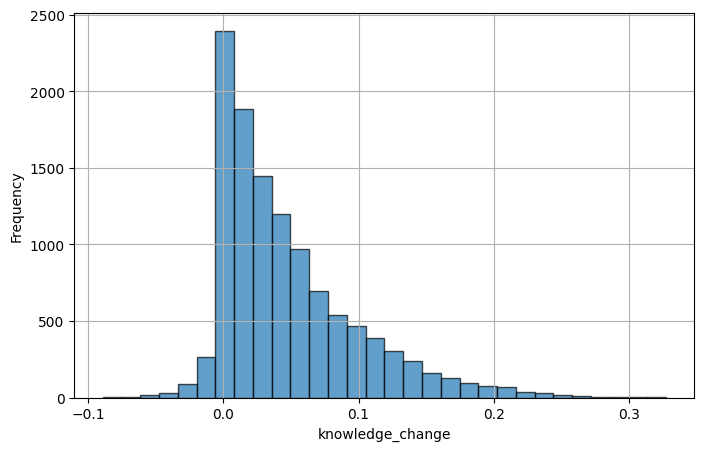

In [216]:
plt.figure(figsize=(8,5))
plt.hist(df_inuse[name], bins=30, edgecolor="black", alpha=0.7)
plt.xlabel(name)
plt.ylabel("Frequency")
plt.grid()
plt.show()

In [218]:
name = 'awareness_change'

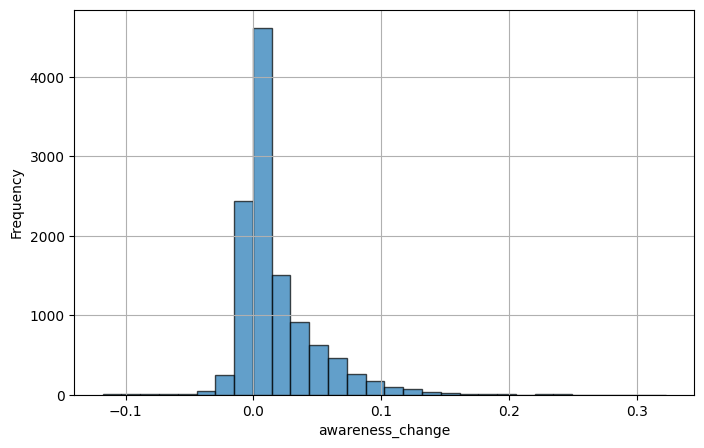

In [219]:
plt.figure(figsize=(8,5))
plt.hist(df_inuse[name], bins=30, edgecolor="black", alpha=0.7)
plt.xlabel(name)
plt.ylabel("Frequency")
plt.grid()
plt.show()

In [220]:
name = 'SoilWaterConservation_change'

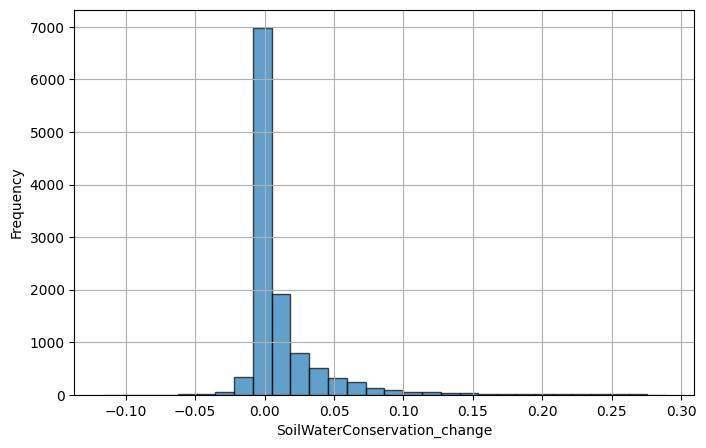

In [221]:
plt.figure(figsize=(8,5))
plt.hist(df_inuse[name], bins=30, edgecolor="black", alpha=0.7)
plt.xlabel(name)
plt.ylabel("Frequency")
plt.grid()
plt.show()

In [222]:
name = 'RiskReduction_change'

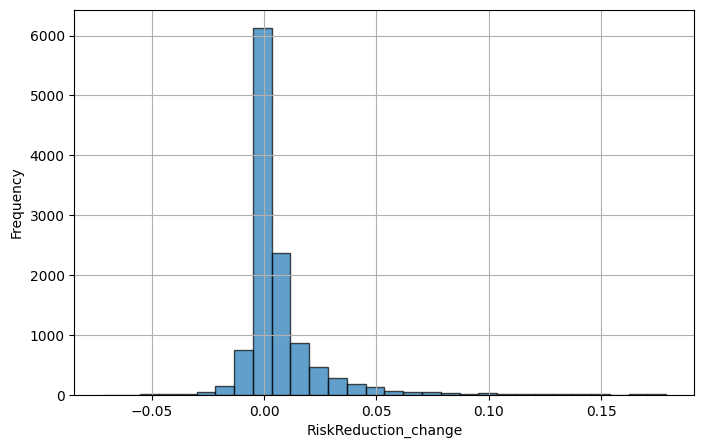

In [223]:
plt.figure(figsize=(8,5))
plt.hist(df_inuse[name], bins=30, edgecolor="black", alpha=0.7)
plt.xlabel(name)
plt.ylabel("Frequency")
plt.grid()
plt.show()

In [224]:
name = 'RoadImprovement_change'

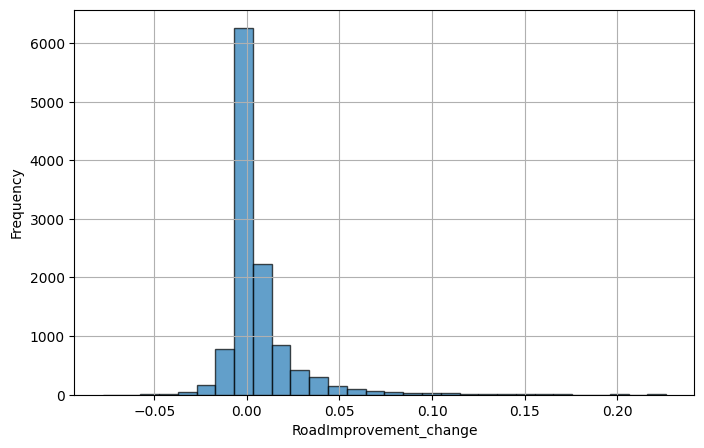

In [225]:
plt.figure(figsize=(8,5))
plt.hist(df_inuse[name], bins=30, edgecolor="black", alpha=0.7)
plt.xlabel(name)
plt.ylabel("Frequency")
plt.grid()
plt.show()

In [226]:
name = 'CommunityPartipation_change'

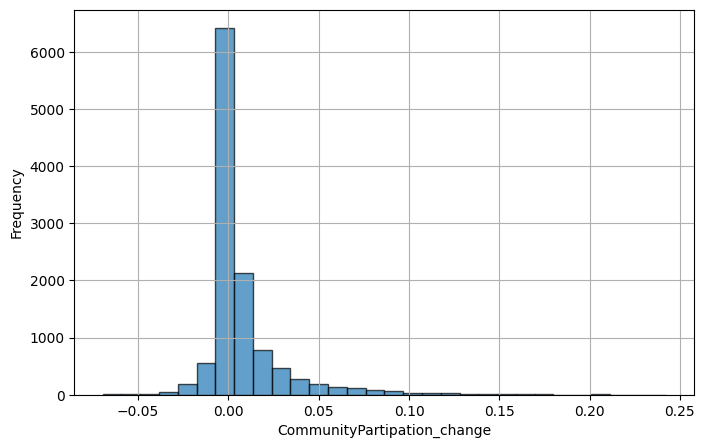

In [227]:
plt.figure(figsize=(8,5))
plt.hist(df_inuse[name], bins=30, edgecolor="black", alpha=0.7)
plt.xlabel(name)
plt.ylabel("Frequency")
plt.grid()
plt.show()

### Grouping  Gender

In [228]:
name = 'knowledge_change'

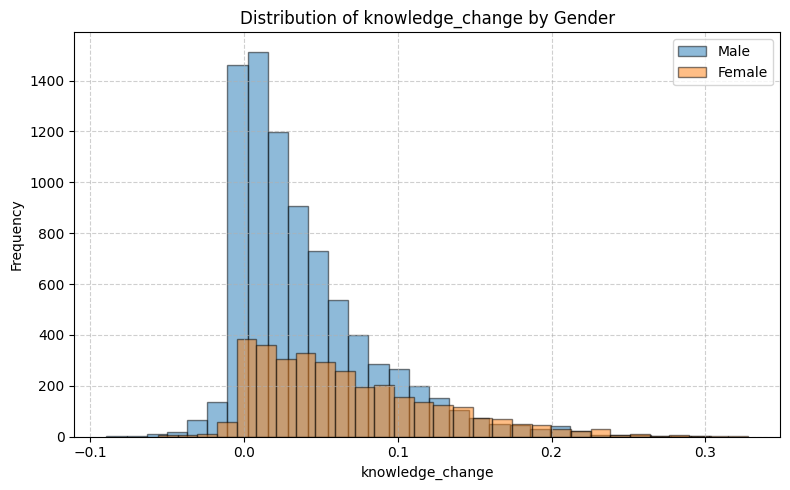

In [229]:
plt.figure(figsize=(8,5))

# Separate groups
male_data = df_inuse[df_inuse['Female Dummy'] == 0][name]
female_data = df_inuse[df_inuse['Female Dummy'] == 1][name]

plt.hist(male_data, bins=30, edgecolor="black", alpha=0.5, label="Male")
plt.hist(female_data, bins=30, edgecolor="black", alpha=0.5, label="Female")

plt.xlabel(name)
plt.ylabel("Frequency")
plt.title(f"Distribution of {name} by Gender")
plt.legend()
plt.grid(True, linestyle="--", alpha=0.6)
plt.tight_layout()
plt.show()

In [230]:
name = 'awareness_change'

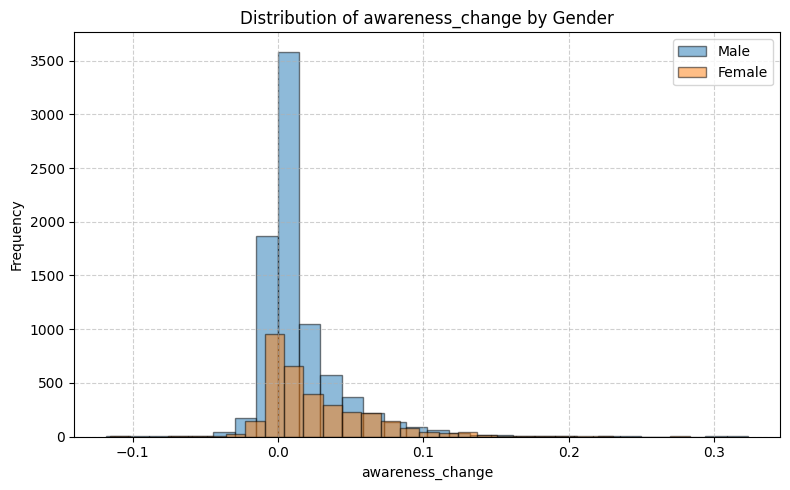

In [231]:
plt.figure(figsize=(8,5))

# Separate groups
male_data = df_inuse[df_inuse['Female Dummy'] == 0][name]
female_data = df_inuse[df_inuse['Female Dummy'] == 1][name]

plt.hist(male_data, bins=30, edgecolor="black", alpha=0.5, label="Male")
plt.hist(female_data, bins=30, edgecolor="black", alpha=0.5, label="Female")

plt.xlabel(name)
plt.ylabel("Frequency")
plt.title(f"Distribution of {name} by Gender")
plt.legend()
plt.grid(True, linestyle="--", alpha=0.6)
plt.tight_layout()
plt.show()

In [232]:
name = 'SoilWaterConservation_change'

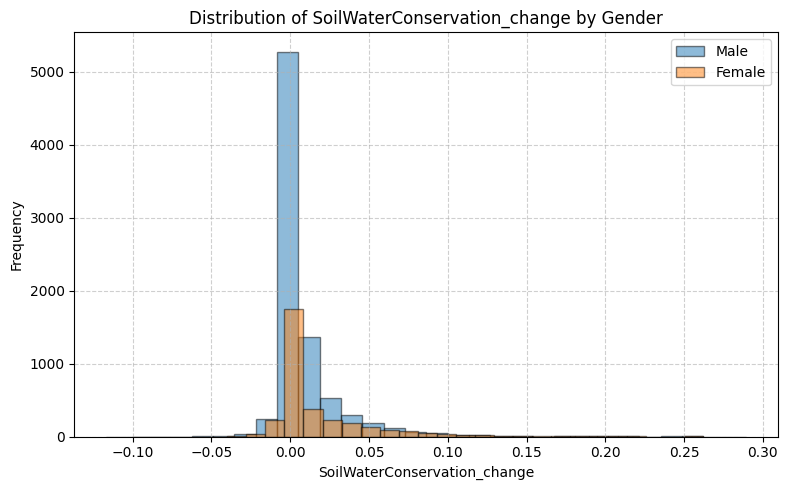

In [233]:
plt.figure(figsize=(8,5))

# Separate groups
male_data = df_inuse[df_inuse['Female Dummy'] == 0][name]
female_data = df_inuse[df_inuse['Female Dummy'] == 1][name]

plt.hist(male_data, bins=30, edgecolor="black", alpha=0.5, label="Male")
plt.hist(female_data, bins=30, edgecolor="black", alpha=0.5, label="Female")

plt.xlabel(name)
plt.ylabel("Frequency")
plt.title(f"Distribution of {name} by Gender")
plt.legend()
plt.grid(True, linestyle="--", alpha=0.6)
plt.tight_layout()
plt.show()

In [234]:
name = 'RiskReduction_change'

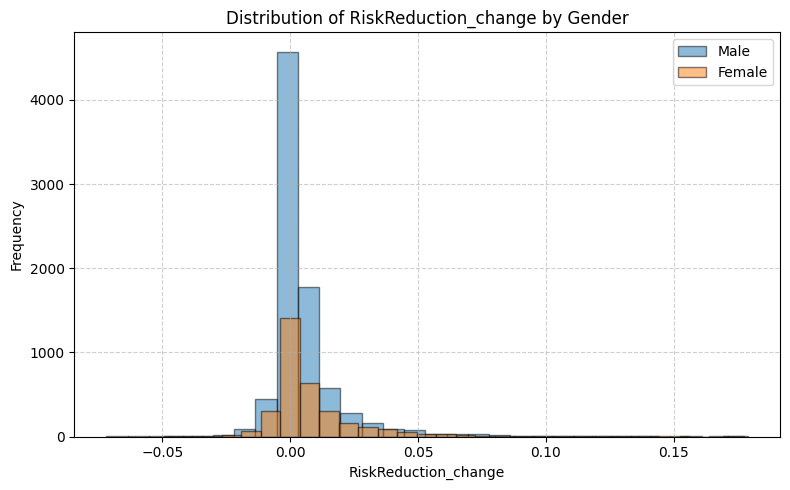

In [235]:
plt.figure(figsize=(8,5))

# Separate groups
male_data = df_inuse[df_inuse['Female Dummy'] == 0][name]
female_data = df_inuse[df_inuse['Female Dummy'] == 1][name]

plt.hist(male_data, bins=30, edgecolor="black", alpha=0.5, label="Male")
plt.hist(female_data, bins=30, edgecolor="black", alpha=0.5, label="Female")

plt.xlabel(name)
plt.ylabel("Frequency")
plt.title(f"Distribution of {name} by Gender")
plt.legend()
plt.grid(True, linestyle="--", alpha=0.6)
plt.tight_layout()
plt.show()

In [236]:
name = 'RoadImprovement_change'

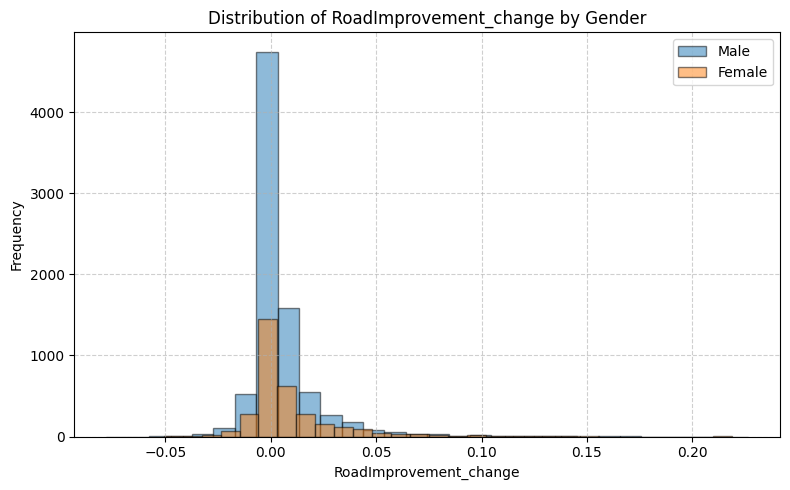

In [237]:
plt.figure(figsize=(8,5))

# Separate groups
male_data = df_inuse[df_inuse['Female Dummy'] == 0][name]
female_data = df_inuse[df_inuse['Female Dummy'] == 1][name]

plt.hist(male_data, bins=30, edgecolor="black", alpha=0.5, label="Male")
plt.hist(female_data, bins=30, edgecolor="black", alpha=0.5, label="Female")

plt.xlabel(name)
plt.ylabel("Frequency")
plt.title(f"Distribution of {name} by Gender")
plt.legend()
plt.grid(True, linestyle="--", alpha=0.6)
plt.tight_layout()
plt.show()

In [238]:
name = 'CommunityPartipation_change'

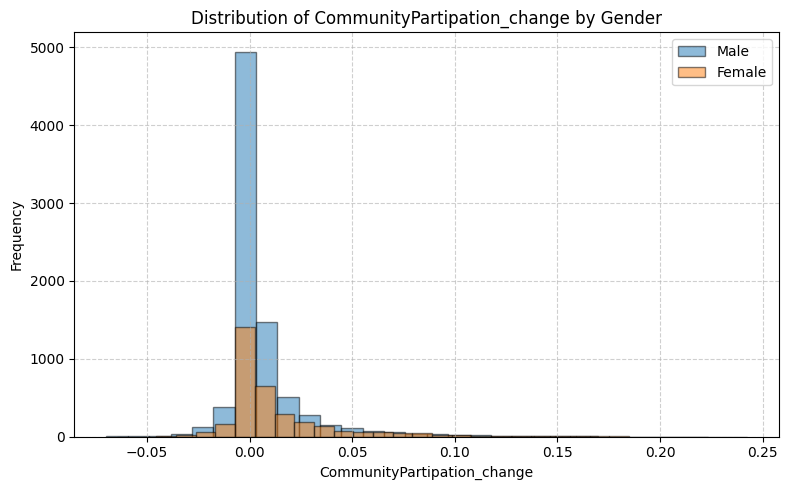

In [239]:
plt.figure(figsize=(8,5))

# Separate groups
male_data = df_inuse[df_inuse['Female Dummy'] == 0][name]
female_data = df_inuse[df_inuse['Female Dummy'] == 1][name]

plt.hist(male_data, bins=30, edgecolor="black", alpha=0.5, label="Male")
plt.hist(female_data, bins=30, edgecolor="black", alpha=0.5, label="Female")

plt.xlabel(name)
plt.ylabel("Frequency")
plt.title(f"Distribution of {name} by Gender")
plt.legend()
plt.grid(True, linestyle="--", alpha=0.6)
plt.tight_layout()
plt.show()

### Grouping  Age

In [241]:
df_inuse['Age'].describe()

count    11568.000000
mean        58.681189
std         10.276510
min         45.000000
25%         50.000000
50%         58.000000
75%         66.000000
max         95.000000
Name: Age, dtype: float64

In [242]:
bins = [45, 55, 65, float('inf')]
labels = ['45–55', '55–65', '65+']

df_inuse['AgeGroup'] = pd.cut(df_inuse['Age'], bins=bins, labels=labels, right=False)

/var/folders/f6/xmkhn5bd6vgbnt1m2ym7y8sm0000gn/T/ipykernel_24520/2052090008.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_inuse['AgeGroup'] = pd.cut(df_inuse['Age'], bins=bins, labels=labels, right=False)


In [243]:
print(df_inuse['AgeGroup'].value_counts())

AgeGroup
45–55    4553
55–65    3607
65+      3408
Name: count, dtype: int64


In [257]:
name = 'knowledge_change'

/var/folders/f6/xmkhn5bd6vgbnt1m2ym7y8sm0000gn/T/ipykernel_24520/3274527905.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  for group, data in df_inuse.groupby('AgeGroup'):


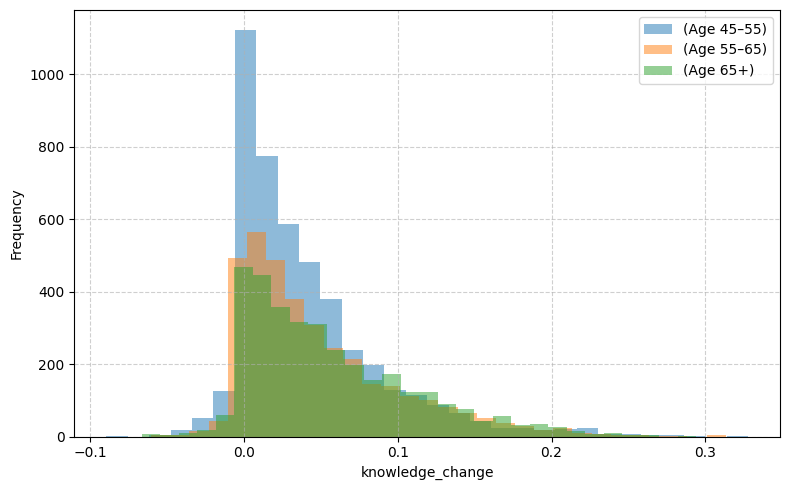

In [260]:
plt.figure(figsize=(8,5))

for group, data in df_inuse.groupby('AgeGroup'):
    plt.hist(
        data[name],
        bins=30,
        alpha=0.5,
        label=f"(Age {group})"
    )

plt.xlabel(name)
plt.ylabel("Frequency")
plt.legend()
plt.grid(True, linestyle="--", alpha=0.6)
plt.tight_layout()
plt.show()

In [262]:
name = 'awareness_change'

/var/folders/f6/xmkhn5bd6vgbnt1m2ym7y8sm0000gn/T/ipykernel_24520/3274527905.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  for group, data in df_inuse.groupby('AgeGroup'):


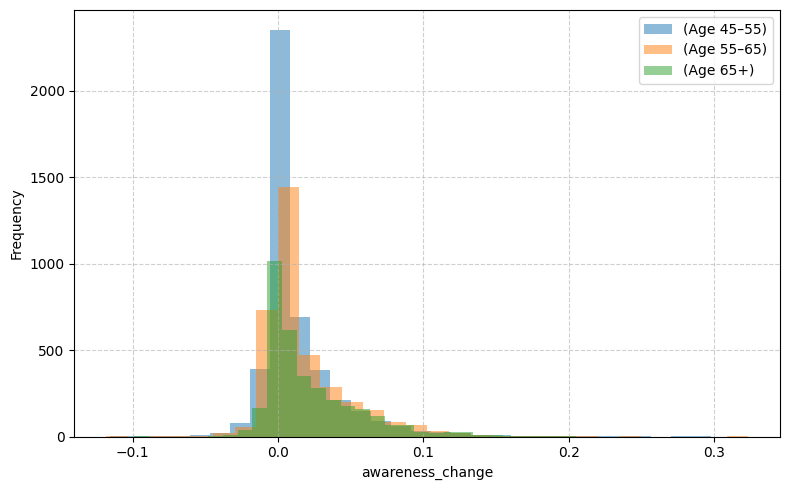

In [263]:
plt.figure(figsize=(8,5))

for group, data in df_inuse.groupby('AgeGroup'):
    plt.hist(
        data[name],
        bins=30,
        alpha=0.5,
        label=f"(Age {group})"
    )

plt.xlabel(name)
plt.ylabel("Frequency")
plt.legend()
plt.grid(True, linestyle="--", alpha=0.6)
plt.tight_layout()
plt.show()

In [264]:
name = 'SoilWaterConservation_change'

/var/folders/f6/xmkhn5bd6vgbnt1m2ym7y8sm0000gn/T/ipykernel_24520/3274527905.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  for group, data in df_inuse.groupby('AgeGroup'):


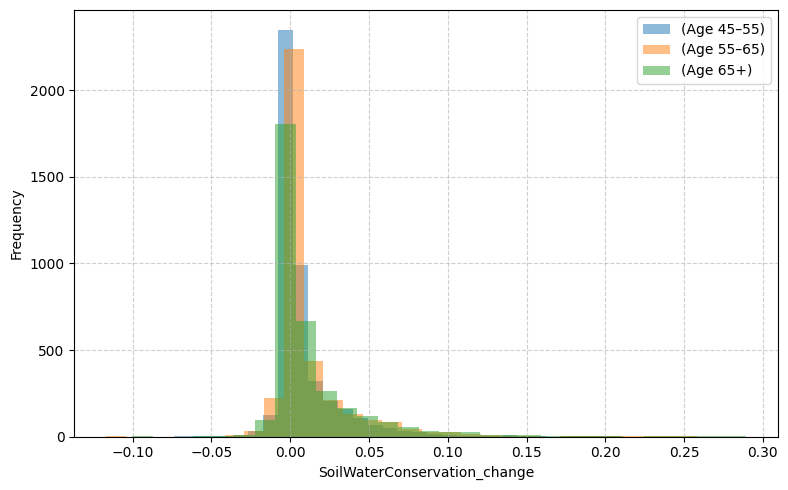

In [265]:
plt.figure(figsize=(8,5))

for group, data in df_inuse.groupby('AgeGroup'):
    plt.hist(
        data[name],
        bins=30,
        alpha=0.5,
        label=f"(Age {group})"
    )

plt.xlabel(name)
plt.ylabel("Frequency")
plt.legend()
plt.grid(True, linestyle="--", alpha=0.6)
plt.tight_layout()
plt.show()

In [266]:
name = 'RiskReduction_change'

/var/folders/f6/xmkhn5bd6vgbnt1m2ym7y8sm0000gn/T/ipykernel_24520/3274527905.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  for group, data in df_inuse.groupby('AgeGroup'):


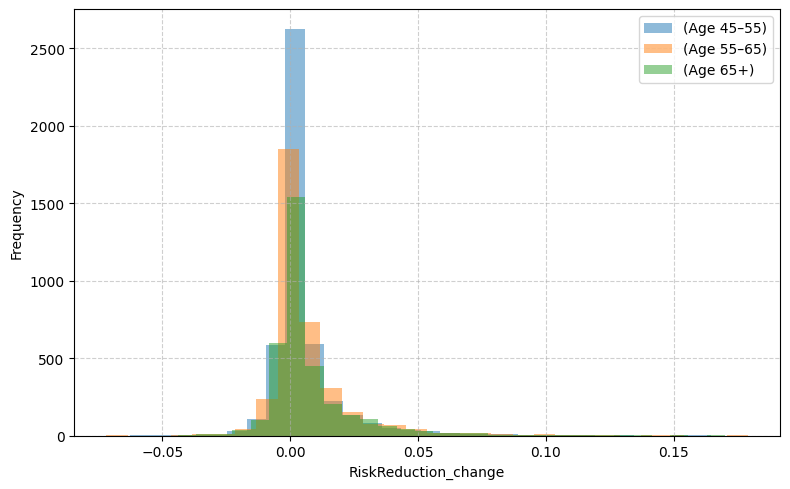

In [267]:
plt.figure(figsize=(8,5))

for group, data in df_inuse.groupby('AgeGroup'):
    plt.hist(
        data[name],
        bins=30,
        alpha=0.5,
        label=f"(Age {group})"
    )

plt.xlabel(name)
plt.ylabel("Frequency")
plt.legend()
plt.grid(True, linestyle="--", alpha=0.6)
plt.tight_layout()
plt.show()

In [268]:
name = 'RoadImprovement_change'

/var/folders/f6/xmkhn5bd6vgbnt1m2ym7y8sm0000gn/T/ipykernel_24520/3274527905.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  for group, data in df_inuse.groupby('AgeGroup'):


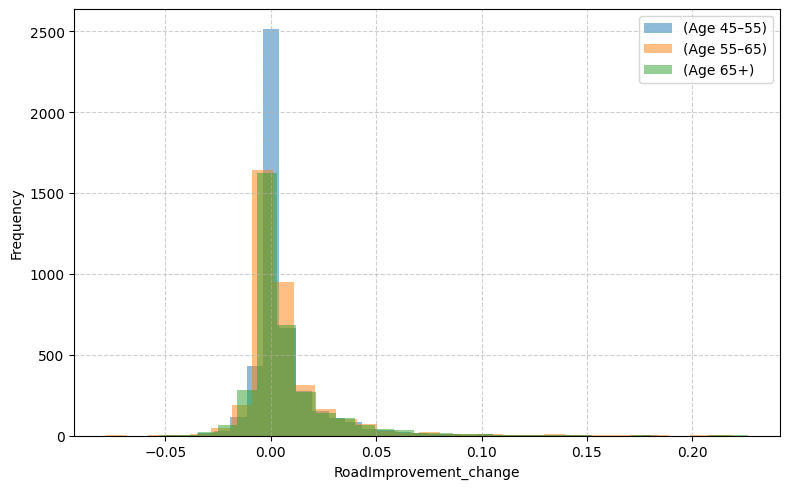

In [269]:
plt.figure(figsize=(8,5))

for group, data in df_inuse.groupby('AgeGroup'):
    plt.hist(
        data[name],
        bins=30,
        alpha=0.5,
        label=f"(Age {group})"
    )

plt.xlabel(name)
plt.ylabel("Frequency")
plt.legend()
plt.grid(True, linestyle="--", alpha=0.6)
plt.tight_layout()
plt.show()

In [270]:
name = 'CommunityPartipation_change'

/var/folders/f6/xmkhn5bd6vgbnt1m2ym7y8sm0000gn/T/ipykernel_24520/3274527905.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  for group, data in df_inuse.groupby('AgeGroup'):


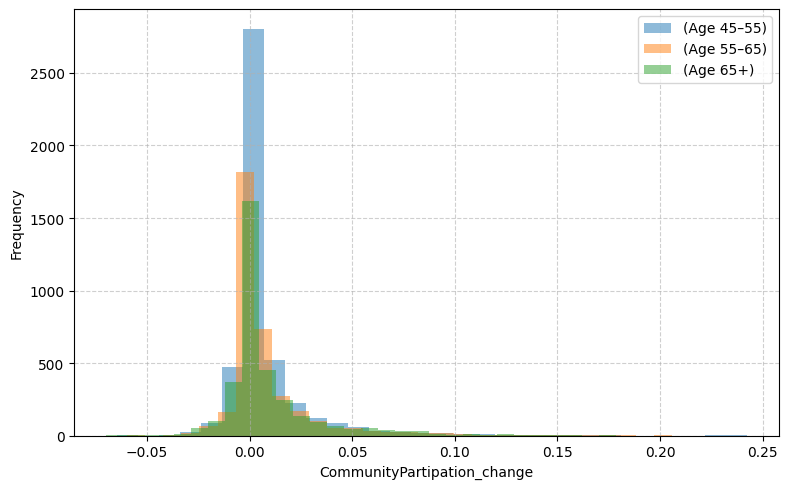

In [271]:
plt.figure(figsize=(8,5))

for group, data in df_inuse.groupby('AgeGroup'):
    plt.hist(
        data[name],
        bins=30,
        alpha=0.5,
        label=f"(Age {group})"
    )

plt.xlabel(name)
plt.ylabel("Frequency")
plt.legend()
plt.grid(True, linestyle="--", alpha=0.6)
plt.tight_layout()
plt.show()

### Grouping  Income

In [304]:
df_inuse['Total Income'].describe()

count    1.156800e+04
mean     3.239423e+05
std      1.143592e+06
min      0.000000e+00
25%      5.400000e+04
50%      1.700000e+05
75%      4.000000e+05
max      9.920000e+07
Name: Total Income, dtype: float64

In [305]:
bins = [-float('inf'), 5.400000e+04, 1.700000e+05, 4.000000e+05, float('inf')]
labels = ['Q1', 'Q2', 'Q3', 'Q4']

df_inuse['IncomeGroup'] = pd.cut(df_inuse['Total Income'], bins=bins, labels=labels, right=False)

/var/folders/f6/xmkhn5bd6vgbnt1m2ym7y8sm0000gn/T/ipykernel_24520/945432714.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_inuse['IncomeGroup'] = pd.cut(df_inuse['Total Income'], bins=bins, labels=labels, right=False)


In [306]:
print(df_inuse['IncomeGroup'].value_counts())

IncomeGroup
Q3    2917
Q4    2896
Q1    2888
Q2    2867
Name: count, dtype: int64


In [307]:
name = 'knowledge_change'

/var/folders/f6/xmkhn5bd6vgbnt1m2ym7y8sm0000gn/T/ipykernel_24520/3379263597.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  for group, data in df_inuse.groupby('IncomeGroup'):


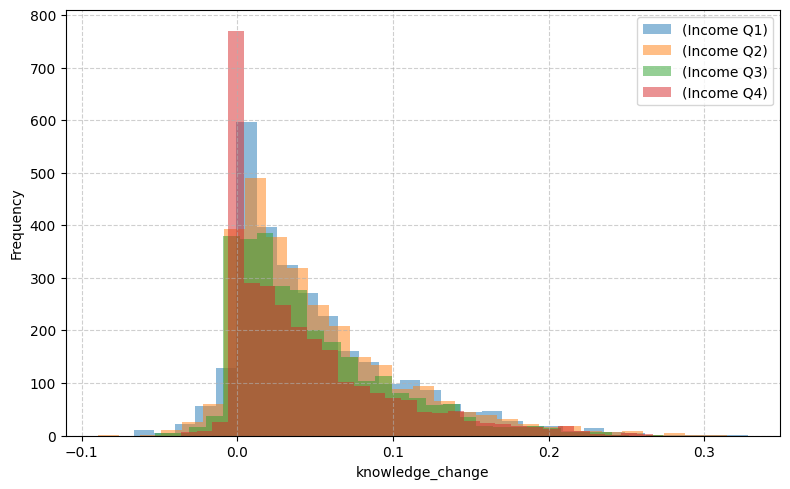

In [308]:
plt.figure(figsize=(8,5))

for group, data in df_inuse.groupby('IncomeGroup'):
    plt.hist(
        data[name],
        bins=30,
        alpha=0.5,
        label=f"(Income {group})"
    )

plt.xlabel(name)
plt.ylabel("Frequency")
plt.legend()
plt.grid(True, linestyle="--", alpha=0.6)
plt.tight_layout()
plt.show()

In [309]:
name = 'awareness_change'

/var/folders/f6/xmkhn5bd6vgbnt1m2ym7y8sm0000gn/T/ipykernel_24520/3379263597.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  for group, data in df_inuse.groupby('IncomeGroup'):


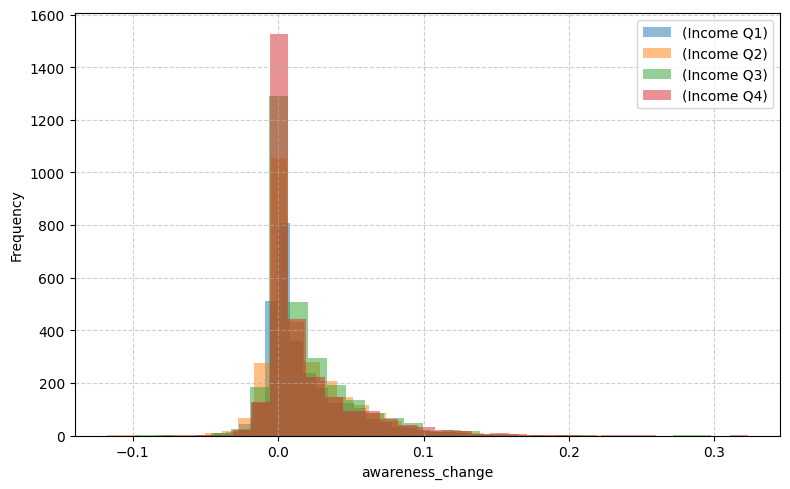

In [310]:
plt.figure(figsize=(8,5))

for group, data in df_inuse.groupby('IncomeGroup'):
    plt.hist(
        data[name],
        bins=30,
        alpha=0.5,
        label=f"(Income {group})"
    )

plt.xlabel(name)
plt.ylabel("Frequency")
plt.legend()
plt.grid(True, linestyle="--", alpha=0.6)
plt.tight_layout()
plt.show()

In [311]:
name = 'SoilWaterConservation_change'

/var/folders/f6/xmkhn5bd6vgbnt1m2ym7y8sm0000gn/T/ipykernel_24520/3379263597.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  for group, data in df_inuse.groupby('IncomeGroup'):


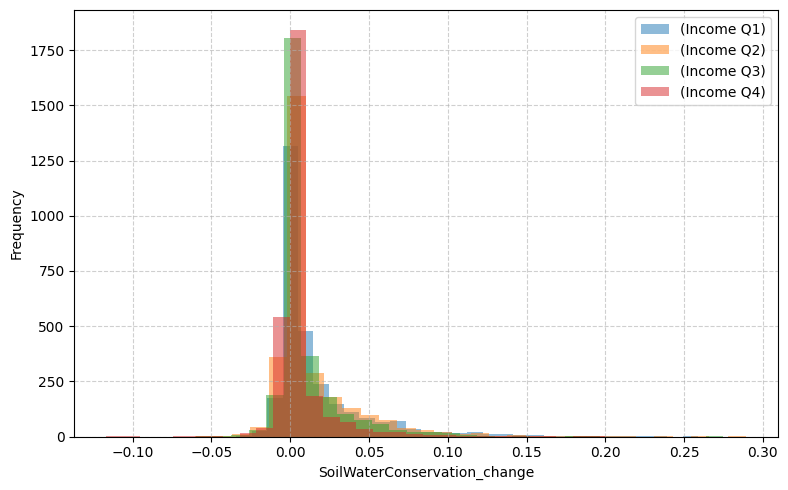

In [312]:
plt.figure(figsize=(8,5))

for group, data in df_inuse.groupby('IncomeGroup'):
    plt.hist(
        data[name],
        bins=30,
        alpha=0.5,
        label=f"(Income {group})"
    )

plt.xlabel(name)
plt.ylabel("Frequency")
plt.legend()
plt.grid(True, linestyle="--", alpha=0.6)
plt.tight_layout()
plt.show()

In [313]:
name = 'RiskReduction_change'

/var/folders/f6/xmkhn5bd6vgbnt1m2ym7y8sm0000gn/T/ipykernel_24520/3379263597.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  for group, data in df_inuse.groupby('IncomeGroup'):


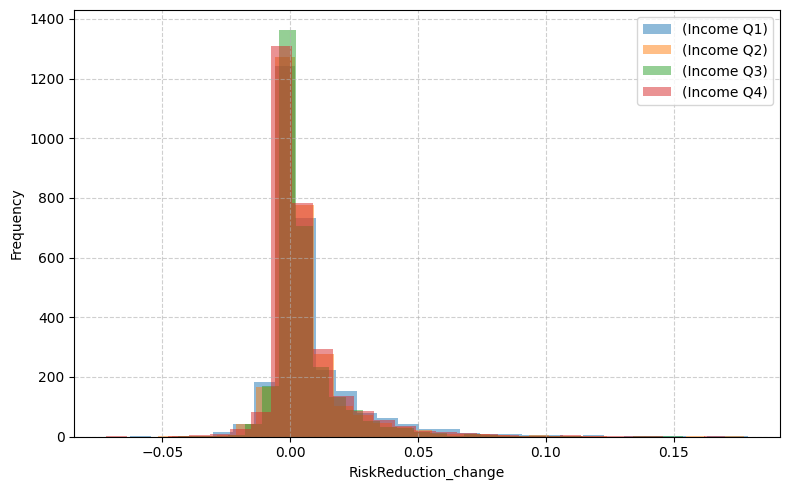

In [314]:
plt.figure(figsize=(8,5))

for group, data in df_inuse.groupby('IncomeGroup'):
    plt.hist(
        data[name],
        bins=30,
        alpha=0.5,
        label=f"(Income {group})"
    )

plt.xlabel(name)
plt.ylabel("Frequency")
plt.legend()
plt.grid(True, linestyle="--", alpha=0.6)
plt.tight_layout()
plt.show()

In [315]:
name = 'RoadImprovement_change'

/var/folders/f6/xmkhn5bd6vgbnt1m2ym7y8sm0000gn/T/ipykernel_24520/3379263597.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  for group, data in df_inuse.groupby('IncomeGroup'):


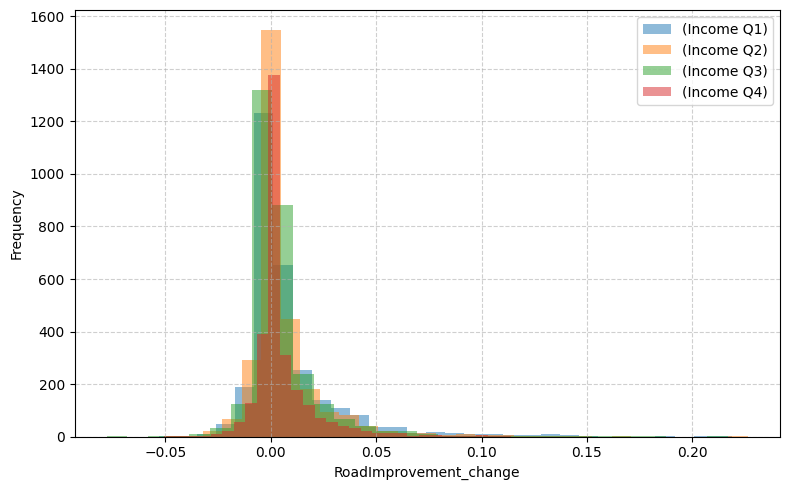

In [316]:
plt.figure(figsize=(8,5))

for group, data in df_inuse.groupby('IncomeGroup'):
    plt.hist(
        data[name],
        bins=30,
        alpha=0.5,
        label=f"(Income {group})"
    )

plt.xlabel(name)
plt.ylabel("Frequency")
plt.legend()
plt.grid(True, linestyle="--", alpha=0.6)
plt.tight_layout()
plt.show()

In [317]:
name = 'CommunityPartipation_change'

/var/folders/f6/xmkhn5bd6vgbnt1m2ym7y8sm0000gn/T/ipykernel_24520/3379263597.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  for group, data in df_inuse.groupby('IncomeGroup'):


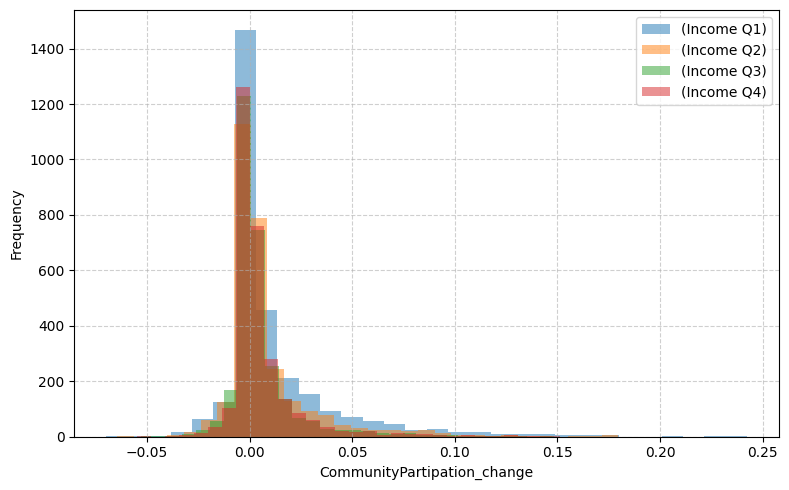

In [318]:
plt.figure(figsize=(8,5))

for group, data in df_inuse.groupby('IncomeGroup'):
    plt.hist(
        data[name],
        bins=30,
        alpha=0.5,
        label=f"(Income {group})"
    )

plt.xlabel(name)
plt.ylabel("Frequency")
plt.legend()
plt.grid(True, linestyle="--", alpha=0.6)
plt.tight_layout()
plt.show()

### Grouping Having Agricultural Land Dummy

In [277]:
name = 'knowledge_change'

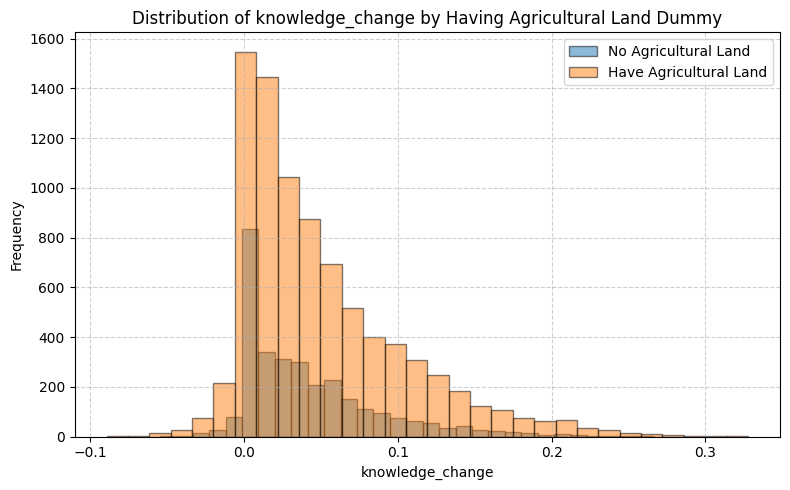

In [278]:
plt.figure(figsize=(8,5))

# Separate groups
no_data = df_inuse[df_inuse['Having Agricultural Land Dummy'] == 0][name]
yes_data = df_inuse[df_inuse['Having Agricultural Land Dummy'] == 1][name]

plt.hist(no_data, bins=30, edgecolor="black", alpha=0.5, label="No Agricultural Land")
plt.hist(yes_data, bins=30, edgecolor="black", alpha=0.5, label="Have Agricultural Land")

plt.xlabel(name)
plt.ylabel("Frequency")
plt.title(f"Distribution of {name} by Having Agricultural Land Dummy")
plt.legend()
plt.grid(True, linestyle="--", alpha=0.6)
plt.tight_layout()
plt.show()

In [279]:
name = 'awareness_change'

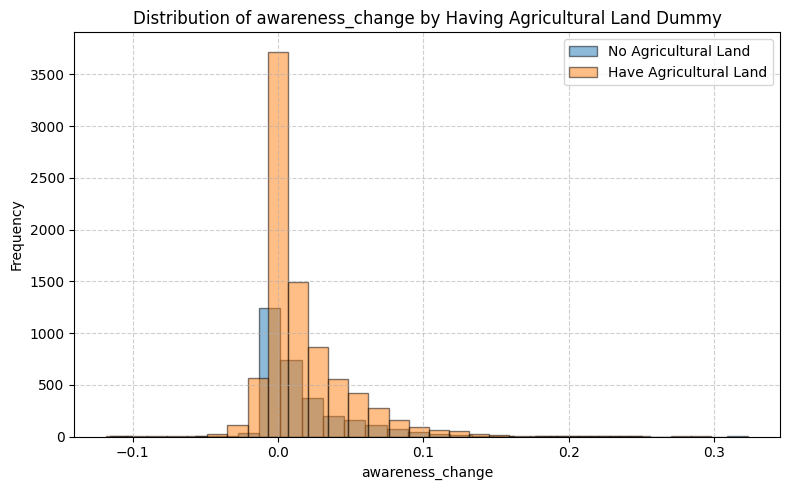

In [280]:
plt.figure(figsize=(8,5))

# Separate groups
no_data = df_inuse[df_inuse['Having Agricultural Land Dummy'] == 0][name]
yes_data = df_inuse[df_inuse['Having Agricultural Land Dummy'] == 1][name]

plt.hist(no_data, bins=30, edgecolor="black", alpha=0.5, label="No Agricultural Land")
plt.hist(yes_data, bins=30, edgecolor="black", alpha=0.5, label="Have Agricultural Land")

plt.xlabel(name)
plt.ylabel("Frequency")
plt.title(f"Distribution of {name} by Having Agricultural Land Dummy")
plt.legend()
plt.grid(True, linestyle="--", alpha=0.6)
plt.tight_layout()
plt.show()

In [281]:
name = 'SoilWaterConservation_change'

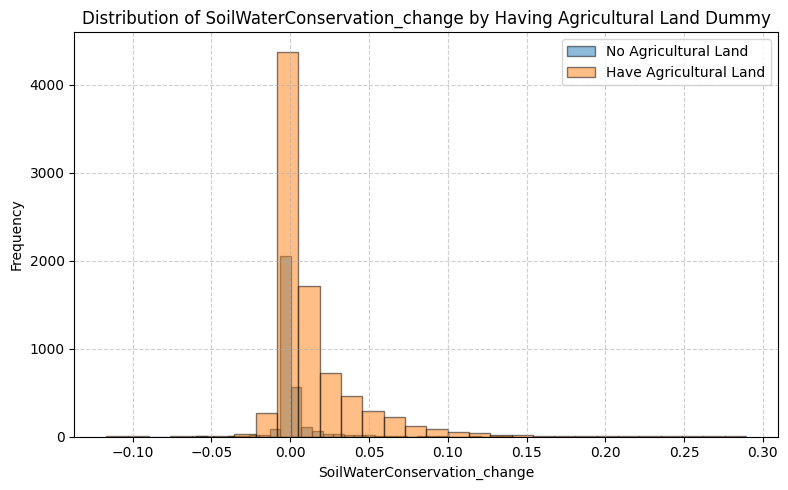

In [282]:
plt.figure(figsize=(8,5))

# Separate groups
no_data = df_inuse[df_inuse['Having Agricultural Land Dummy'] == 0][name]
yes_data = df_inuse[df_inuse['Having Agricultural Land Dummy'] == 1][name]

plt.hist(no_data, bins=30, edgecolor="black", alpha=0.5, label="No Agricultural Land")
plt.hist(yes_data, bins=30, edgecolor="black", alpha=0.5, label="Have Agricultural Land")

plt.xlabel(name)
plt.ylabel("Frequency")
plt.title(f"Distribution of {name} by Having Agricultural Land Dummy")
plt.legend()
plt.grid(True, linestyle="--", alpha=0.6)
plt.tight_layout()
plt.show()

In [283]:
name = 'RiskReduction_change'

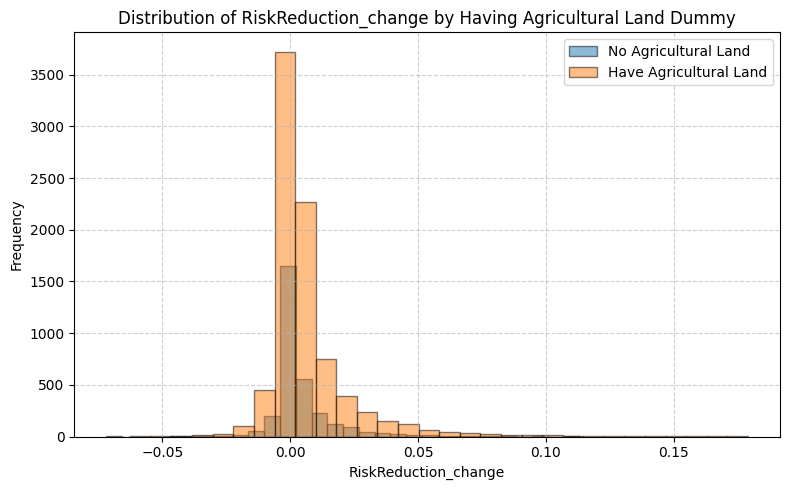

In [284]:
plt.figure(figsize=(8,5))

# Separate groups
no_data = df_inuse[df_inuse['Having Agricultural Land Dummy'] == 0][name]
yes_data = df_inuse[df_inuse['Having Agricultural Land Dummy'] == 1][name]

plt.hist(no_data, bins=30, edgecolor="black", alpha=0.5, label="No Agricultural Land")
plt.hist(yes_data, bins=30, edgecolor="black", alpha=0.5, label="Have Agricultural Land")

plt.xlabel(name)
plt.ylabel("Frequency")
plt.title(f"Distribution of {name} by Having Agricultural Land Dummy")
plt.legend()
plt.grid(True, linestyle="--", alpha=0.6)
plt.tight_layout()
plt.show()

In [285]:
name = 'RoadImprovement_change'

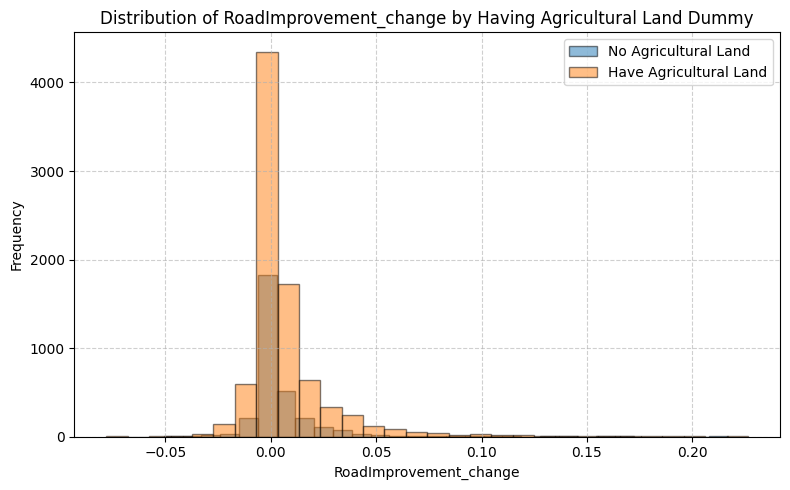

In [286]:
plt.figure(figsize=(8,5))

# Separate groups
no_data = df_inuse[df_inuse['Having Agricultural Land Dummy'] == 0][name]
yes_data = df_inuse[df_inuse['Having Agricultural Land Dummy'] == 1][name]

plt.hist(no_data, bins=30, edgecolor="black", alpha=0.5, label="No Agricultural Land")
plt.hist(yes_data, bins=30, edgecolor="black", alpha=0.5, label="Have Agricultural Land")

plt.xlabel(name)
plt.ylabel("Frequency")
plt.title(f"Distribution of {name} by Having Agricultural Land Dummy")
plt.legend()
plt.grid(True, linestyle="--", alpha=0.6)
plt.tight_layout()
plt.show()

In [287]:
name = 'CommunityPartipation_change'

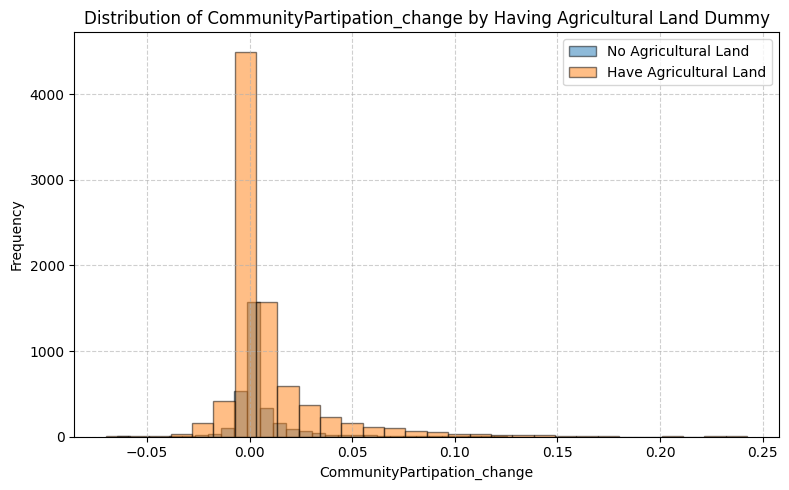

In [288]:
plt.figure(figsize=(8,5))

# Separate groups
no_data = df_inuse[df_inuse['Having Agricultural Land Dummy'] == 0][name]
yes_data = df_inuse[df_inuse['Having Agricultural Land Dummy'] == 1][name]

plt.hist(no_data, bins=30, edgecolor="black", alpha=0.5, label="No Agricultural Land")
plt.hist(yes_data, bins=30, edgecolor="black", alpha=0.5, label="Have Agricultural Land")

plt.xlabel(name)
plt.ylabel("Frequency")
plt.title(f"Distribution of {name} by Having Agricultural Land Dummy")
plt.legend()
plt.grid(True, linestyle="--", alpha=0.6)
plt.tight_layout()
plt.show()

### Grouping Having Internet Dummy

In [291]:
name = 'knowledge_change'

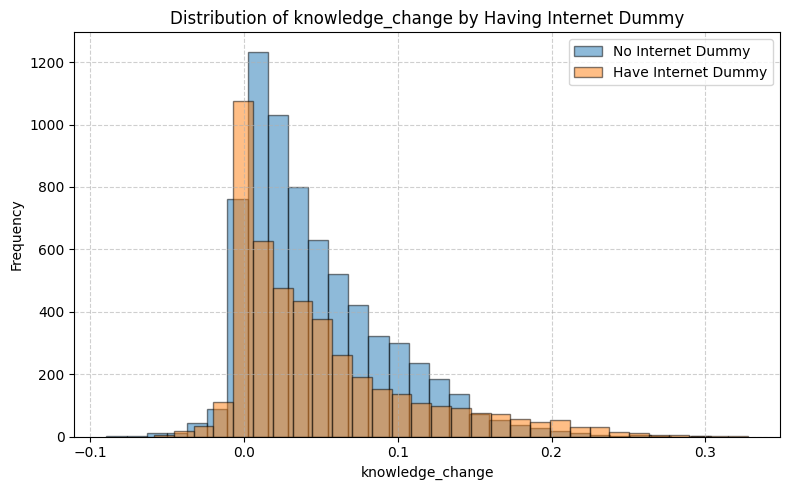

In [292]:
plt.figure(figsize=(8,5))

# Separate groups
no_data = df_inuse[df_inuse['Having Internet Dummy'] == 0][name]
yes_data = df_inuse[df_inuse['Having Internet Dummy'] == 1][name]

plt.hist(no_data, bins=30, edgecolor="black", alpha=0.5, label="No Internet Dummy")
plt.hist(yes_data, bins=30, edgecolor="black", alpha=0.5, label="Have Internet Dummy")

plt.xlabel(name)
plt.ylabel("Frequency")
plt.title(f"Distribution of {name} by Having Internet Dummy")
plt.legend()
plt.grid(True, linestyle="--", alpha=0.6)
plt.tight_layout()
plt.show()

In [293]:
name = 'awareness_change'

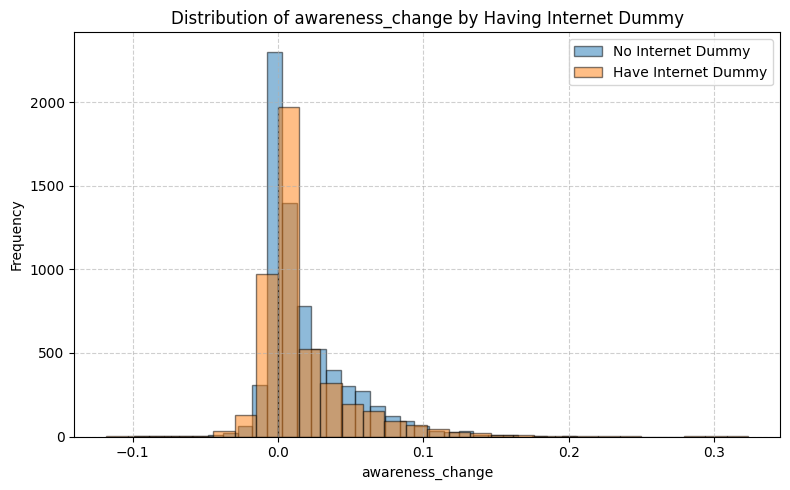

In [294]:
plt.figure(figsize=(8,5))

# Separate groups
no_data = df_inuse[df_inuse['Having Internet Dummy'] == 0][name]
yes_data = df_inuse[df_inuse['Having Internet Dummy'] == 1][name]

plt.hist(no_data, bins=30, edgecolor="black", alpha=0.5, label="No Internet Dummy")
plt.hist(yes_data, bins=30, edgecolor="black", alpha=0.5, label="Have Internet Dummy")

plt.xlabel(name)
plt.ylabel("Frequency")
plt.title(f"Distribution of {name} by Having Internet Dummy")
plt.legend()
plt.grid(True, linestyle="--", alpha=0.6)
plt.tight_layout()
plt.show()

In [295]:
name = 'SoilWaterConservation_change'

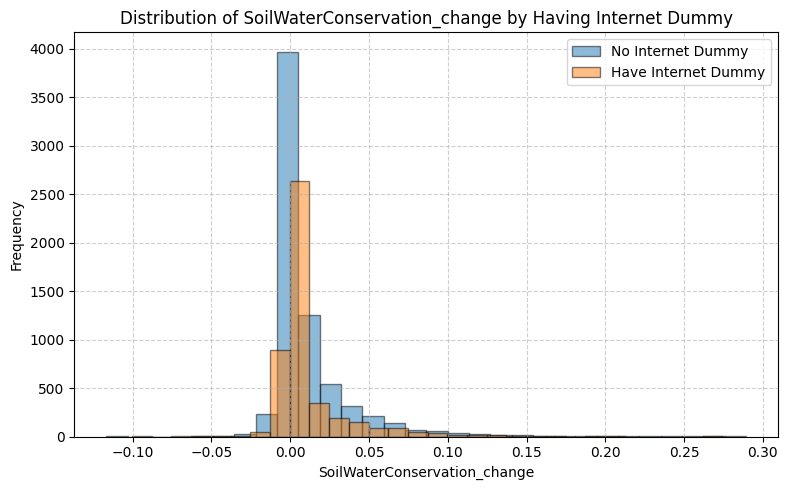

In [296]:
plt.figure(figsize=(8,5))

# Separate groups
no_data = df_inuse[df_inuse['Having Internet Dummy'] == 0][name]
yes_data = df_inuse[df_inuse['Having Internet Dummy'] == 1][name]

plt.hist(no_data, bins=30, edgecolor="black", alpha=0.5, label="No Internet Dummy")
plt.hist(yes_data, bins=30, edgecolor="black", alpha=0.5, label="Have Internet Dummy")

plt.xlabel(name)
plt.ylabel("Frequency")
plt.title(f"Distribution of {name} by Having Internet Dummy")
plt.legend()
plt.grid(True, linestyle="--", alpha=0.6)
plt.tight_layout()
plt.show()

In [297]:
name = 'RiskReduction_change'

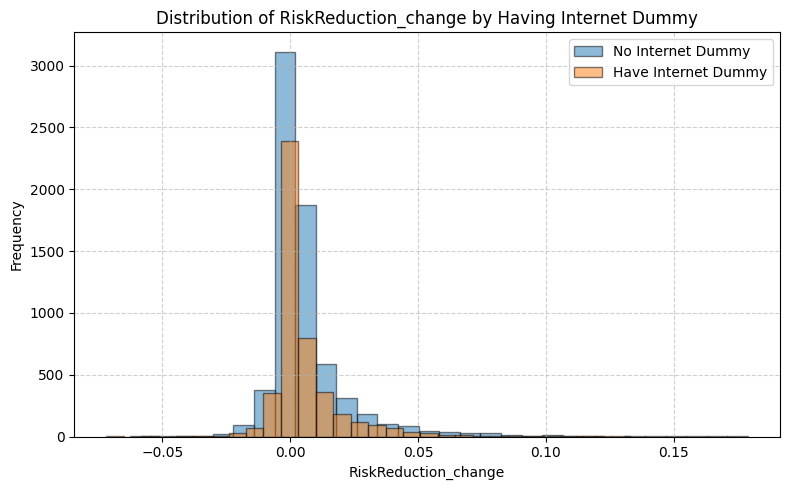

In [298]:
plt.figure(figsize=(8,5))

# Separate groups
no_data = df_inuse[df_inuse['Having Internet Dummy'] == 0][name]
yes_data = df_inuse[df_inuse['Having Internet Dummy'] == 1][name]

plt.hist(no_data, bins=30, edgecolor="black", alpha=0.5, label="No Internet Dummy")
plt.hist(yes_data, bins=30, edgecolor="black", alpha=0.5, label="Have Internet Dummy")

plt.xlabel(name)
plt.ylabel("Frequency")
plt.title(f"Distribution of {name} by Having Internet Dummy")
plt.legend()
plt.grid(True, linestyle="--", alpha=0.6)
plt.tight_layout()
plt.show()

In [299]:
name = 'RoadImprovement_change'

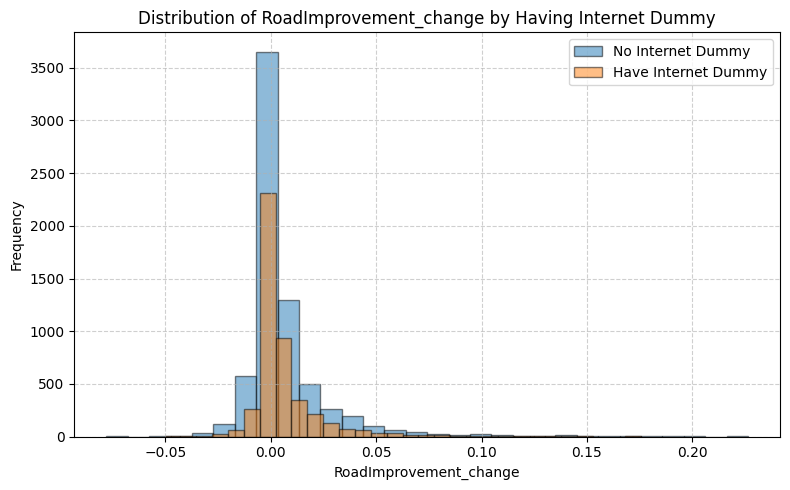

In [300]:
plt.figure(figsize=(8,5))

# Separate groups
no_data = df_inuse[df_inuse['Having Internet Dummy'] == 0][name]
yes_data = df_inuse[df_inuse['Having Internet Dummy'] == 1][name]

plt.hist(no_data, bins=30, edgecolor="black", alpha=0.5, label="No Internet Dummy")
plt.hist(yes_data, bins=30, edgecolor="black", alpha=0.5, label="Have Internet Dummy")

plt.xlabel(name)
plt.ylabel("Frequency")
plt.title(f"Distribution of {name} by Having Internet Dummy")
plt.legend()
plt.grid(True, linestyle="--", alpha=0.6)
plt.tight_layout()
plt.show()

In [301]:
name = 'CommunityPartipation_change'

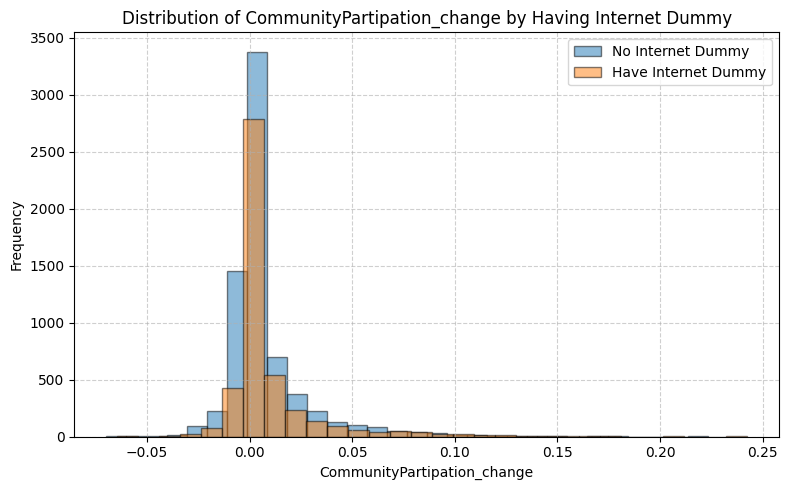

In [302]:
plt.figure(figsize=(8,5))

# Separate groups
no_data = df_inuse[df_inuse['Having Internet Dummy'] == 0][name]
yes_data = df_inuse[df_inuse['Having Internet Dummy'] == 1][name]

plt.hist(no_data, bins=30, edgecolor="black", alpha=0.5, label="No Internet Dummy")
plt.hist(yes_data, bins=30, edgecolor="black", alpha=0.5, label="Have Internet Dummy")

plt.xlabel(name)
plt.ylabel("Frequency")
plt.title(f"Distribution of {name} by Having Internet Dummy")
plt.legend()
plt.grid(True, linestyle="--", alpha=0.6)
plt.tight_layout()
plt.show()

## Save Data

In [319]:
!ls

Code           MLD01e_Code    MLD01e_Figures Manuscript     README.md
Data           MLD01e_Data    MLD01e_Results PrivateData    Results


In [320]:
df_inuse.to_parquet('MLD01e_Results/C61_df.parquet')